
# Real-data VLF perturbation inversion: ASLS, Whittaker, and PolyF3

This notebook is the **canonical results notebook** for the perturbation inversion performed with real VLF observations of the 25 March 2008 M1.7 solar flare along the NAA–PLO path.

It does not rerun the optimizations. It reads the validated HDF5 outputs, audits the two concatenated inversion runs for each background family, compares the final reconstructions on a common 5-minute grid, and generates the figures and tables used in the deliverable.

The three canonical chains are

\[
\mathrm{ASLS}: 15341092 \rightarrow 15373069,
\]

\[
\mathrm{Whittaker}: 15517278 \rightarrow 15572093,
\]

\[
\mathrm{PolyF3}: 15824988 \rightarrow 15868514.
\]

No reconstruction is treated as a known physical truth. “Best” refers only to a precisely stated data-misfit criterion.



## Methodological scope

The notebook separates three levels of evidence:

1. **Within-family endpoint evolution:** initial seed \(\rightarrow\) BBO-1 best \(\rightarrow\) BBO-2 best, evaluated on each inversion's 17-point target.
2. **Homogeneous inter-family comparison:** the three final reconstructions evaluated against the same 49-point, 5-minute target.
3. **Physical interpretation:** comparison of the inferred temporal and vertical perturbation parameters and representative electron-density fields.

The quantity denoted by \(\chi^2\) is

\[
\chi_A^2 =
\frac{\sum_i (A_i^{\mathrm{model}}-A_i^{\mathrm{obs}})^2}
{\sum_i (A_i^{\mathrm{obs}}-\overline{A}^{\mathrm{obs}})^2},
\]

with an analogous expression for phase and

\[
\chi_{\mathrm{total}}^2 = \chi_A^2 + \chi_\phi^2.
\]

It is a normalized sum of squared errors, not a reduced statistical chi-square.


In [2]:

# ============================================================
# 0. Packages, project root, and exclusive output directory
# ============================================================
using HDF5
using Dates
using Statistics
using DataFrames
using CSV
using Printf
using SHA
using Polynomials
using TimeZones
using AstroLib
using Interpolations
using LongwaveModePropagator
using LaTeXStrings
import CairoMakie as CM

CM.activate!()

PROJECT_ROOT = abspath(get(ENV, "VLF_PROJECT_ROOT", pwd()))

function default_h5_search_root(project_root::AbstractString)
    candidates = [
        joinpath(project_root, name)
        for name in readdir(project_root)
        if startswith(name, "h5_auditoria_inversiones_perturbacion_") &&
           isdir(joinpath(project_root, name))
    ]

    isempty(candidates) && return project_root

    # Prefer the most recently modified canonical collection produced
    # by recopilar_h5_inversiones_perturbacion.sh.
    sort!(candidates; by = path -> stat(path).mtime)
    selected = last(candidates)

    if length(candidates) > 1
        @warn(
            "Se encontraron varias carpetas de auditoría; se usará la más reciente.",
            selected = selected,
            candidates = candidates,
        )
    end

    return selected
end

INPUT_SEARCH_ROOT = abspath(get(
    ENV,
    "VLF_H5_SEARCH_ROOT",
    default_h5_search_root(PROJECT_ROOT),
))

# Keep one stable run identifier during the current Julia session.
RUN_ID = if isdefined(Main, :PERTURBATION_RESULTS_RUN_ID)
    getfield(Main, :PERTURBATION_RESULTS_RUN_ID)
else
    Dates.format(now(), "yyyymmdd_HHMMSS")
end
PERTURBATION_RESULTS_RUN_ID = RUN_ID

OUTPUT_ROOT = abspath(get(
    ENV,
    "VLF_PERTURBATION_RESULTS_OUTDIR",
    joinpath(
        PROJECT_ROOT,
        "resultados_inversion_perturbacion_datos_reales_3familias_" * RUN_ID,
    ),
))

FIGURES_DIR = joinpath(OUTPUT_ROOT, "figures")
TABLES_DIR = joinpath(OUTPUT_ROOT, "tables")
DIAGNOSTICS_DIR = joinpath(OUTPUT_ROOT, "diagnostics")
PROVENANCE_DIR = joinpath(OUTPUT_ROOT, "provenance")

for dir in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, DIAGNOSTICS_DIR, PROVENANCE_DIR)
    mkpath(dir)
end

RUN_PHYSICAL_FIELDS = true
RUN_ALL_FAMILY_HEATMAPS = true

METHODS = ["ASLS", "Whittaker", "PolyF3"]
METHOD_COLORS = Dict(
    "ASLS" => :dodgerblue3,
    "Whittaker" => :darkgreen,
    "PolyF3" => :red3,
)
METHOD_LINESTYLES = Dict(
    "ASLS" => :dashdot,
    "Whittaker" => :dot,
    "PolyF3" => :solid,
)

FS_TICK = 19
FS_LABEL = 22
FS_TITLE = 24
FS_LEGEND = 17
LW = 3.2

println("Project root:      ", PROJECT_ROOT)
println("HDF5 search root:  ", INPUT_SEARCH_ROOT)
println("Exclusive output:  ", OUTPUT_ROOT)


Project root:      /home/jp/basefolder_JP
HDF5 search root:  /home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901
Exclusive output:  /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256


## 1. Canonical input files

In [3]:

# ============================================================
# 1. Canonical file registry and deterministic recursive search
# ============================================================
FILE_SPECS = [
    (key = :ASLS_BBO1, family = "ASLS", role = "perturbation BBO-1",
     name = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5"),
    (key = :ASLS_BBO2, family = "ASLS", role = "perturbation BBO-2",
     name = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5"),
    (key = :ASLS_BG, family = "ASLS", role = "physical background",
     name = "new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5"),
    (key = :ASLS_DATA, family = "ASLS", role = "separation data",
     name = "datos_asls_full-v3.h5"),

    (key = :WHIT_BBO1, family = "Whittaker", role = "perturbation BBO-1",
     name = "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5"),
    (key = :WHIT_BBO2, family = "Whittaker", role = "perturbation BBO-2",
     name = "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5"),
    (key = :WHIT_BG, family = "Whittaker", role = "physical background",
     name = "new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5"),
    (key = :WHIT_DATA, family = "Whittaker", role = "separation data",
     name = "real_whittaker_selected_background_16_22_for_inversion.h5"),

    (key = :POLY_BBO1, family = "PolyF3", role = "perturbation BBO-1",
     name = "new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5"),
    (key = :POLY_BBO2, family = "PolyF3", role = "perturbation BBO-2",
     name = "new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5"),
    (key = :POLY_BG, family = "PolyF3", role = "physical background",
     name = "new-real-background-inversion_from_polyF3_simultaneous_restart_from_15706055_results_15742708.h5"),
    (key = :POLY_DATA, family = "PolyF3", role = "separation data",
     name = "simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"),

    (key = :SERIES_COMMON, family = "Common", role = "ASLS and Whittaker 5-minute series",
     name = "series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.h5"),
    (key = :SERIES_POLY, family = "Common", role = "PolyF3 5-minute series and common target",
     name = "perturbation_polyF3BG15742708_seed_BBO1_15824988_BBO2_15868514_timeseries_5min.h5"),
]

function find_unique_file(root::AbstractString, filename::AbstractString)
    matches = String[]

    for (dir, subdirs, files) in walkdir(root)
        # Do not search inside the output generated by this notebook.
        filter!(subdir -> abspath(joinpath(dir, subdir)) != OUTPUT_ROOT, subdirs)

        if filename in files
            push!(matches, abspath(joinpath(dir, filename)))
        end
    end

    isempty(matches) && error(
        "No encontré $(filename) bajo $(root). " *
        "Define ENV[\"VLF_H5_SEARCH_ROOT\"] si los HDF5 están en otro árbol.",
    )

    length(matches) == 1 || error(
        "Encontré $(length(matches)) copias de $(filename):\n" *
        join(matches, "\n") *
        "\nLa entrada debe ser inequívoca para mantener la trazabilidad.",
    )

    return only(matches)
end

FILE_PATHS = Dict{Symbol,String}()
for spec in FILE_SPECS
    FILE_PATHS[spec.key] = find_unique_file(INPUT_SEARCH_ROOT, spec.name)
end

input_registry = DataFrame(
    key = String.(getfield.(FILE_SPECS, :key)),
    family = getfield.(FILE_SPECS, :family),
    role = getfield.(FILE_SPECS, :role),
    filename = getfield.(FILE_SPECS, :name),
    path = [FILE_PATHS[spec.key] for spec in FILE_SPECS],
)

display(input_registry)


Row,key,family,role,filename,path
,String,String,String,String,String
1,ASLS_BBO1,ASLS,perturbation BBO-1,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5
2,ASLS_BBO2,ASLS,perturbation BBO-2,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5
3,ASLS_BG,ASLS,physical background,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
4,ASLS_DATA,ASLS,separation data,datos_asls_full-v3.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/datos_asls_full-v3.h5
5,WHIT_BBO1,Whittaker,perturbation BBO-1,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5
6,WHIT_BBO2,Whittaker,perturbation BBO-2,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5
7,WHIT_BG,Whittaker,physical background,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5
8,WHIT_DATA,Whittaker,separation data,real_whittaker_selected_background_16_22_for_inversion.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/real_whittaker_selected_background_16_22_for_inversion.h5
9,POLY_BBO1,PolyF3,perturbation BBO-1,new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/PolyF3/new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5


## 2. File and dataset audit

In [4]:

# ============================================================
# 2. HDF5 audit, checksums, and dataset inventory
# ============================================================
function sha256_file(path::AbstractString)
    open(path, "r") do io
        return bytes2hex(SHA.sha256(io))
    end
end

function dataset_inventory(path::AbstractString, file_key::AbstractString)
    rows = NamedTuple[]

    h5open(path, "r") do f
        function walk_group(group, prefix::String = "")
            for name in sort!(String.(collect(keys(group))))
                obj = group[name]
                full = isempty(prefix) ? name : prefix * "/" * name

                if obj isa HDF5.Group
                    walk_group(obj, full)
                else
                    push!(
                        rows,
                        (
                            file_key = file_key,
                            dataset = full,
                            shape = isempty(size(obj)) ? "scalar" : join(size(obj), "×"),
                            element_type = string(eltype(obj)),
                        ),
                    )
                end
            end
        end

        walk_group(f)
    end

    return rows
end

file_audit_rows = NamedTuple[]
inventory_rows = NamedTuple[]

for spec in FILE_SPECS
    path = FILE_PATHS[spec.key]

    push!(
        file_audit_rows,
        (
            key = String(spec.key),
            family = spec.family,
            role = spec.role,
            filename = basename(path),
            size_bytes = filesize(path),
            sha256 = sha256_file(path),
            path = path,
        ),
    )

    append!(inventory_rows, dataset_inventory(path, String(spec.key)))
end

file_audit = DataFrame(file_audit_rows)
dataset_inventory_df = DataFrame(inventory_rows)

CSV.write(joinpath(TABLES_DIR, "file_audit.csv"), file_audit)
CSV.write(joinpath(DIAGNOSTICS_DIR, "h5_dataset_inventory.csv"), dataset_inventory_df)

open(joinpath(DIAGNOSTICS_DIR, "h5_dataset_inventory.txt"), "w") do io
    for spec in FILE_SPECS
        println(io, "\n### ", spec.key, " — ", spec.name)
        subset = dataset_inventory_df[dataset_inventory_df.file_key .== String(spec.key), :]
        for row in eachrow(subset)
            println(
                io,
                rpad(row.dataset, 62),
                " shape=", rpad(row.shape, 12),
                " type=", row.element_type,
            )
        end
    end
end

display(file_audit)
println("Audited HDF5 files: ", nrow(file_audit))


Row,key,family,role,filename,size_bytes,sha256,path
,String,String,String,String,Int64,String,String
1,ASLS_BBO1,ASLS,perturbation BBO-1,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5,33070,56dc142aacb775b4d89bddf89934cf747e2846a079229619b0a2aae93478fd15,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5
2,ASLS_BBO2,ASLS,perturbation BBO-2,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5,33622,30ca84f805f861f41c7b6454b188eb42afec418a17c052f60b75c8bf9c01a3b2,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5
3,ASLS_BG,ASLS,physical background,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,26256,a8bd79ffe4c90498f4e4a69b3458c4118d6083260f3585d63f62abb8e54fcc78,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
4,ASLS_DATA,ASLS,separation data,datos_asls_full-v3.h5,868096,2748fc764a2528bef9af179f8c40b51da477227c4b9c30866683a847a68cfe6d,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/ASLS_FIXED_TPK/datos_asls_full-v3.h5
5,WHIT_BBO1,Whittaker,perturbation BBO-1,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5,39998,fad4f2c1f87a52afa5d2bb2ecf596f28e1ad7ebb42b88dd7d977bb3481421fb8,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5
6,WHIT_BBO2,Whittaker,perturbation BBO-2,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5,41686,fe9fcc51ba271c5d4e3240d3c761f710a2bf2e597bc81bea988c3c308c46653b,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5
7,WHIT_BG,Whittaker,physical background,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5,25328,d32db21a3f9f44a5ecc5dd699050276370a00871769b67d94ae1e3c03b8b2fa7,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5
8,WHIT_DATA,Whittaker,separation data,real_whittaker_selected_background_16_22_for_inversion.h5,88224,d2c24b152823607495f9480600a5ea5eadc4d279017369274c607b688c15ad82,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/Whittaker/real_whittaker_selected_background_16_22_for_inversion.h5
9,POLY_BBO1,PolyF3,perturbation BBO-1,new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5,40222,4712929122798da2ea1d62eb54dfd03f5eb259d8b75b6bfb66207148739c0729,/home/jp/basefolder_JP/h5_auditoria_inversiones_perturbacion_20260621_204901/PolyF3/new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5


Audited HDF5 files: 14


## 3. Common readers, metrics, figure export, and provenance

In [5]:

# ============================================================
# 3. Common helper functions
# ============================================================
h5exists(path::AbstractString, key::AbstractString) =
    h5open(path, "r") do f
        haskey(f, key)
    end

function readvec(path::AbstractString, key::AbstractString)
    h5open(path, "r") do f
        return Float64.(vec(read(f[key])))
    end
end

function readscalar(path::AbstractString, key::AbstractString)
    h5open(path, "r") do f
        x = read(f[key])
        return x isa Number ? Float64(x) : Float64(first(vec(x)))
    end
end

function clean_h5_string(x)
    if x === nothing || x === missing
        return ""
    elseif x isa AbstractString
        return replace(String(x), "\0" => "")
    elseif x isa AbstractArray{UInt8}
        return replace(String(vec(x)), "\0" => "")
    elseif x isa AbstractArray && length(x) == 1
        return clean_h5_string(first(x))
    else
        return replace(string(x), "\0" => "")
    end
end

function read_attr(path::AbstractString, key::AbstractString; default = missing)
    h5open(path, "r") do f
        attrs = HDF5.attributes(f)
        return haskey(attrs, key) ? read(attrs[key]) : default
    end
end

attr_string(path::AbstractString, key::AbstractString; default = "") =
    clean_h5_string(read_attr(path, key; default = default))

function attr_float(path::AbstractString, key::AbstractString; default = NaN)
    x = read_attr(path, key; default = default)
    x isa AbstractArray && length(x) == 1 && (x = first(x))

    try
        return Float64(x)
    catch
        try
            return parse(Float64, clean_h5_string(x))
        catch
            return default
        end
    end
end

function normalized_metrics(
    A_model::AbstractVector,
    phi_model::AbstractVector,
    A_target::AbstractVector,
    phi_target::AbstractVector,
)
    length(A_model) == length(A_target) || error("Amplitude lengths differ.")
    length(phi_model) == length(phi_target) || error("Phase lengths differ.")

    dA = Float64.(A_model) .- Float64.(A_target)
    dphi = Float64.(phi_model) .- Float64.(phi_target)

    denom_A = sum((Float64.(A_target) .- mean(A_target)) .^ 2)
    denom_phi = sum((Float64.(phi_target) .- mean(phi_target)) .^ 2)

    denom_A > 0 || error("Amplitude target has zero variance.")
    denom_phi > 0 || error("Phase target has zero variance.")

    chi2_A = sum(dA .^ 2) / denom_A
    chi2_phi = sum(dphi .^ 2) / denom_phi

    return (
        chi2_A = chi2_A,
        chi2_phi = chi2_phi,
        chi2_total = chi2_A + chi2_phi,
        RMSE_A_dB = sqrt(mean(dA .^ 2)),
        RMSE_phi_deg = sqrt(mean(dphi .^ 2)),
        bias_A_dB = mean(dA),
        bias_phi_deg = mean(dphi),
        maxabs_A_dB = maximum(abs.(dA)),
        maxabs_phi_deg = maximum(abs.(dphi)),
    )
end

percent_reduction(old::Real, new::Real) = 100.0 * (old - new) / old

function assert_same_grid(a, b; atol = 1e-8, label = "time grids")
    length(a) == length(b) || error("Different lengths for $(label).")
    maximum(abs.(Float64.(a) .- Float64.(b))) <= atol || error(
        "$(label) do not coincide within atol=$(atol).",
    )
    return true
end

function save_figure(fig, stem::AbstractString; directory = FIGURES_DIR)
    mkpath(directory)

    pdf = joinpath(directory, stem * ".pdf")
    png = joinpath(directory, stem * ".png")

    CM.save(pdf, fig)
    CM.save(png, fig; px_per_unit = 2)

    println("Saved: ", pdf)
    println("Saved: ", png)

    return (pdf = pdf, png = png)
end

function latex_escape(x)
    s = string(x)
    for (a, b) in [
        "\\" => "\\textbackslash{}",
        "_" => "\\_",
        "%" => "\\%",
        "&" => "\\&",
        "#" => "\\#",
    ]
        s = replace(s, a => b)
    end
    return s
end

function latex_value(x; digits = 6)
    if ismissing(x)
        return "--"
    elseif x isa AbstractFloat
        return @sprintf("%.*f", digits, x)
    elseif x isa Integer
        return string(x)
    else
        return latex_escape(x)
    end
end

function write_latex_table(
    df::DataFrame,
    path::AbstractString;
    caption::AbstractString,
    label::AbstractString,
    column_labels::Union{Nothing,Vector{String}} = nothing,
    digits::Int = 6,
)
    columns = names(df)
    labels = isnothing(column_labels) ? latex_escape.(columns) : column_labels
    length(labels) == length(columns) || error("Wrong number of LaTeX column labels.")

    alignment = "l" * repeat("r", max(length(columns) - 1, 0))

    open(path, "w") do io
        println(io, "\\begin{table}[htbp]")
        println(io, "\\centering")
        println(io, "\\caption{", caption, "}")
        println(io, "\\label{", label, "}")
        println(io, "\\begin{tabular}{", alignment, "}")
        println(io, "\\hline")
        println(io, join(labels, " & "), " \\\\")
        println(io, "\\hline")

        for row in eachrow(df)
            values = [latex_value(row[col]; digits = digits) for col in columns]
            println(io, join(values, " & "), " \\\\")
        end

        println(io, "\\hline")
        println(io, "\\end{tabular}")
        println(io, "\\end{table}")
    end

    println("Saved: ", path)
    return path
end

PROVENANCE_ROWS = NamedTuple[]

function register_provenance!(
    result::AbstractString;
    kind::AbstractString,
    source_files::Vector{String},
    datasets::Vector{String},
    description::AbstractString,
)
    push!(
        PROVENANCE_ROWS,
        (
            result = result,
            kind = kind,
            source_files = join(basename.(source_files), " | "),
            datasets = join(datasets, " | "),
            description = description,
        ),
    )
    return nothing
end

function time_hours_utc(unix_t::AbstractVector)
    dt = Dates.unix2datetime.(Float64.(unix_t))
    return [
        Dates.hour(x) + Dates.minute(x) / 60 + Dates.second(x) / 3600
        for x in dt
    ], dt
end

xticks_hours = collect(18.0:0.5:22.0)
xtick_labels = [
    @sprintf("%02d:%02d", floor(Int, h), round(Int, 60 * (h - floor(h))))
    for h in xticks_hours
]


9-element Vector{String}:
 "18:00"
 "18:30"
 "19:00"
 "19:30"
 "20:00"
 "20:30"
 "21:00"
 "21:30"
 "22:00"

## 4. Load and audit the three concatenated inversion chains

In [6]:

# ============================================================
# 4. Standardized loader for the two concatenated runs
# ============================================================
function load_chain(label::String, first_path::String, second_path::String)
    t1 = readvec(first_path, "time/timestamps_unix")
    t2 = readvec(second_path, "time/timestamps_unix")
    assert_same_grid(t1, t2; label = "$(label) BBO-1/BBO-2 time grids")

    A_target1 = readvec(first_path, "target_A_corr")
    phi_target1 = readvec(first_path, "target_phi_corr")
    A_target2 = readvec(second_path, "target_A_corr")
    phi_target2 = readvec(second_path, "target_phi_corr")

    maximum(abs.(A_target1 .- A_target2)) <= 1e-10 ||
        error("$(label): BBO-1 and BBO-2 amplitude targets differ.")
    maximum(abs.(phi_target1 .- phi_target2)) <= 1e-10 ||
        error("$(label): BBO-1 and BBO-2 phase targets differ.")

    seed_params = readvec(first_path, "initial/full_params")
    best1_params = readvec(first_path, "reconstruction/full_params")
    seed2_params = readvec(second_path, "initial/full_params")
    best2_params = readvec(second_path, "reconstruction/full_params")

    length(seed_params) == 7 || error("$(label): expected seven full seed parameters.")
    length(best1_params) == 7 || error("$(label): expected seven BBO-1 parameters.")
    length(best2_params) == 7 || error("$(label): expected seven BBO-2 parameters.")

    return (
        label = label,
        first_path = first_path,
        second_path = second_path,
        time_unix = t1,
        A_target = A_target1,
        phi_target = phi_target1,

        seed_params = seed_params,
        best1_params = best1_params,
        seed2_params = seed2_params,
        best2_params = best2_params,

        seed_A = readvec(first_path, "initial/A_model"),
        seed_phi = readvec(first_path, "initial/phi_model"),
        best1_A = readvec(first_path, "reconstruction/A_model"),
        best1_phi = readvec(first_path, "reconstruction/phi_model"),
        seed2_A = readvec(second_path, "initial/A_model"),
        seed2_phi = readvec(second_path, "initial/phi_model"),
        best2_A = readvec(second_path, "reconstruction/A_model"),
        best2_phi = readvec(second_path, "reconstruction/phi_model"),

        lower1 = readvec(first_path, "optimization/search_lower"),
        upper1 = readvec(first_path, "optimization/search_upper"),
        lower2 = readvec(second_path, "optimization/search_lower"),
        upper2 = readvec(second_path, "optimization/search_upper"),

        t_pk_s = attr_float(second_path, "t_pk_fixed_s"; default = NaN),
        t_pk_utc = attr_string(second_path, "t_pk_fixed_utc"; default = ""),
        background_source = attr_string(second_path, "background_source_h5"; default = ""),
    )
end

CHAINS = Dict(
    "ASLS" => load_chain(
        "ASLS",
        FILE_PATHS[:ASLS_BBO1],
        FILE_PATHS[:ASLS_BBO2],
    ),
    "Whittaker" => load_chain(
        "Whittaker",
        FILE_PATHS[:WHIT_BBO1],
        FILE_PATHS[:WHIT_BBO2],
    ),
    "PolyF3" => load_chain(
        "PolyF3",
        FILE_PATHS[:POLY_BBO1],
        FILE_PATHS[:POLY_BBO2],
    ),
)

@assert all(isapprox(CHAINS[m].t_pk_s, 1800.0; atol = 1e-10) for m in METHODS)

chain_overview = DataFrame(
    method = METHODS,
    BBO1_file = [basename(CHAINS[m].first_path) for m in METHODS],
    BBO2_file = [basename(CHAINS[m].second_path) for m in METHODS],
    t_pk_s = [CHAINS[m].t_pk_s for m in METHODS],
    t_pk_utc = [CHAINS[m].t_pk_utc for m in METHODS],
    background_source = [basename(CHAINS[m].background_source) for m in METHODS],
)

CSV.write(joinpath(TABLES_DIR, "canonical_chain_overview.csv"), chain_overview)
display(chain_overview)


Row,method,BBO1_file,BBO2_file,t_pk_s,t_pk_utc,background_source
,String,String,String,Float64,String,String
1,ASLS,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_results_15341092.h5,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5,1800.0,2008-03-25T19:00:00+00:00,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
2,Whittaker,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_rel10_results_15517278.h5,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5,1800.0,2008-03-25T19:00:00+00:00,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5
3,PolyF3,new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5,new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5,1800.0,2008-03-25T19:00:00+00:00,new-real-background-inversion_from_polyF3_simultaneous_restart_from_15706055_results_15742708.h5


In [7]:

# ============================================================
# 5. Exact continuity between BBO-1 best and BBO-2 seed
# ============================================================
continuity_rows = NamedTuple[]

for method in METHODS
    chain = CHAINS[method]

    push!(
        continuity_rows,
        (
            method = method,
            max_abs_parameter_difference =
                maximum(abs.(chain.best1_params .- chain.seed2_params)),
            max_abs_amplitude_difference_dB =
                maximum(abs.(chain.best1_A .- chain.seed2_A)),
            max_abs_phase_difference_deg =
                maximum(abs.(chain.best1_phi .- chain.seed2_phi)),
        ),
    )
end

continuity_df = DataFrame(continuity_rows)

@assert all(continuity_df.max_abs_parameter_difference .== 0.0)

CSV.write(joinpath(TABLES_DIR, "chain_continuity.csv"), continuity_df)
display(continuity_df)

register_provenance!(
    "tables/chain_continuity.csv";
    kind = "table",
    source_files = [
        FILE_PATHS[:ASLS_BBO1], FILE_PATHS[:ASLS_BBO2],
        FILE_PATHS[:WHIT_BBO1], FILE_PATHS[:WHIT_BBO2],
        FILE_PATHS[:POLY_BBO1], FILE_PATHS[:POLY_BBO2],
    ],
    datasets = [
        "reconstruction/full_params",
        "initial/full_params",
        "reconstruction/A_model",
        "initial/A_model",
        "reconstruction/phi_model",
        "initial/phi_model",
    ],
    description = "Continuity audit between the best endpoint of BBO-1 and the seed of BBO-2.",
)


Row,method,max_abs_parameter_difference,max_abs_amplitude_difference_dB,max_abs_phase_difference_deg
,String,Float64,Float64,Float64
1,ASLS,0.0,0.00592424,0.079069
2,Whittaker,0.0,0.00624831,0.0799373
3,PolyF3,0.0,0.00453271,0.0651711


## 5. Endpoint evolution on each family's 17-point inversion target

In [8]:

# ============================================================
# 6. Recalculate 17-point metrics consistently
# ============================================================
STAGES = ["Initial seed", "BBO-1 best", "BBO-2 best"]
metrics17_rows = NamedTuple[]
METRICS17 = Dict{Tuple{String,String},NamedTuple}()

for method in METHODS
    c = CHAINS[method]

    stage_data = [
        ("Initial seed", c.seed_A, c.seed_phi),
        ("BBO-1 best", c.best1_A, c.best1_phi),
        ("BBO-2 best", c.best2_A, c.best2_phi),
    ]

    for (stage, A_model, phi_model) in stage_data
        met = normalized_metrics(A_model, phi_model, c.A_target, c.phi_target)
        METRICS17[(method, stage)] = met

        push!(
            metrics17_rows,
            (
                method = method,
                stage = stage,
                chi2_A = met.chi2_A,
                chi2_phi = met.chi2_phi,
                chi2_total = met.chi2_total,
                RMSE_A_dB = met.RMSE_A_dB,
                RMSE_phi_deg = met.RMSE_phi_deg,
            ),
        )
    end
end

metrics17_df = DataFrame(metrics17_rows)

improvement_rows = NamedTuple[]
for method in METHODS
    seed = METRICS17[(method, "Initial seed")]
    bbo1 = METRICS17[(method, "BBO-1 best")]
    bbo2 = METRICS17[(method, "BBO-2 best")]

    push!(
        improvement_rows,
        (
            method = method,
            BBO1_vs_seed_total_percent =
                percent_reduction(seed.chi2_total, bbo1.chi2_total),
            BBO2_vs_BBO1_A_percent =
                percent_reduction(bbo1.chi2_A, bbo2.chi2_A),
            BBO2_vs_BBO1_phi_percent =
                percent_reduction(bbo1.chi2_phi, bbo2.chi2_phi),
            BBO2_vs_BBO1_total_percent =
                percent_reduction(bbo1.chi2_total, bbo2.chi2_total),
            cumulative_total_percent =
                percent_reduction(seed.chi2_total, bbo2.chi2_total),
        ),
    )
end

improvement17_df = DataFrame(improvement_rows)

CSV.write(joinpath(TABLES_DIR, "misfit_17points_seed_bbo1_bbo2.csv"), metrics17_df)
CSV.write(joinpath(TABLES_DIR, "misfit_17points_improvements.csv"), improvement17_df)

write_latex_table(
    metrics17_df,
    joinpath(TABLES_DIR, "misfit_17points_seed_bbo1_bbo2.tex");
    caption = "Evolution of the normalized amplitude, phase, and total misfits across the concatenated perturbation inversions.",
    label = "tab:perturbation_misfit_endpoints",
    column_labels = [
        "Method", "Stage", raw"$\chi_A^2$", raw"$\chi_\phi^2$",
        raw"$\chi_{\mathrm{total}}^2$", raw"$\mathrm{RMSE}_A$ [dB]",
        raw"$\mathrm{RMSE}_\phi$ [$^\circ$]",
    ],
    digits = 6,
)

display(metrics17_df)
display(improvement17_df)


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/tables/misfit_17points_seed_bbo1_bbo2.tex


Row,method,stage,chi2_A,chi2_phi,chi2_total,RMSE_A_dB,RMSE_phi_deg
,String,String,Float64,Float64,Float64,Float64,Float64
1,ASLS,Initial seed,0.121422,0.47076,0.592182,0.828015,24.0578
2,ASLS,BBO-1 best,0.066733,0.272771,0.339504,0.613846,18.3128
3,ASLS,BBO-2 best,0.0685931,0.24317,0.311763,0.622342,17.2906
4,Whittaker,Initial seed,0.287668,0.30898,0.596649,1.28635,19.4337
5,Whittaker,BBO-1 best,0.190443,0.131701,0.322144,1.04663,12.6878
6,Whittaker,BBO-2 best,0.180888,0.119095,0.299983,1.02004,12.0652
7,PolyF3,Initial seed,0.149506,0.243871,0.393377,0.932072,17.2611
8,PolyF3,BBO-1 best,0.109962,0.143979,0.253942,0.79936,13.2629
9,PolyF3,BBO-2 best,0.105062,0.0890203,0.194083,0.781347,10.4288


Row,method,BBO1_vs_seed_total_percent,BBO2_vs_BBO1_A_percent,BBO2_vs_BBO1_phi_percent,BBO2_vs_BBO1_total_percent,cumulative_total_percent
,String,Float64,Float64,Float64,Float64,Float64
1,ASLS,42.6691,-2.78744,10.852,8.17101,47.3536
2,Whittaker,46.0077,5.01692,9.57212,6.87921,49.722
3,PolyF3,35.4456,4.45601,38.1715,23.572,50.6624


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig01_endpoint_misfit_evolution.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig01_endpoint_misfit_evolution.png


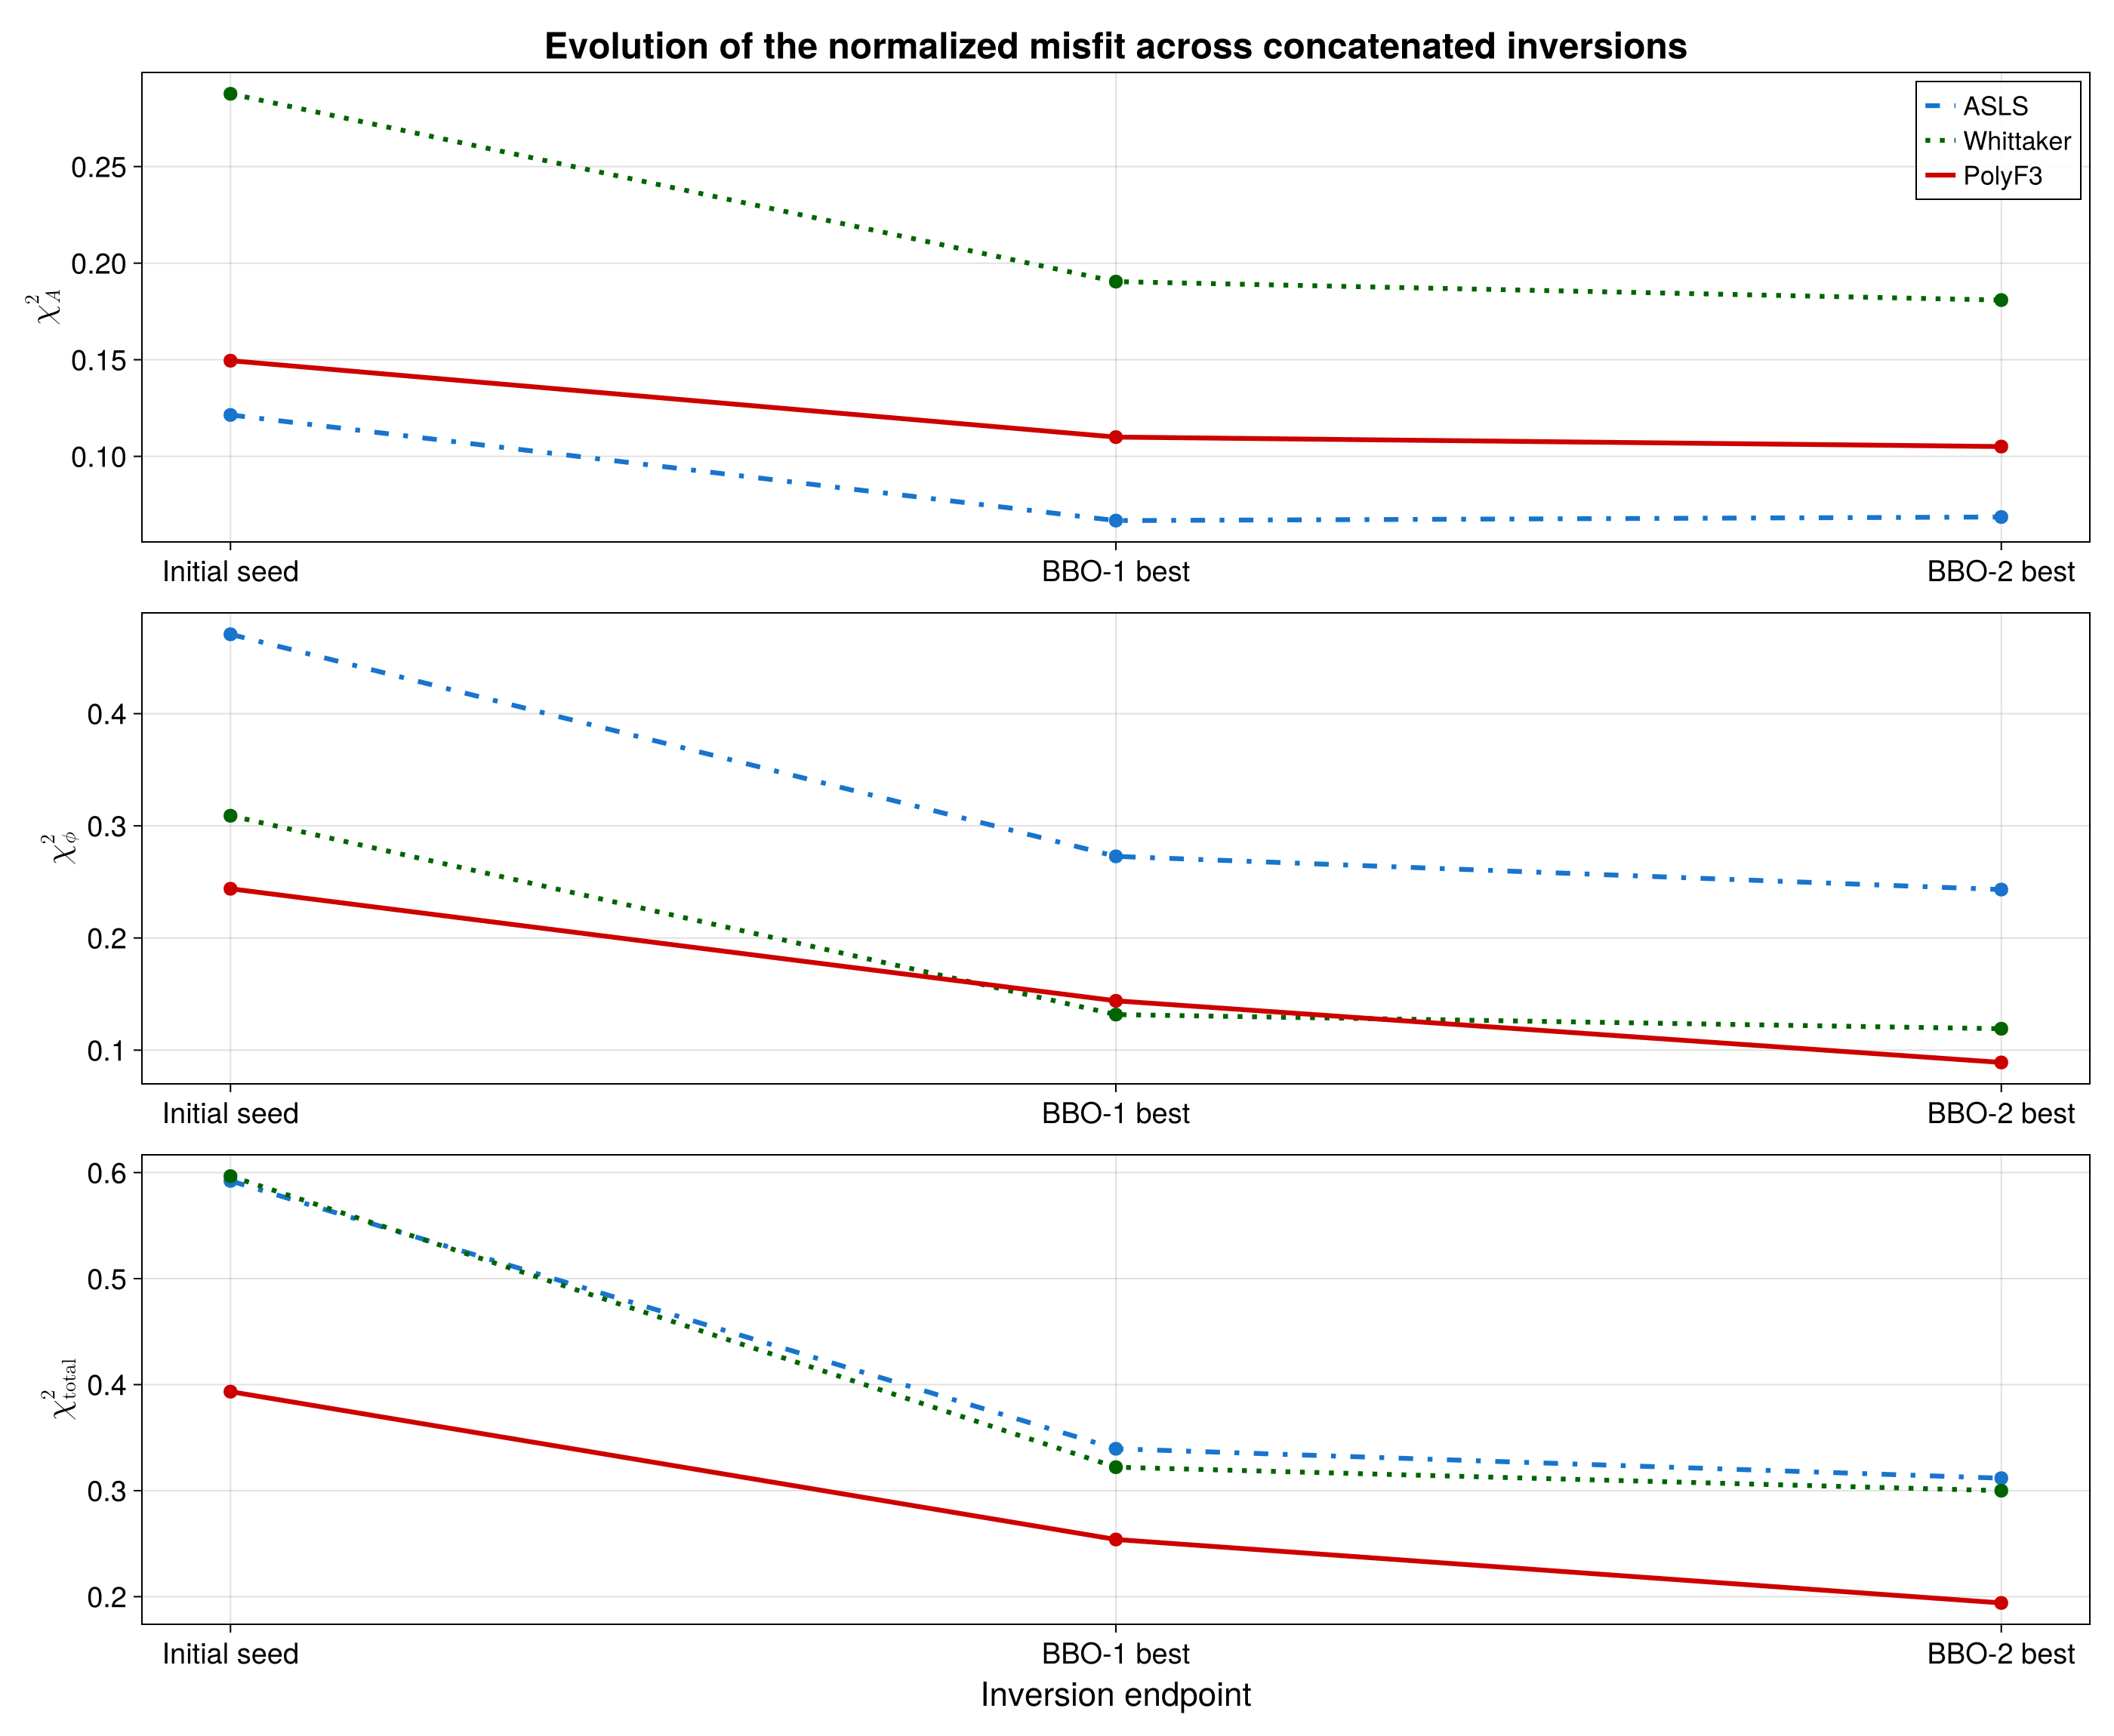

In [9]:

# ============================================================
# 7. Figure 1 — endpoint evolution, not optimizer history
# ============================================================
fig01 = CM.Figure(size = (1400, 1150))

axis_specs = [
    (1, L"\chi_A^2", :chi2_A),
    (2, L"\chi_\phi^2", :chi2_phi),
    (3, L"\chi_{\mathrm{total}}^2", :chi2_total),
]

for (row, ylabel, field) in axis_specs
    ax = CM.Axis(
        fig01[row, 1],
        ylabel = ylabel,
        xlabel = row == 3 ? "Inversion endpoint" : "",
        title = row == 1 ?
            "Evolution of the normalized misfit across concatenated inversions" : "",
        xticks = (1:3, STAGES),
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
    )

    for method in METHODS
        values = [getfield(METRICS17[(method, stage)], field) for stage in STAGES]

        CM.lines!(
            ax,
            1:3,
            values;
            color = METHOD_COLORS[method],
            linestyle = METHOD_LINESTYLES[method],
            linewidth = LW,
            label = method,
        )
        CM.scatter!(
            ax,
            1:3,
            values;
            color = METHOD_COLORS[method],
            markersize = 13,
        )
    end

    row == 1 && CM.axislegend(
        ax;
        position = :rt,
        labelsize = FS_LEGEND,
        framevisible = true,
        backgroundcolor = (:white, 0.90),
    )
end

fig01_paths = save_figure(fig01, "fig01_endpoint_misfit_evolution")

register_provenance!(
    "figures/fig01_endpoint_misfit_evolution";
    kind = "figure",
    source_files = [
        FILE_PATHS[:ASLS_BBO1], FILE_PATHS[:ASLS_BBO2],
        FILE_PATHS[:WHIT_BBO1], FILE_PATHS[:WHIT_BBO2],
        FILE_PATHS[:POLY_BBO1], FILE_PATHS[:POLY_BBO2],
    ],
    datasets = [
        "target_A_corr", "target_phi_corr",
        "initial/A_model", "initial/phi_model",
        "reconstruction/A_model", "reconstruction/phi_model",
    ],
    description = "Normalized endpoint misfits for the initial seed, BBO-1 best, and BBO-2 best.",
)

fig01


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/diagnostics/parameter_positions_within_bounds.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/diagnostics/parameter_positions_within_bounds.png


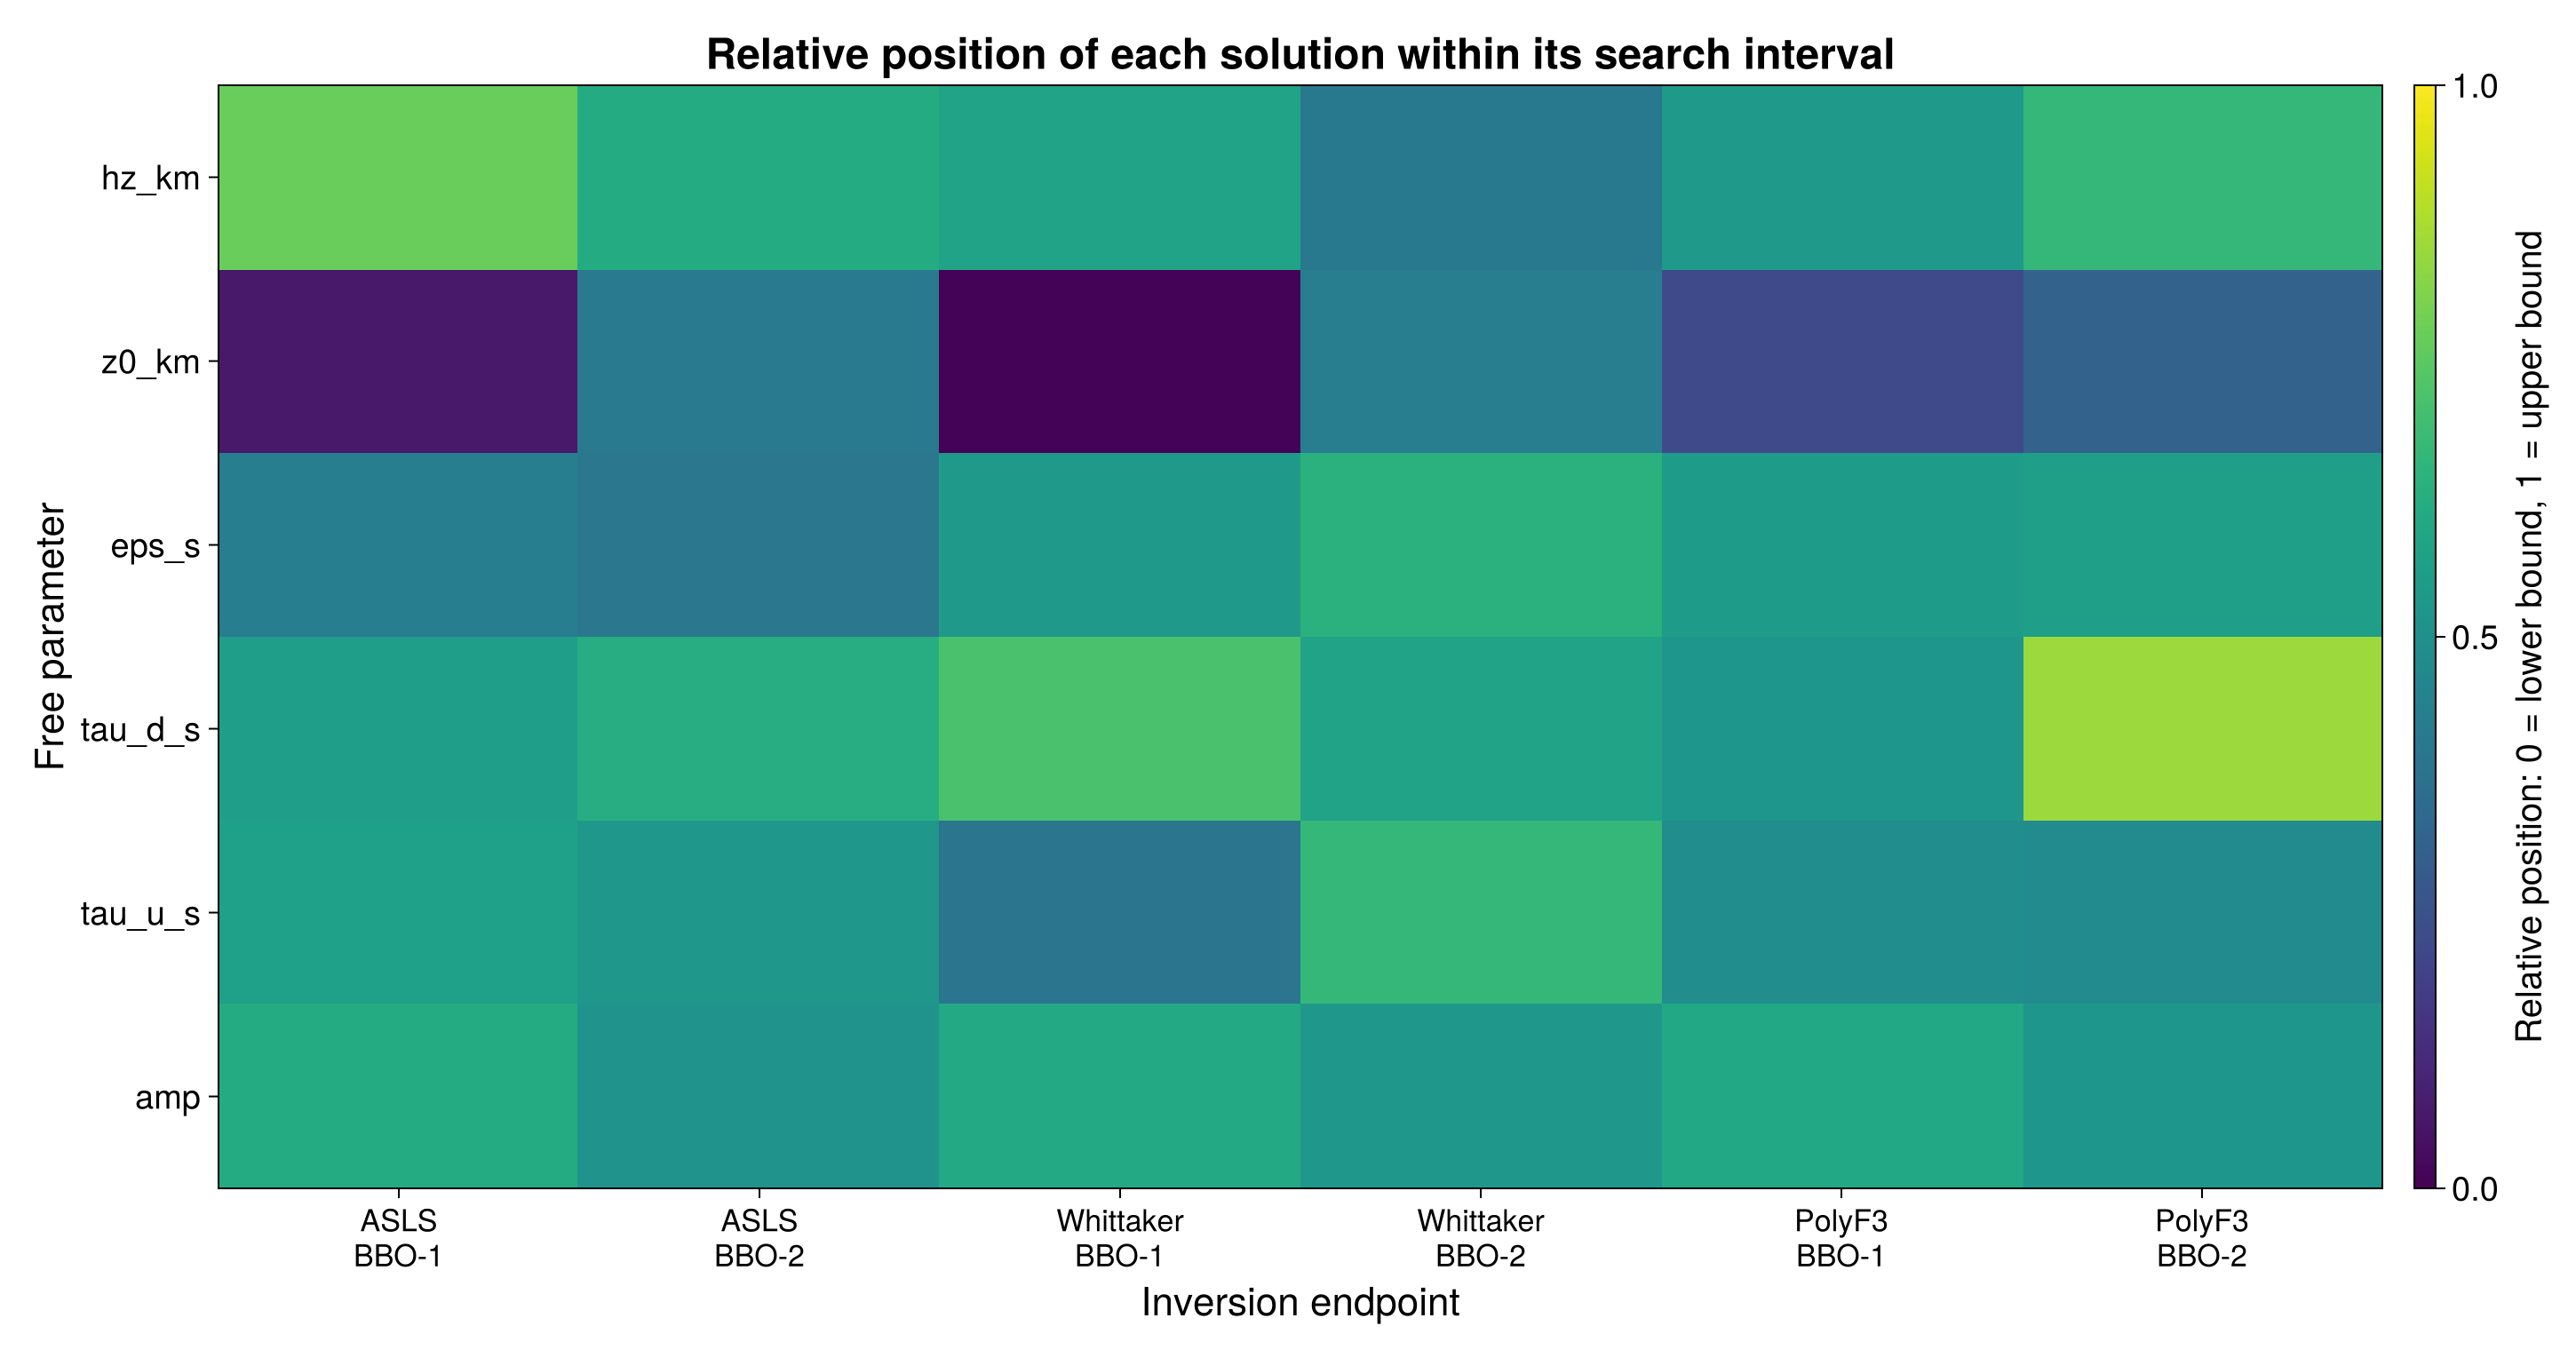

In [10]:

# ============================================================
# 8. Search-bound diagnostics
# ============================================================
FREE_PARAMETER_NAMES = ["amp", "tau_u_s", "tau_d_s", "eps_s", "z0_km", "hz_km"]
bound_rows = NamedTuple[]

for method in METHODS
    c = CHAINS[method]

    for (run, params, lower, upper) in [
        ("BBO-1 best", c.best1_params[[1, 3, 4, 5, 6, 7]], c.lower1, c.upper1),
        ("BBO-2 best", c.best2_params[[1, 3, 4, 5, 6, 7]], c.lower2, c.upper2),
    ]
        relative_position = (params .- lower) ./ (upper .- lower)

        for j in eachindex(FREE_PARAMETER_NAMES)
            push!(
                bound_rows,
                (
                    method = method,
                    run = run,
                    parameter = FREE_PARAMETER_NAMES[j],
                    value = params[j],
                    lower = lower[j],
                    upper = upper[j],
                    relative_position = relative_position[j],
                    distance_to_nearest_bound =
                        min(relative_position[j], 1.0 - relative_position[j]),
                ),
            )
        end
    end
end

bounds_df = DataFrame(bound_rows)
CSV.write(joinpath(DIAGNOSTICS_DIR, "parameter_positions_within_bounds.csv"), bounds_df)

bound_matrix = Matrix{Float64}(undef, length(FREE_PARAMETER_NAMES), 2 * length(METHODS))
bound_labels = String[]

col = 1
for method in METHODS
    for run in ("BBO-1 best", "BBO-2 best")
        subset = bounds_df[
            (bounds_df.method .== method) .&
            (bounds_df.run .== run),
            :,
        ]
        bound_matrix[:, col] = subset.relative_position
        push!(bound_labels, method * "\n" * replace(run, " best" => ""))
        col += 1
    end
end

fig_bounds = CM.Figure(size = (1450, 760))
ax_bounds = CM.Axis(
    fig_bounds[1, 1],
    title = "Relative position of each solution within its search interval",
    xlabel = "Inversion endpoint",
    ylabel = "Free parameter",
    xticks = (1:length(bound_labels), bound_labels),
    yticks = (1:length(FREE_PARAMETER_NAMES), FREE_PARAMETER_NAMES),
    xticklabelsize = FS_TICK - 2,
    yticklabelsize = FS_TICK,
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
)
hm_bounds = CM.heatmap!(
    ax_bounds,
    1:length(bound_labels),
    1:length(FREE_PARAMETER_NAMES),
    permutedims(bound_matrix);
    colorrange = (0.0, 1.0),
    colormap = :viridis,
)
CM.Colorbar(
    fig_bounds[1, 2],
    hm_bounds;
    label = "Relative position: 0 = lower bound, 1 = upper bound",
    labelsize = FS_LABEL - 2,
    ticklabelsize = FS_TICK,
)
save_figure(
    fig_bounds,
    "parameter_positions_within_bounds";
    directory = DIAGNOSTICS_DIR,
)

fig_bounds


In [11]:

# ============================================================
# 9. Quantify differences among the three 17-point targets
# ============================================================
target17_rows = NamedTuple[]

for i in 1:(length(METHODS) - 1)
    for j in (i + 1):length(METHODS)
        m1 = METHODS[i]
        m2 = METHODS[j]

        c1 = CHAINS[m1]
        c2 = CHAINS[m2]

        assert_same_grid(c1.time_unix, c2.time_unix; label = "$(m1)/$(m2) 17-point grids")

        dA = c1.A_target .- c2.A_target
        dphi = c1.phi_target .- c2.phi_target

        push!(
            target17_rows,
            (
                comparison = m1 * " − " * m2,
                RMSE_A_dB = sqrt(mean(dA .^ 2)),
                maxabs_A_dB = maximum(abs.(dA)),
                RMSE_phi_deg = sqrt(mean(dphi .^ 2)),
                maxabs_phi_deg = maximum(abs.(dphi)),
            ),
        )
    end
end

target17_comparison_df = DataFrame(target17_rows)
CSV.write(
    joinpath(DIAGNOSTICS_DIR, "target_17point_pairwise_differences.csv"),
    target17_comparison_df,
)

display(target17_comparison_df)


Row,comparison,RMSE_A_dB,maxabs_A_dB,RMSE_phi_deg,maxabs_phi_deg
,String,Float64,Float64,Float64,Float64
1,ASLS − Whittaker,0.0651123,0.154999,1.3579,5.27499
2,ASLS − PolyF3,0.0694826,0.154999,1.35814,5.27499
3,Whittaker − PolyF3,0.0242532,0.0999985,0.0254689,0.105011



## 6. Homogeneous comparison on the common 5-minute grid

The inter-family ranking is based on one common 49-point target. The 17-point targets remain relevant for auditing each inversion internally, but they are not assumed to be identical across background-separation families.


In [12]:

# ============================================================
# 10. Load the common 5-minute comparison
# ============================================================
COMMON_5MIN_H5 = FILE_PATHS[:SERIES_COMMON]
POLY_5MIN_H5 = FILE_PATHS[:SERIES_POLY]

time_common = readvec(COMMON_5MIN_H5, "time/timestamps_unix")
time_poly = readvec(POLY_5MIN_H5, "time/timestamps_unix")
assert_same_grid(time_common, time_poly; label = "common and PolyF3 5-minute grids")

time5_hours, time5_dt = time_hours_utc(time_poly)

A_target_5 = readvec(POLY_5MIN_H5, "target/A_dB")
phi_target_5 = readvec(POLY_5MIN_H5, "target/phi_deg")

MODELS5 = Dict(
    "ASLS" => (
        A = readvec(COMMON_5MIN_H5, "oldASLS_best2/A_model"),
        phi = readvec(COMMON_5MIN_H5, "oldASLS_best2/phi_model"),
        params = readvec(COMMON_5MIN_H5, "oldASLS_best2/full_params"),
    ),
    "Whittaker" => (
        A = readvec(COMMON_5MIN_H5, "whittaker_best2/A_model"),
        phi = readvec(COMMON_5MIN_H5, "whittaker_best2/phi_model"),
        params = readvec(COMMON_5MIN_H5, "whittaker_best2/full_params"),
    ),
    "PolyF3" => (
        A = readvec(POLY_5MIN_H5, "models/best2/A_dB"),
        phi = readvec(POLY_5MIN_H5, "models/best2/phi_deg"),
        params = readvec(POLY_5MIN_H5, "parameters/best2/full_params"),
    ),
)

for method in METHODS
    maximum(abs.(MODELS5[method].params .- CHAINS[method].best2_params)) <= 1e-10 ||
        error("$(method): the 5-minute series does not use the canonical BBO-2 parameters.")
end

# Audit the 5-minute target directly against the one-minute PolyF3 source.
poly_source_time = readvec(FILE_PATHS[:POLY_DATA], "time_unix")
poly_source_A = readvec(FILE_PATHS[:POLY_DATA], "A_real")
poly_source_phi = readvec(FILE_PATHS[:POLY_DATA], "phi_real")

poly_source_time_int = round.(Int, poly_source_time)

function source_index_for_time(t)
    idx = findfirst(==(round(Int, t)), poly_source_time_int)
    idx === nothing && error("A 5-minute timestamp is absent from the PolyF3 source.")
    return idx
end

source_indices = source_index_for_time.(time_poly)

A_target_from_source = poly_source_A[source_indices] .+ 19.0
phi_target_from_source = poly_source_phi[source_indices] .- 210.0

@assert maximum(abs.(A_target_from_source .- A_target_5)) == 0.0
@assert maximum(abs.(phi_target_from_source .- phi_target_5)) == 0.0

common_target_audit = DataFrame(
    quantity = ["Amplitude", "Phase"],
    max_abs_difference = [
        maximum(abs.(A_target_from_source .- A_target_5)),
        maximum(abs.(phi_target_from_source .- phi_target_5)),
    ],
    applied_offset = [19.0, -210.0],
    unit = ["dB", "deg"],
)

CSV.write(joinpath(TABLES_DIR, "common_5min_target_audit.csv"), common_target_audit)
display(common_target_audit)


Row,quantity,max_abs_difference,applied_offset,unit
,String,Float64,Float64,String
1,Amplitude,0.0,19.0,dB
2,Phase,0.0,-210.0,deg


In [13]:

# ============================================================
# 11. Final common metrics at 5-minute resolution
# ============================================================
metrics5_rows = NamedTuple[]
METRICS5 = Dict{String,NamedTuple}()

for method in METHODS
    model = MODELS5[method]
    met = normalized_metrics(model.A, model.phi, A_target_5, phi_target_5)
    METRICS5[method] = met

    push!(
        metrics5_rows,
        (
            method = method,
            chi2_A = met.chi2_A,
            chi2_phi = met.chi2_phi,
            chi2_total = met.chi2_total,
            RMSE_A_dB = met.RMSE_A_dB,
            RMSE_phi_deg = met.RMSE_phi_deg,
            bias_A_dB = met.bias_A_dB,
            bias_phi_deg = met.bias_phi_deg,
            maxabs_A_dB = met.maxabs_A_dB,
            maxabs_phi_deg = met.maxabs_phi_deg,
        ),
    )
end

metrics5_df = DataFrame(metrics5_rows)
sort!(metrics5_df, :chi2_total)

CSV.write(joinpath(TABLES_DIR, "final_metrics_common_5min.csv"), metrics5_df)

write_latex_table(
    select(
        metrics5_df,
        :method,
        :chi2_A,
        :chi2_phi,
        :chi2_total,
        :RMSE_A_dB,
        :RMSE_phi_deg,
    ),
    joinpath(TABLES_DIR, "final_metrics_common_5min.tex");
    caption = "Common 5-minute comparison of the final perturbation reconstructions.",
    label = "tab:perturbation_common_5min",
    column_labels = [
        "Method", raw"$\chi_A^2$", raw"$\chi_\phi^2$",
        raw"$\chi_{\mathrm{total}}^2$", raw"$\mathrm{RMSE}_A$ [dB]",
        raw"$\mathrm{RMSE}_\phi$ [$^\circ$]",
    ],
    digits = 6,
)

display(metrics5_df)

register_provenance!(
    "tables/final_metrics_common_5min";
    kind = "table",
    source_files = [COMMON_5MIN_H5, POLY_5MIN_H5],
    datasets = [
        "oldASLS_best2/A_model", "oldASLS_best2/phi_model",
        "whittaker_best2/A_model", "whittaker_best2/phi_model",
        "models/best2/A_dB", "models/best2/phi_deg",
        "target/A_dB", "target/phi_deg",
    ],
    description = "Homogeneous 49-point comparison against the same observed amplitude and phase target.",
)


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/tables/final_metrics_common_5min.tex


Row,method,chi2_A,chi2_phi,chi2_total,RMSE_A_dB,RMSE_phi_deg,bias_A_dB,bias_phi_deg,maxabs_A_dB,maxabs_phi_deg
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,PolyF3,0.0972514,0.0889919,0.186243,0.737906,10.6146,-0.0422203,-3.70214,1.49123,20.233
2,Whittaker,0.167012,0.114903,0.281915,0.967001,12.0613,-0.467703,-5.66877,2.01386,24.1206
3,ASLS,0.0692188,0.236312,0.30553,0.622537,17.297,-0.164485,-12.723,1.5704,29.1251


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig02_real_vs_reconstructed_5min.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig02_real_vs_reconstructed_5min.png


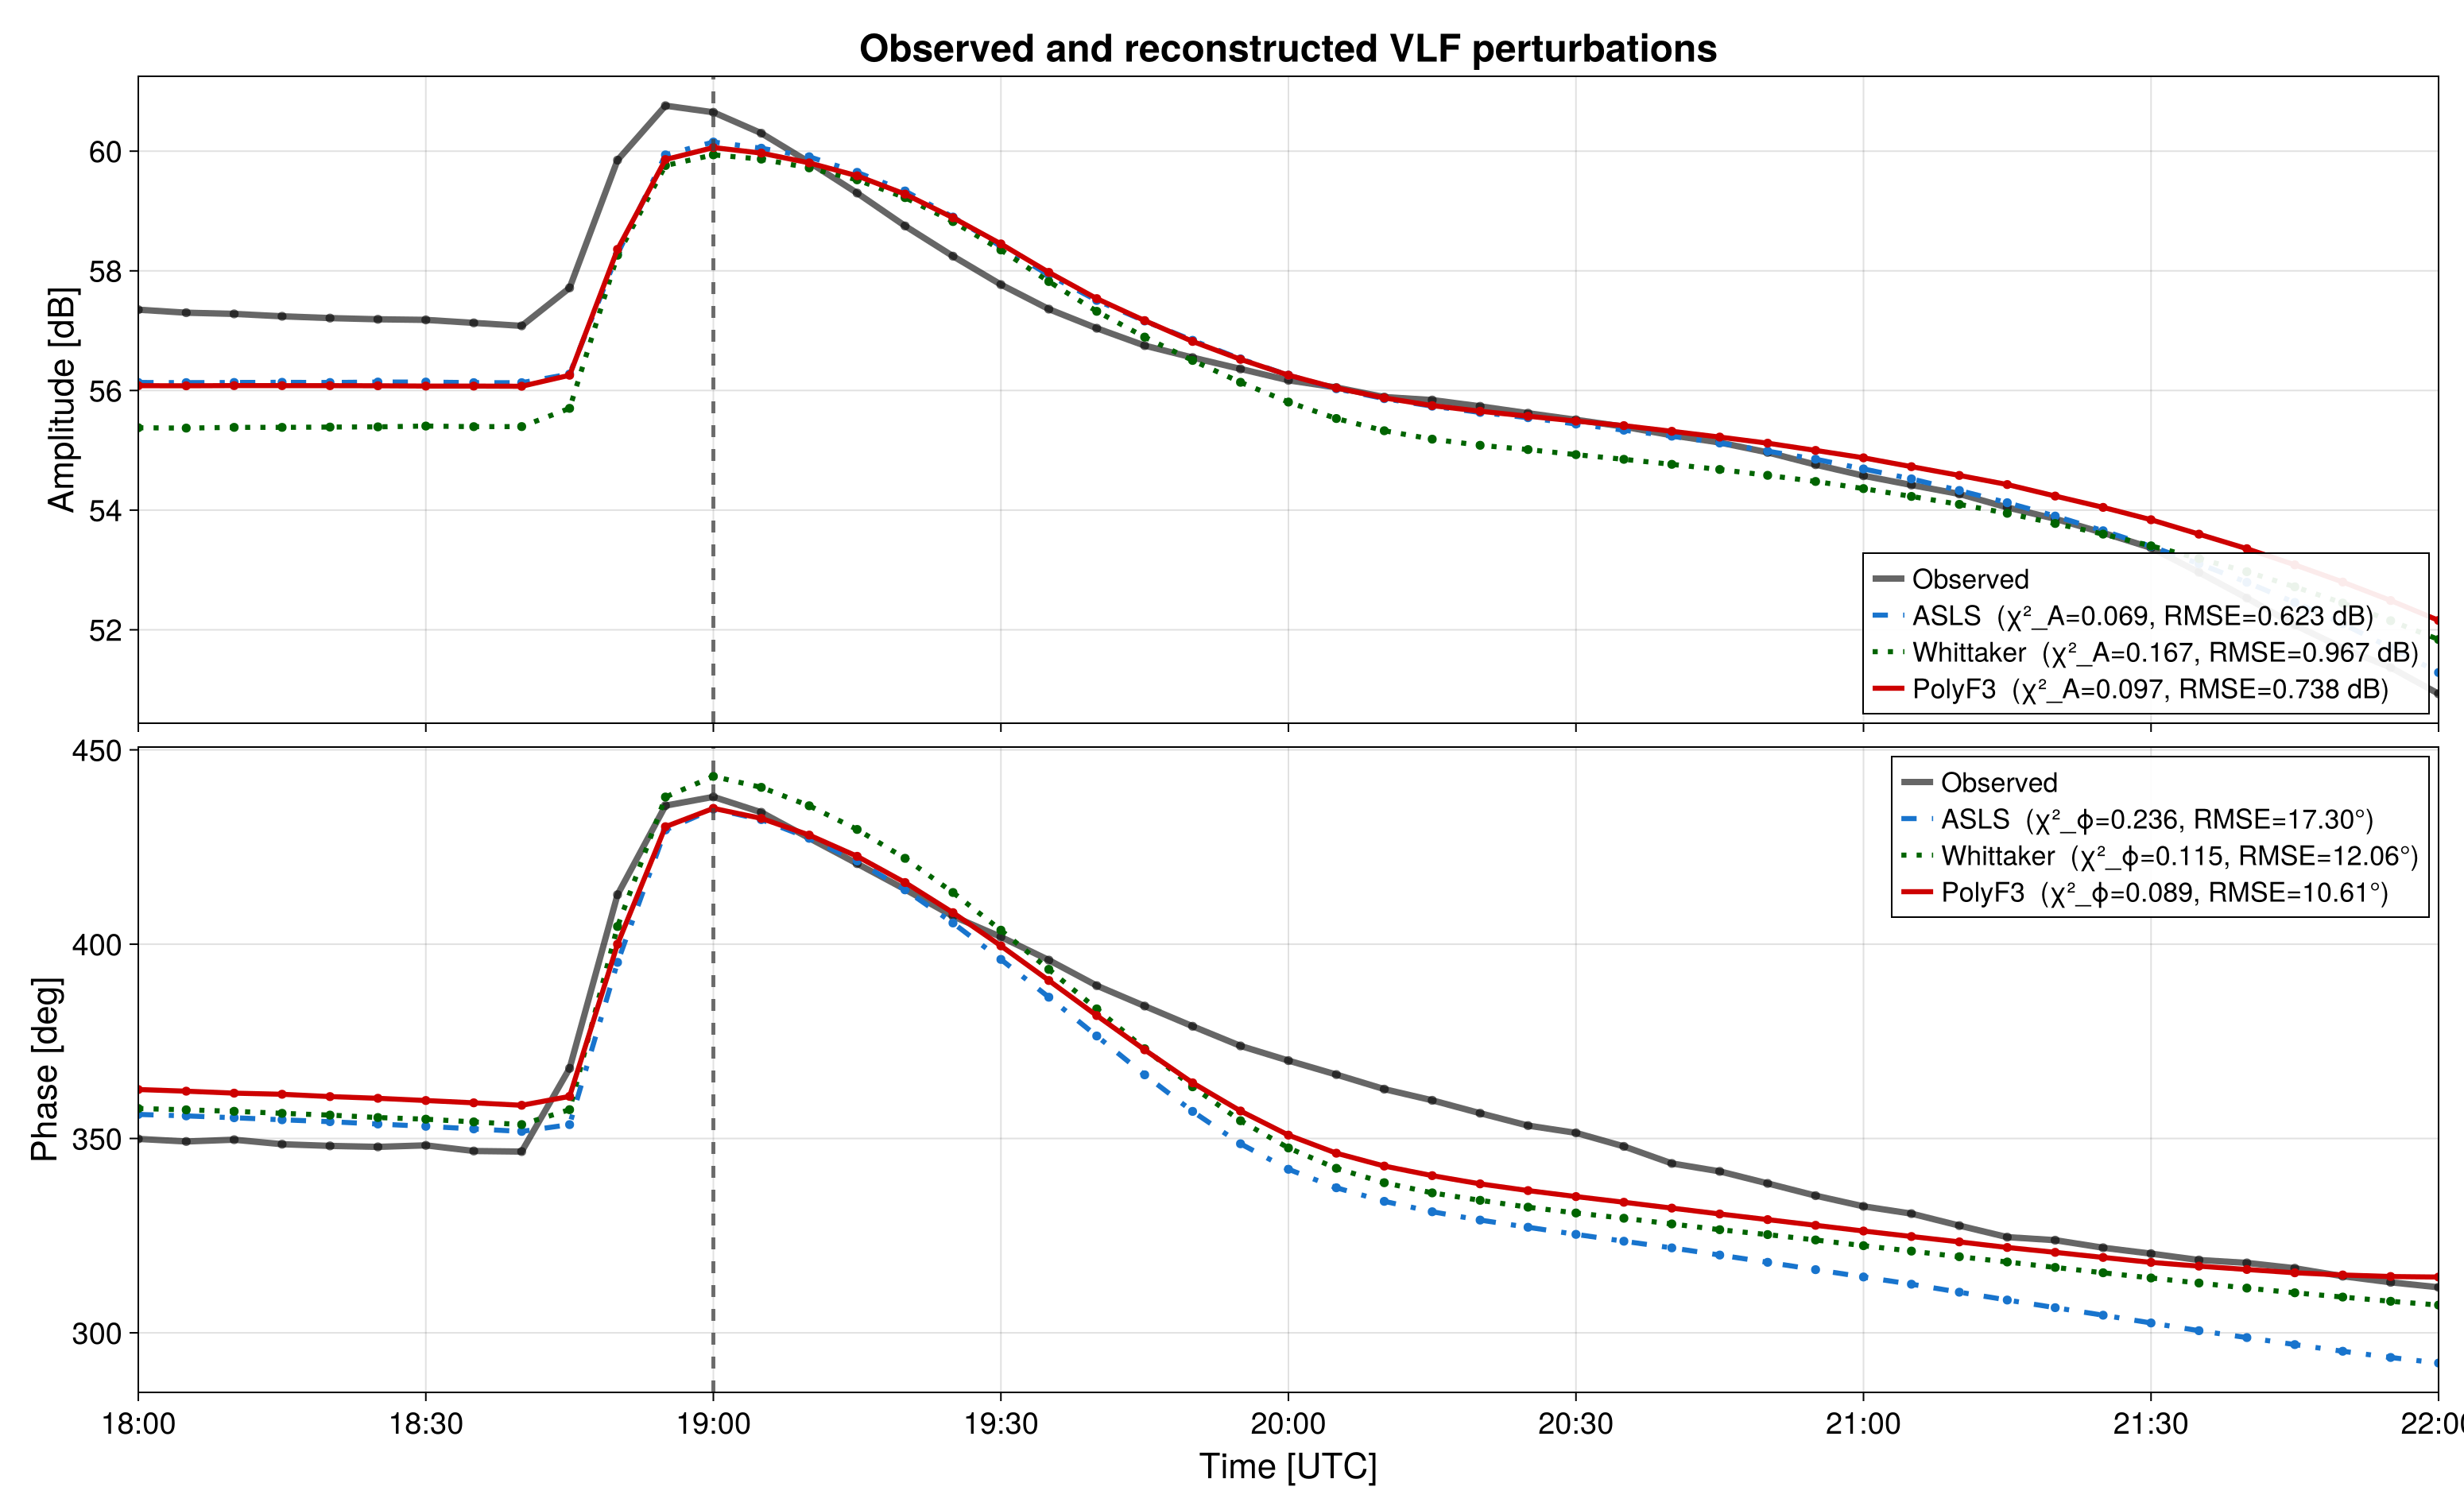

In [14]:

# ============================================================
# 12. Figure 2 — observed and reconstructed amplitude and phase
# ============================================================
fig02 = CM.Figure(size = (1550, 950))

axA = CM.Axis(
    fig02[1, 1],
    title = "Observed and reconstructed VLF perturbations",
    ylabel = "Amplitude [dB]",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, nothing, nothing),
    xticklabelsvisible = false,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
)

CM.lines!(axA, time5_hours, A_target_5; color = (:black, 0.60), linewidth = 4.0, label = "Observed")
CM.scatter!(axA, time5_hours, A_target_5; color = (:black, 0.60), markersize = 8)

for method in METHODS
    met = METRICS5[method]
    label = @sprintf(
        "%s  (χ²_A=%.3f, RMSE=%.3f dB)",
        method,
        met.chi2_A,
        met.RMSE_A_dB,
    )

    CM.lines!(
        axA,
        time5_hours,
        MODELS5[method].A;
        color = METHOD_COLORS[method],
        linestyle = METHOD_LINESTYLES[method],
        linewidth = LW,
        label = label,
    )
    CM.scatter!(
        axA,
        time5_hours,
        MODELS5[method].A;
        color = METHOD_COLORS[method],
        markersize = 8,
    )
end

CM.vlines!(axA, [19.0]; color = (:gray25, 0.75), linestyle = :dash, linewidth = 2.5)
CM.axislegend(
    axA;
    position = :rb,
    labelsize = FS_LEGEND,
    framevisible = true,
    backgroundcolor = (:white, 0.92),
)

axP = CM.Axis(
    fig02[2, 1],
    xlabel = "Time [UTC]",
    ylabel = "Phase [deg]",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, nothing, nothing),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
)

CM.lines!(axP, time5_hours, phi_target_5; color = (:black, 0.60), linewidth = 4.0, label = "Observed")
CM.scatter!(axP, time5_hours, phi_target_5; color = (:black, 0.60), markersize = 8)

for method in METHODS
    met = METRICS5[method]
    label = @sprintf(
        "%s  (χ²_ϕ=%.3f, RMSE=%.2f°)",
        method,
        met.chi2_phi,
        met.RMSE_phi_deg,
    )

    CM.lines!(
        axP,
        time5_hours,
        MODELS5[method].phi;
        color = METHOD_COLORS[method],
        linestyle = METHOD_LINESTYLES[method],
        linewidth = LW,
        label = label,
    )
    CM.scatter!(
        axP,
        time5_hours,
        MODELS5[method].phi;
        color = METHOD_COLORS[method],
        markersize = 8,
    )
end

CM.vlines!(axP, [19.0]; color = (:gray25, 0.75), linestyle = :dash, linewidth = 2.5)
CM.axislegend(
    axP;
    position = :rt,
    labelsize = FS_LEGEND,
    framevisible = true,
    backgroundcolor = (:white, 0.92),
)

CM.linkxaxes!(axA, axP)
CM.rowgap!(fig02.layout, 10)

save_figure(fig02, "fig02_real_vs_reconstructed_5min")

register_provenance!(
    "figures/fig02_real_vs_reconstructed_5min";
    kind = "figure",
    source_files = [COMMON_5MIN_H5, POLY_5MIN_H5],
    datasets = [
        "target/A_dB", "target/phi_deg",
        "oldASLS_best2/A_model", "oldASLS_best2/phi_model",
        "whittaker_best2/A_model", "whittaker_best2/phi_model",
        "models/best2/A_dB", "models/best2/phi_deg",
    ],
    description = "Observed and reconstructed VLF amplitude and phase on the common 5-minute grid.",
)

fig02


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig03_residuals_5min.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig03_residuals_5min.png


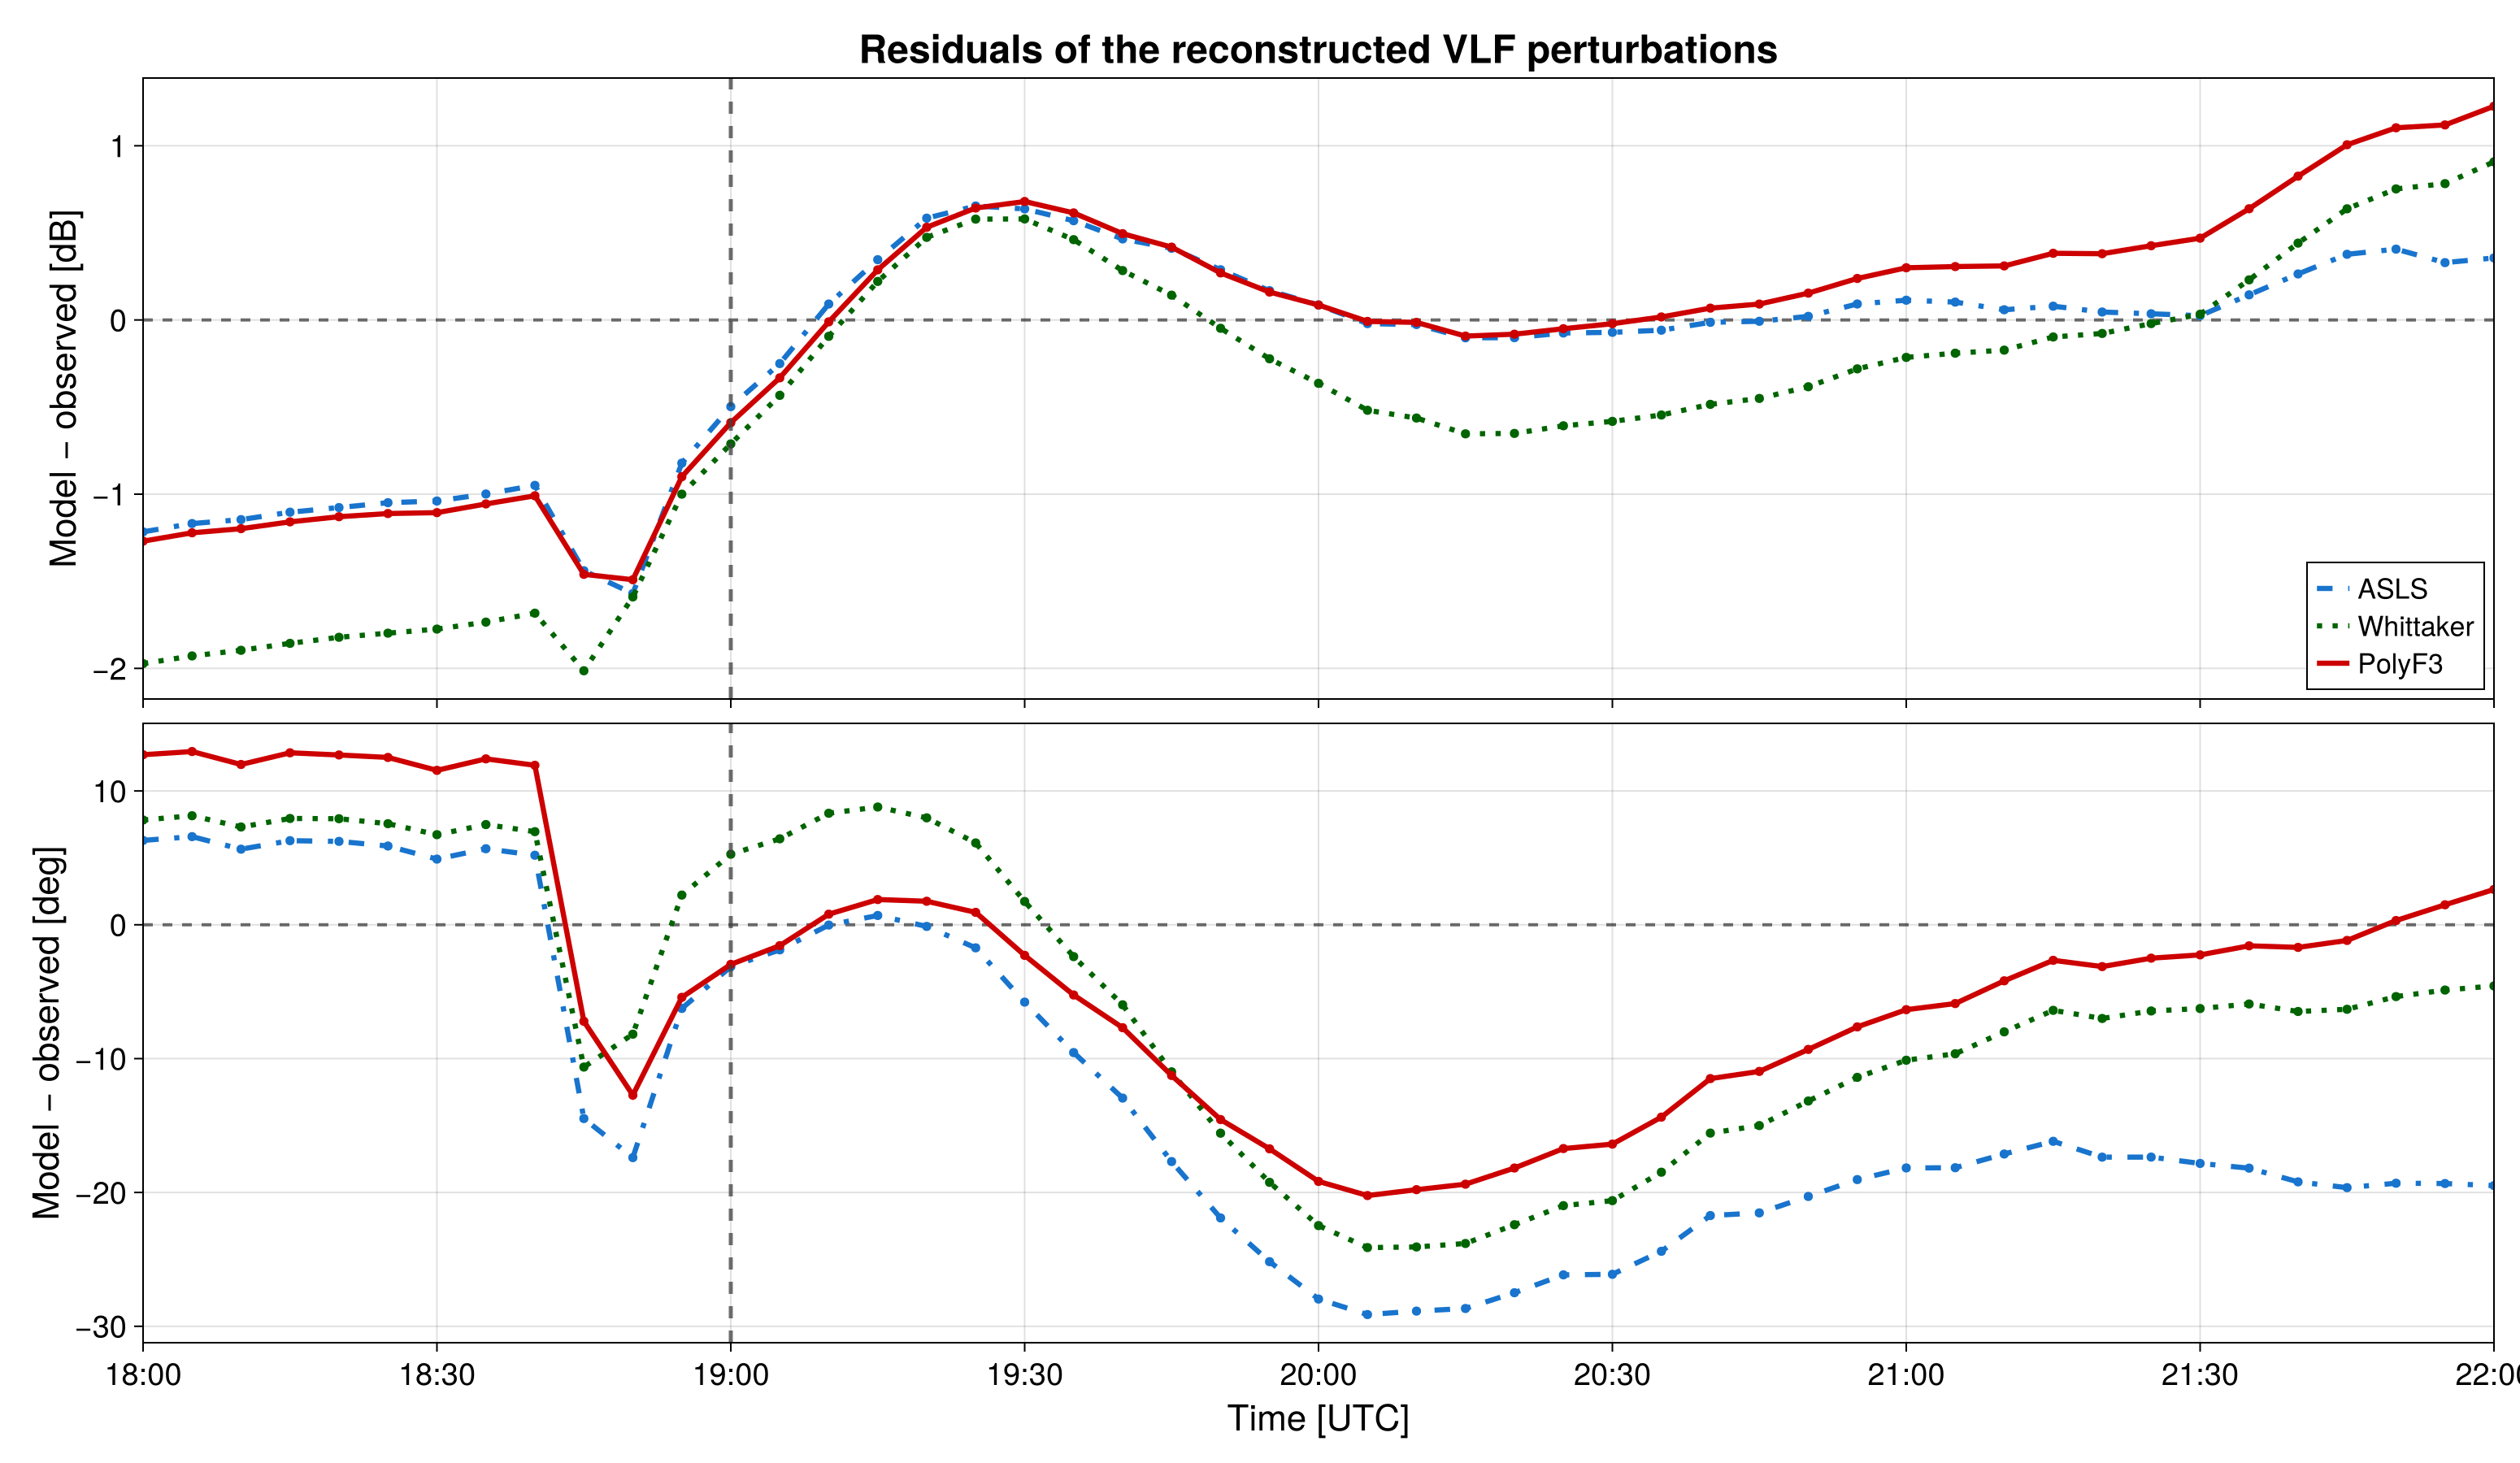

In [15]:

# ============================================================
# 13. Figure 3 — temporal residuals
# ============================================================
RESIDUALS5 = Dict(
    method => (
        A = MODELS5[method].A .- A_target_5,
        phi = MODELS5[method].phi .- phi_target_5,
    )
    for method in METHODS
)

fig03 = CM.Figure(size = (1550, 900))

axRA = CM.Axis(
    fig03[1, 1],
    title = "Residuals of the reconstructed VLF perturbations",
    ylabel = "Model − observed [dB]",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, nothing, nothing),
    xticklabelsvisible = false,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
)
CM.hlines!(axRA, [0.0]; color = (:black, 0.55), linestyle = :dash, linewidth = 2)

for method in METHODS
    CM.lines!(
        axRA,
        time5_hours,
        RESIDUALS5[method].A;
        color = METHOD_COLORS[method],
        linestyle = METHOD_LINESTYLES[method],
        linewidth = LW,
        label = method,
    )
    CM.scatter!(
        axRA,
        time5_hours,
        RESIDUALS5[method].A;
        color = METHOD_COLORS[method],
        markersize = 8,
    )
end
CM.vlines!(axRA, [19.0]; color = (:gray25, 0.75), linestyle = :dash, linewidth = 2.5)
CM.axislegend(axRA; position = :rb, labelsize = FS_LEGEND)

axRP = CM.Axis(
    fig03[2, 1],
    xlabel = "Time [UTC]",
    ylabel = "Model − observed [deg]",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, nothing, nothing),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
)
CM.hlines!(axRP, [0.0]; color = (:black, 0.55), linestyle = :dash, linewidth = 2)

for method in METHODS
    CM.lines!(
        axRP,
        time5_hours,
        RESIDUALS5[method].phi;
        color = METHOD_COLORS[method],
        linestyle = METHOD_LINESTYLES[method],
        linewidth = LW,
        label = method,
    )
    CM.scatter!(
        axRP,
        time5_hours,
        RESIDUALS5[method].phi;
        color = METHOD_COLORS[method],
        markersize = 8,
    )
end
CM.vlines!(axRP, [19.0]; color = (:gray25, 0.75), linestyle = :dash, linewidth = 2.5)

CM.linkxaxes!(axRA, axRP)
CM.rowgap!(fig03.layout, 10)

save_figure(fig03, "fig03_residuals_5min")

register_provenance!(
    "figures/fig03_residuals_5min";
    kind = "figure",
    source_files = [COMMON_5MIN_H5, POLY_5MIN_H5],
    datasets = [
        "target/A_dB", "target/phi_deg",
        "oldASLS_best2/A_model", "oldASLS_best2/phi_model",
        "whittaker_best2/A_model", "whittaker_best2/phi_model",
        "models/best2/A_dB", "models/best2/phi_deg",
    ],
    description = "Model-minus-observation residuals for the three final reconstructions.",
)

fig03


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig04_weight_sensitivity.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig04_weight_sensitivity.png


Row,comparison,wA_over_wphi
,String,Float64
1,ASLS = PolyF3,5.2553
2,ASLS = Whittaker,1.24148
3,Whittaker = PolyF3,-0.371429


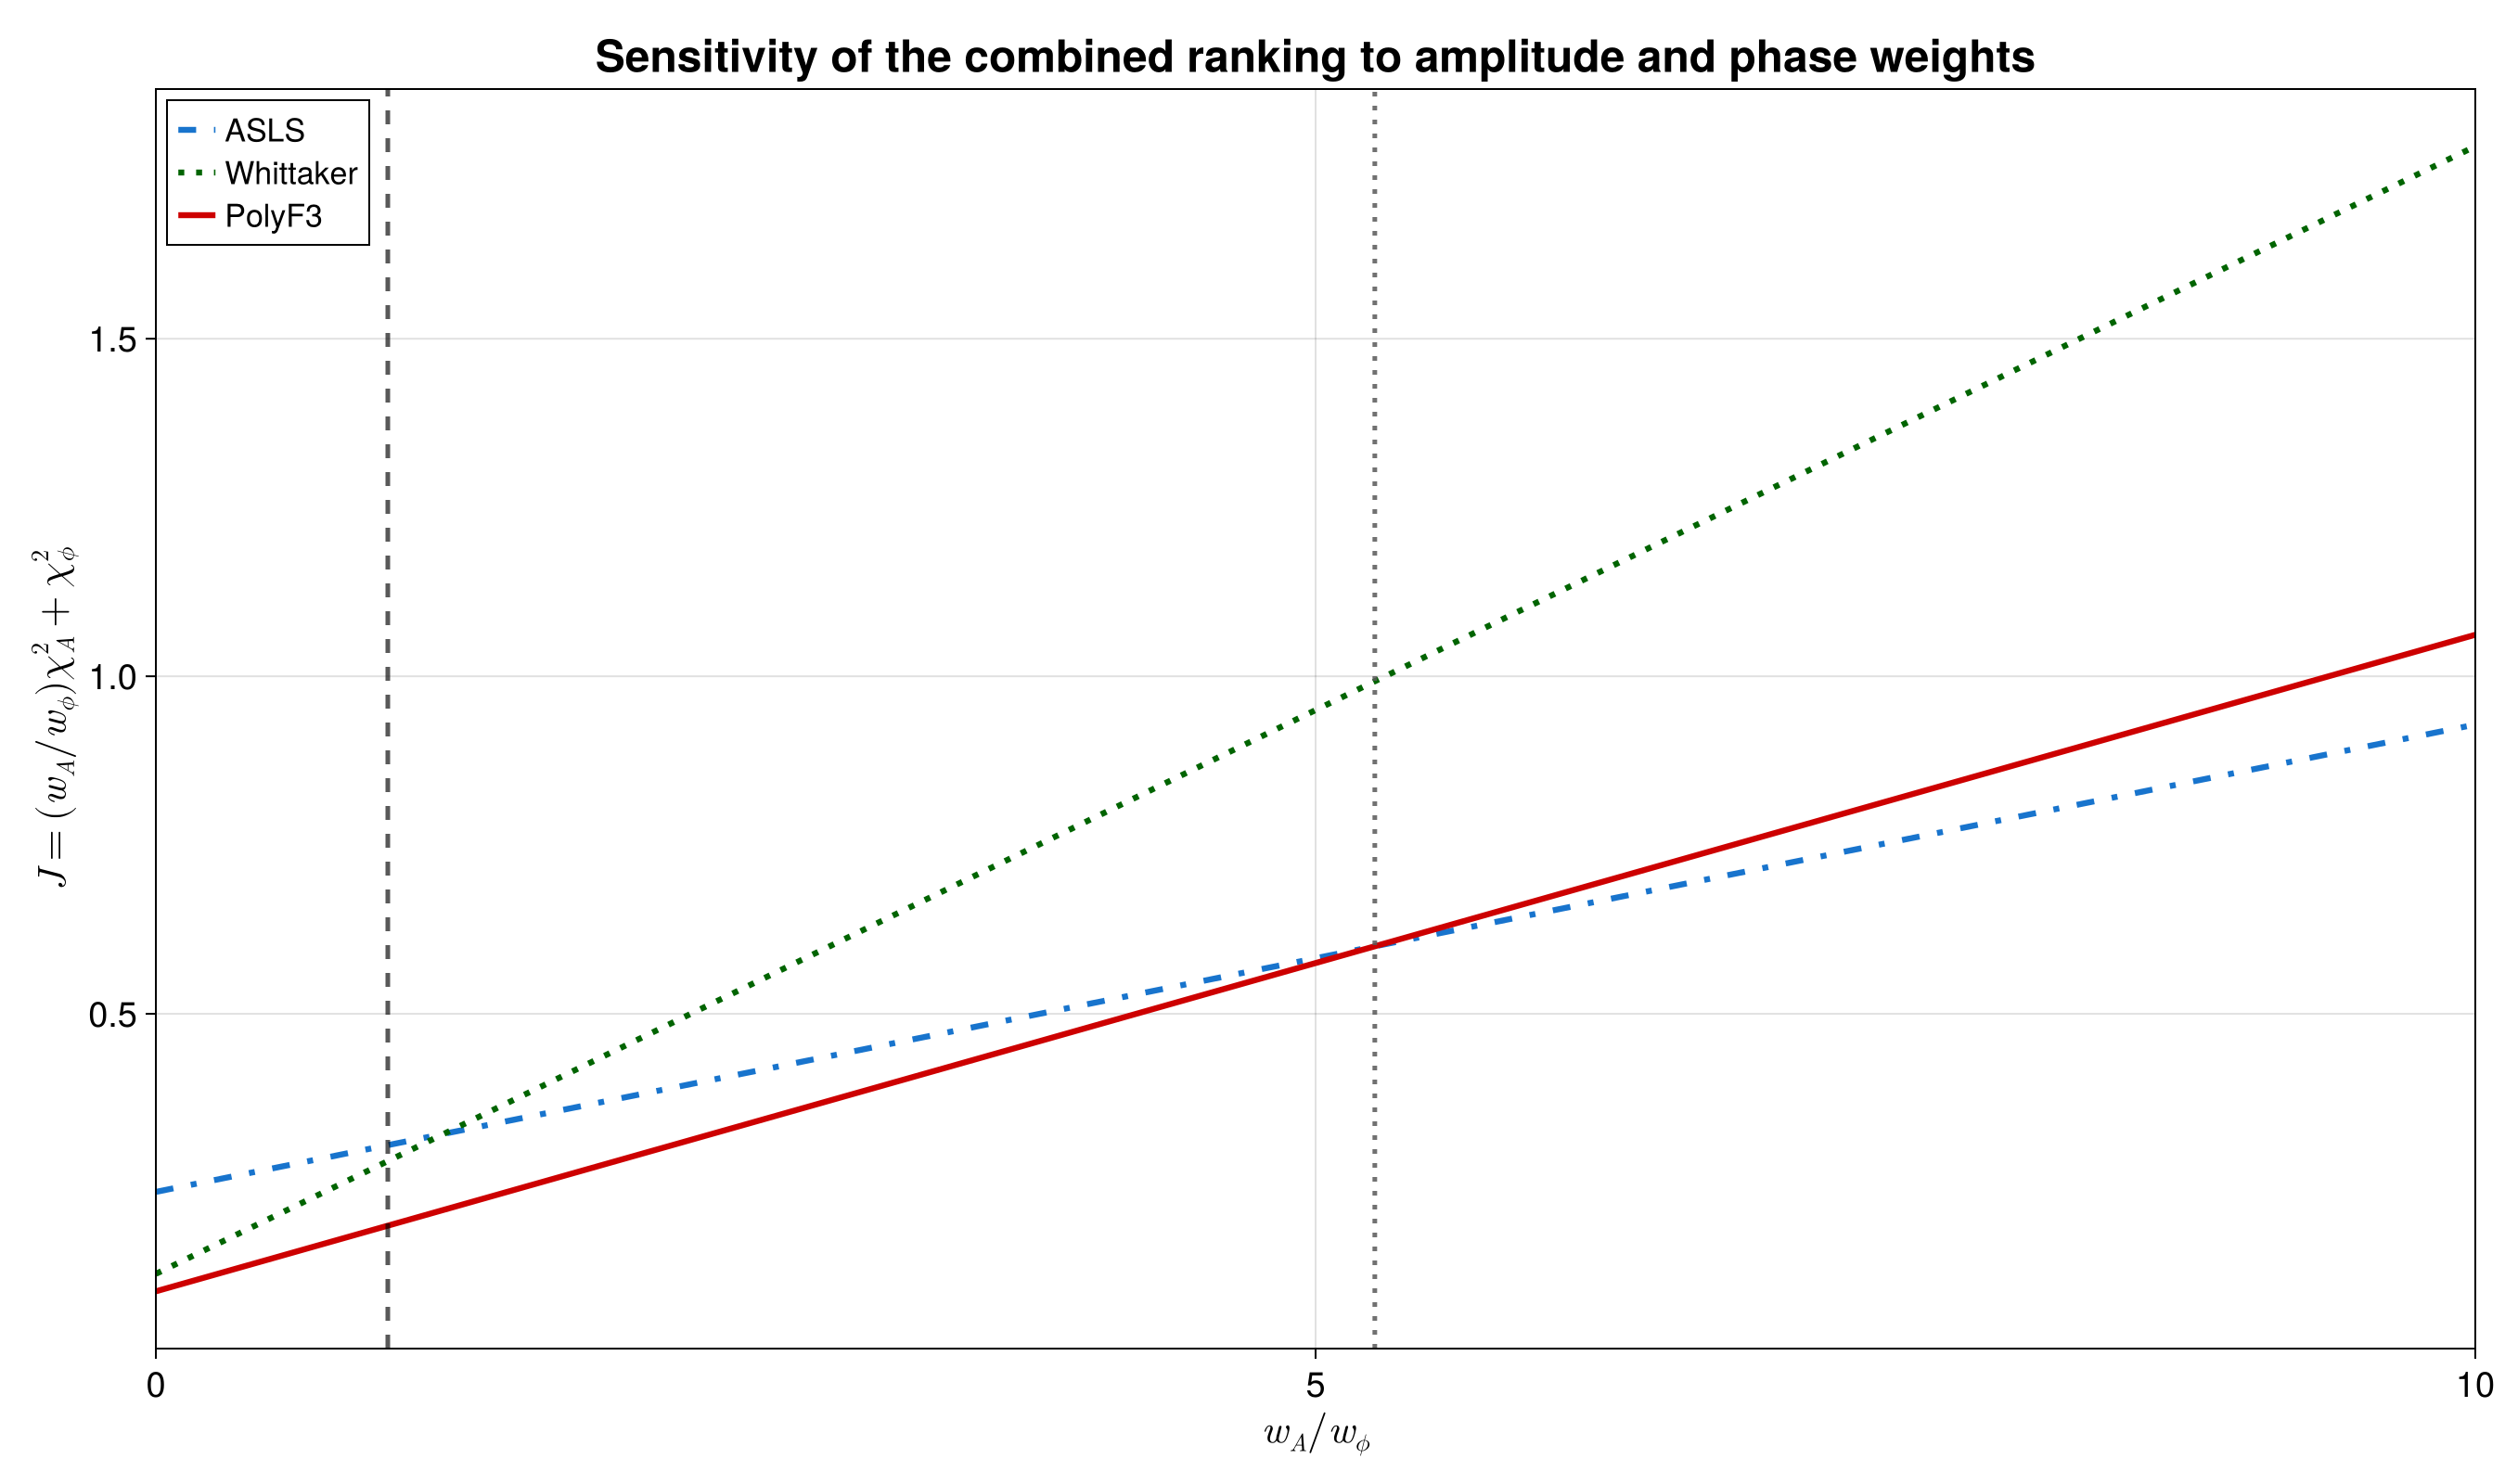

In [16]:

# ============================================================
# 14. Figure 4 — sensitivity of the ranking to amplitude/phase weights
# ============================================================
weight_ratio = collect(range(0.0, 10.0; length = 501))
WEIGHTED_LOSS = Dict(
    method => weight_ratio .* METRICS5[method].chi2_A .+ METRICS5[method].chi2_phi
    for method in METHODS
)

function crossover_ratio(method1::String, method2::String)
    m1 = METRICS5[method1]
    m2 = METRICS5[method2]
    denominator = m1.chi2_A - m2.chi2_A

    abs(denominator) <= eps(Float64) && return NaN
    return (m2.chi2_phi - m1.chi2_phi) / denominator
end

crossovers_df = DataFrame(
    comparison = ["ASLS = PolyF3", "ASLS = Whittaker", "Whittaker = PolyF3"],
    wA_over_wphi = [
        crossover_ratio("ASLS", "PolyF3"),
        crossover_ratio("ASLS", "Whittaker"),
        crossover_ratio("Whittaker", "PolyF3"),
    ],
)
CSV.write(joinpath(DIAGNOSTICS_DIR, "weight_crossovers.csv"), crossovers_df)

fig04 = CM.Figure(size = (1350, 800))
axW = CM.Axis(
    fig04[1, 1],
    title = "Sensitivity of the combined ranking to amplitude and phase weights",
    xlabel = L"w_A/w_\phi",
    ylabel = L"J = (w_A/w_\phi)\chi_A^2 + \chi_\phi^2",
    limits = (0.0, 10.0, nothing, nothing),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
)

for method in METHODS
    CM.lines!(
        axW,
        weight_ratio,
        WEIGHTED_LOSS[method];
        color = METHOD_COLORS[method],
        linestyle = METHOD_LINESTYLES[method],
        linewidth = LW,
        label = method,
    )
end

CM.vlines!(axW, [1.0]; color = (:black, 0.65), linestyle = :dash, linewidth = 2.5)

asls_poly_cross = crossovers_df.wA_over_wphi[1]
if isfinite(asls_poly_cross) && 0.0 <= asls_poly_cross <= 10.0
    CM.vlines!(
        axW,
        [asls_poly_cross];
        color = (:gray35, 0.85),
        linestyle = :dot,
        linewidth = 2.5,
    )
end

CM.axislegend(axW; position = :lt, labelsize = FS_LEGEND)
save_figure(fig04, "fig04_weight_sensitivity")

register_provenance!(
    "figures/fig04_weight_sensitivity";
    kind = "figure",
    source_files = [COMMON_5MIN_H5, POLY_5MIN_H5],
    datasets = ["final common 5-minute metrics derived from model and target arrays"],
    description = "Weighted total loss as a function of the relative amplitude-to-phase weight.",
)

display(crossovers_df)
fig04


Row,method,interval,n_points,RMSE_A_dB,bias_A_dB,maxabs_A_dB,RMSE_phi_deg,bias_phi_deg,maxabs_phi_deg
,String,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,ASLS,"Pre-peak [18:00, 19:00)",12,1.14865,-1.13177,1.5704,8.47885,1.21477,17.3996
2,ASLS,"Early response [19:00, 19:30]",7,0.48019,0.223563,0.65414,2.67812,-1.70967,5.7798
3,ASLS,"Recovery (19:30, 22:00]",30,0.226807,0.131886,0.569538,21.4066,-20.8679,29.1251
4,Whittaker,"Pre-peak [18:00, 19:00)",12,1.7744,-1.75589,2.01386,7.62863,4.27249,10.6333
5,Whittaker,"Early response [19:00, 19:30]",7,0.485061,0.0878528,0.711535,6.7615,6.38019,8.79772
6,Whittaker,"Recovery (19:30, 22:00]",30,0.461541,-0.0820576,0.907614,14.271,-12.4567,24.1206
7,PolyF3,"Pre-peak [18:00, 19:00)",12,1.18742,-1.17609,1.49123,11.644,7.17791,12.9434
8,PolyF3,"Early response [19:00, 19:30]",7,0.492655,0.172746,0.679865,1.87246,-0.207637,2.96002
9,PolyF3,"Recovery (19:30, 22:00]",30,0.518399,0.361168,1.22666,11.3567,-8.86954,20.233


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig05_interval_rmse.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig05_interval_rmse.png


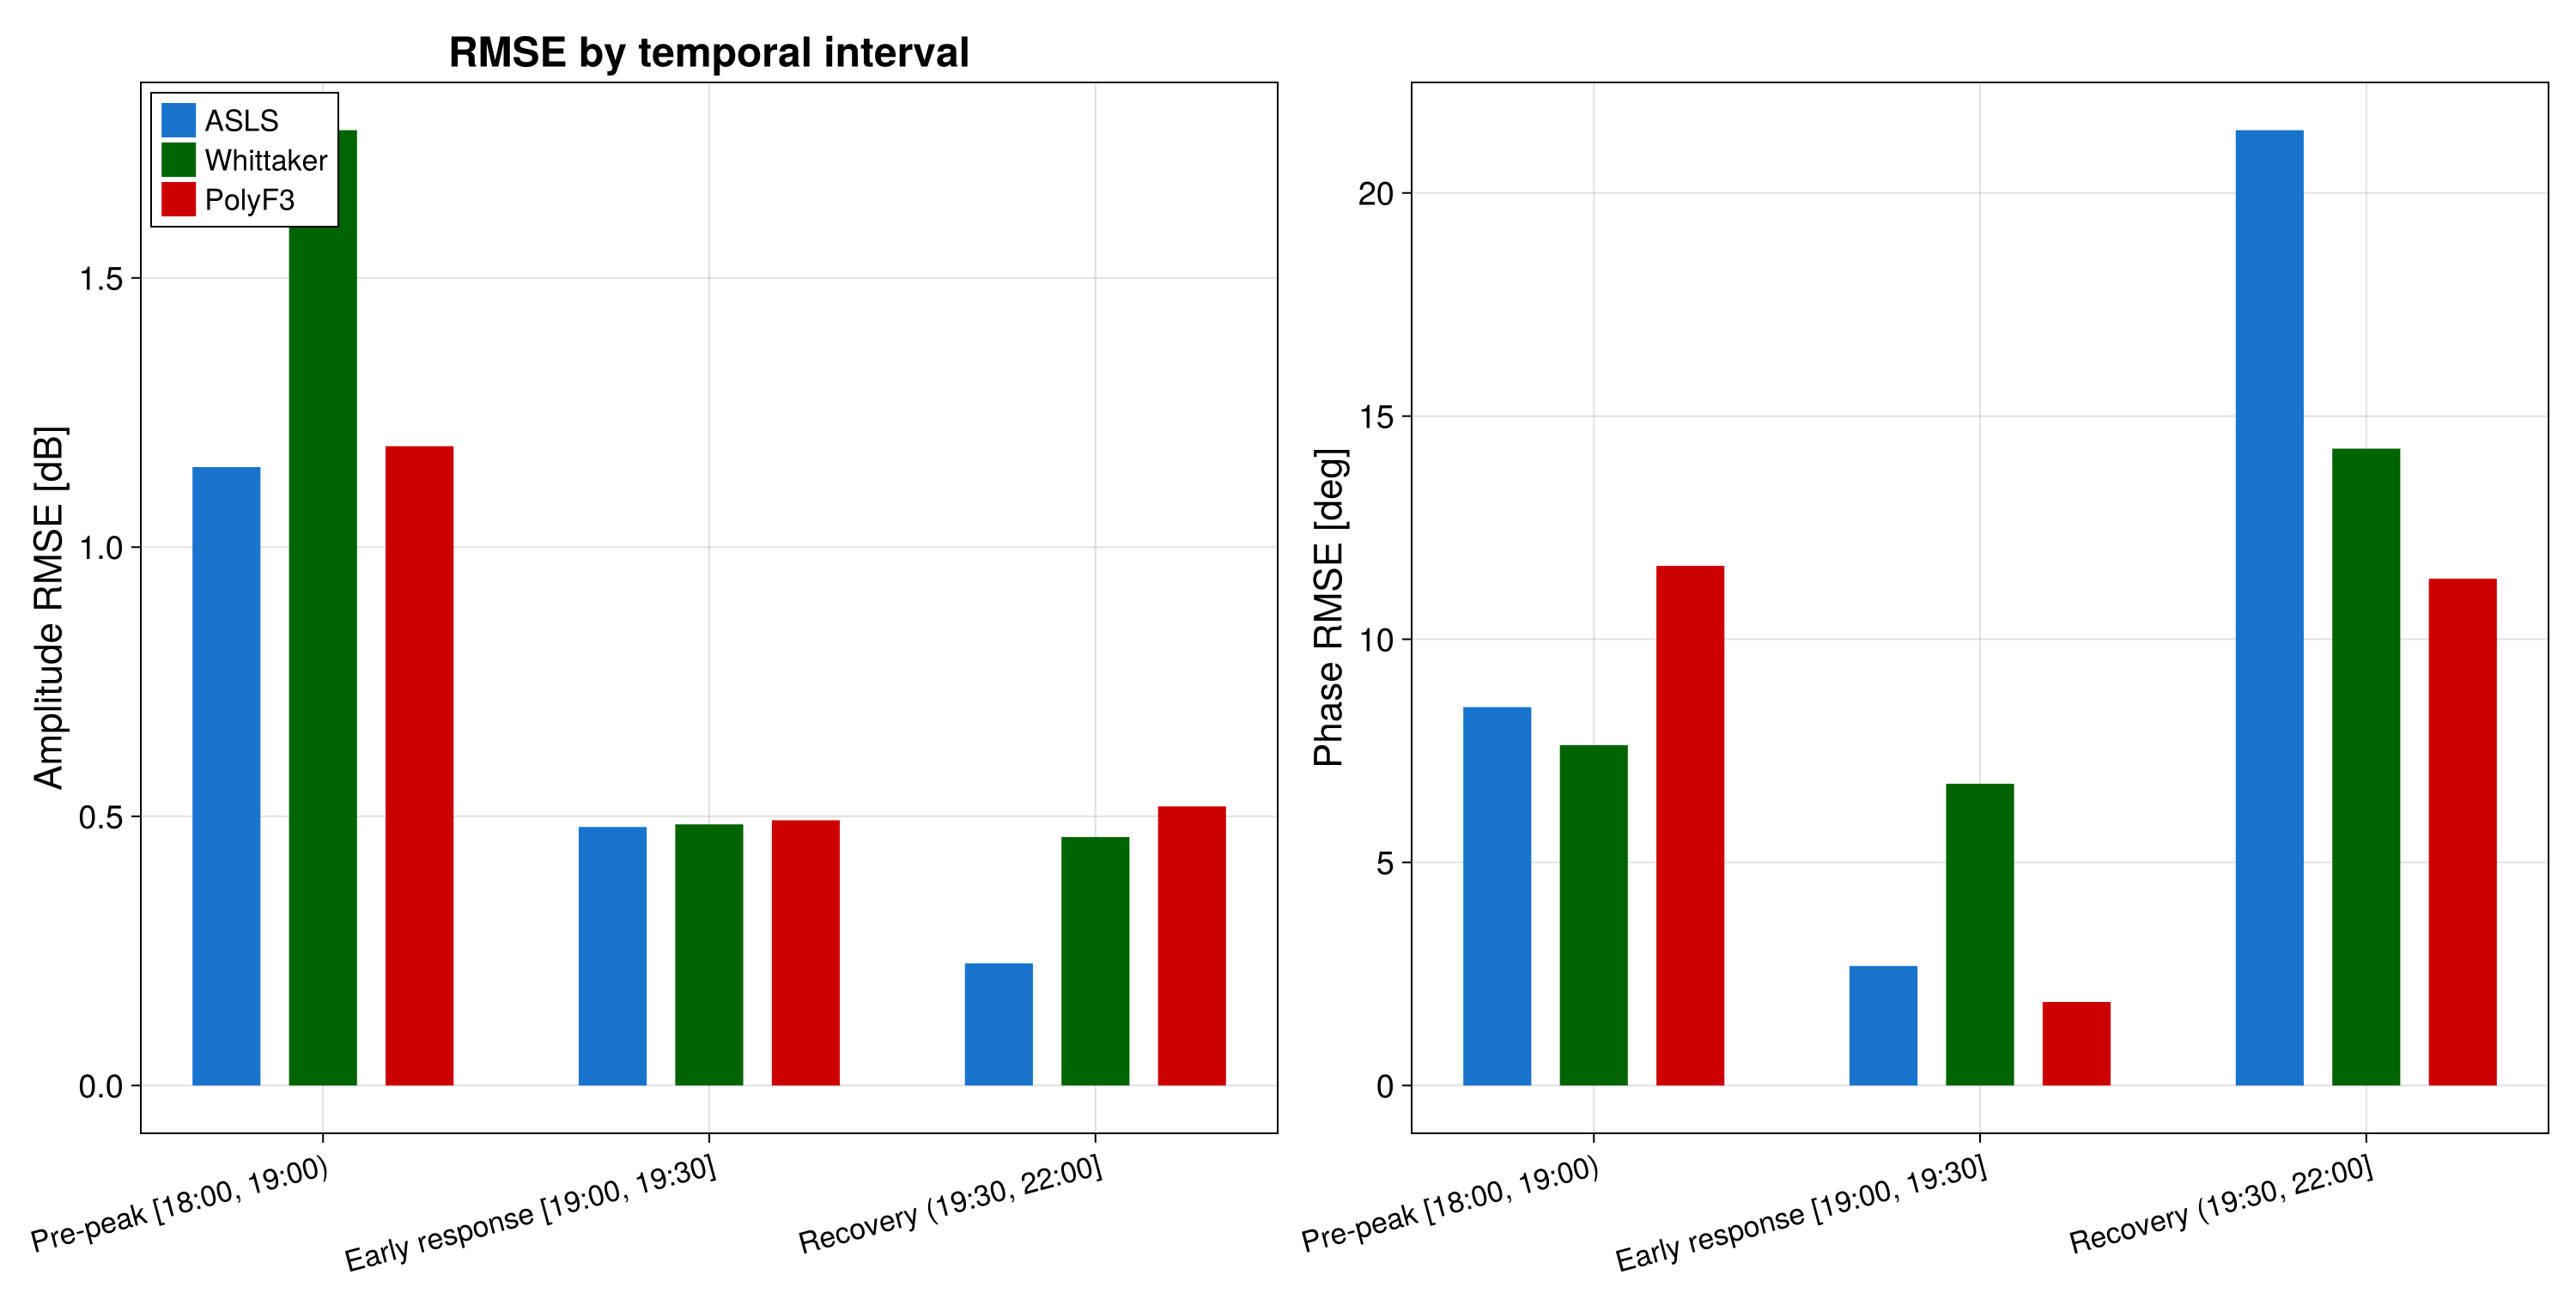

In [17]:

# ============================================================
# 15. Metrics by physically interpretable time interval
# ============================================================
INTERVALS = [
    ("Pre-peak [18:00, 19:00)", time5_hours .< 19.0),
    ("Early response [19:00, 19:30]", (time5_hours .>= 19.0) .& (time5_hours .<= 19.5)),
    ("Recovery (19:30, 22:00]", time5_hours .> 19.5),
]

interval_rows = NamedTuple[]

for method in METHODS
    for (interval, mask) in INTERVALS
        any(mask) || error("Empty interval: $(interval)")

        dA = RESIDUALS5[method].A[mask]
        dphi = RESIDUALS5[method].phi[mask]

        push!(
            interval_rows,
            (
                method = method,
                interval = interval,
                n_points = count(identity, mask),
                RMSE_A_dB = sqrt(mean(dA .^ 2)),
                bias_A_dB = mean(dA),
                maxabs_A_dB = maximum(abs.(dA)),
                RMSE_phi_deg = sqrt(mean(dphi .^ 2)),
                bias_phi_deg = mean(dphi),
                maxabs_phi_deg = maximum(abs.(dphi)),
            ),
        )
    end
end

interval_metrics_df = DataFrame(interval_rows)
CSV.write(joinpath(TABLES_DIR, "metrics_by_time_interval.csv"), interval_metrics_df)
display(interval_metrics_df)

fig05 = CM.Figure(size = (1500, 760))
interval_labels = first.(INTERVALS)
xbase = collect(1:length(INTERVALS))
offsets = Dict("ASLS" => -0.25, "Whittaker" => 0.0, "PolyF3" => 0.25)

axIA = CM.Axis(
    fig05[1, 1],
    title = "RMSE by temporal interval",
    ylabel = "Amplitude RMSE [dB]",
    xticks = (xbase, interval_labels),
    xticklabelrotation = pi / 12,
    xticklabelsize = FS_TICK - 2,
    yticklabelsize = FS_TICK,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
)

axIP = CM.Axis(
    fig05[1, 2],
    ylabel = "Phase RMSE [deg]",
    xticks = (xbase, interval_labels),
    xticklabelrotation = pi / 12,
    xticklabelsize = FS_TICK - 2,
    yticklabelsize = FS_TICK,
    ylabelsize = FS_LABEL,
)

for method in METHODS
    subset = interval_metrics_df[interval_metrics_df.method .== method, :]

    CM.barplot!(
        axIA,
        xbase .+ offsets[method],
        subset.RMSE_A_dB;
        width = 0.22,
        color = METHOD_COLORS[method],
        label = method,
    )

    CM.barplot!(
        axIP,
        xbase .+ offsets[method],
        subset.RMSE_phi_deg;
        width = 0.22,
        color = METHOD_COLORS[method],
        label = method,
    )
end

CM.axislegend(axIA; position = :lt, labelsize = FS_LEGEND)
save_figure(fig05, "fig05_interval_rmse")

register_provenance!(
    "figures/fig05_interval_rmse";
    kind = "figure",
    source_files = [COMMON_5MIN_H5, POLY_5MIN_H5],
    datasets = ["common 5-minute target and final model arrays"],
    description = "Amplitude and phase RMSE before the peak, during the early response, and during recovery.",
)

fig05


## 7. Final perturbation parameters and background-method sensitivity

In [18]:

# ============================================================
# 16. Final BBO-2 parameters
# ============================================================
PARAMETER_COLUMNS = [
    :amp,
    :t_pk_s,
    :tau_u_s,
    :tau_d_s,
    :eps_s,
    :z0_km,
    :hz_km,
]

parameter_rows = NamedTuple[]

for method in METHODS
    p = CHAINS[method].best2_params

    push!(
        parameter_rows,
        (
            method = method,
            amp = p[1],
            t_pk_s = p[2],
            tau_u_s = p[3],
            tau_d_s = p[4],
            eps_s = p[5],
            z0_km = p[6],
            hz_km = p[7],
        ),
    )
end

final_parameters_df = DataFrame(parameter_rows)

sensitivity_rows = NamedTuple[]
for parameter in [:amp, :tau_u_s, :tau_d_s, :eps_s, :z0_km, :hz_km]
    values = Float64.(final_parameters_df[!, parameter])
    mean_value = mean(values)
    absolute_range = maximum(values) - minimum(values)

    push!(
        sensitivity_rows,
        (
            parameter = String(parameter),
            mean = mean_value,
            standard_deviation = std(values),
            minimum = minimum(values),
            maximum = maximum(values),
            absolute_range = absolute_range,
            relative_range_percent = 100.0 * absolute_range / abs(mean_value),
        ),
    )
end

parameter_sensitivity_df = DataFrame(sensitivity_rows)

CSV.write(joinpath(TABLES_DIR, "final_perturbation_parameters.csv"), final_parameters_df)
CSV.write(joinpath(TABLES_DIR, "background_method_parameter_sensitivity.csv"), parameter_sensitivity_df)

write_latex_table(
    final_parameters_df,
    joinpath(TABLES_DIR, "final_perturbation_parameters.tex");
    caption = "Final perturbation parameters recovered with the three background-separation families.",
    label = "tab:final_perturbation_parameters",
    column_labels = [
        "Method", raw"$A_{\mathrm{pk}}$", raw"$t_{\mathrm{pk}}$ [s]",
        raw"$\tau_u$ [s]", raw"$\tau_d$ [s]", raw"$\epsilon$ [s]",
        raw"$z_0$ [km]", raw"$h_z$ [km]",
    ],
    digits = 6,
)

display(final_parameters_df)
display(parameter_sensitivity_df)

register_provenance!(
    "tables/final_perturbation_parameters";
    kind = "table",
    source_files = [
        FILE_PATHS[:ASLS_BBO2],
        FILE_PATHS[:WHIT_BBO2],
        FILE_PATHS[:POLY_BBO2],
    ],
    datasets = ["reconstruction/full_params"],
    description = "Final six free perturbation parameters and fixed peak time for each family.",
)


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/tables/final_perturbation_parameters.tex


Row,method,amp,t_pk_s,tau_u_s,tau_d_s,eps_s,z0_km,hz_km
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,ASLS,20.5159,1800.0,194.417,1293.86,761.786,76.1105,10.7799
2,Whittaker,20.5537,1800.0,192.435,1322.16,818.49,74.2477,9.9598
3,PolyF3,20.4982,1800.0,189.363,1342.7,807.615,77.2944,10.4146


Row,parameter,mean,standard_deviation,minimum,maximum,absolute_range,relative_range_percent
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,amp,20.5226,0.0283503,20.4982,20.5537,0.0555092,0.270479
2,tau_u_s,192.071,2.54653,189.363,194.417,5.05402,2.63133
3,tau_d_s,1319.58,24.5237,1293.86,1342.7,48.8426,3.70139
4,eps_s,795.963,30.0939,761.786,818.49,56.7037,7.12391
5,z0_km,75.8842,1.5359,74.2477,77.2944,3.04668,4.01491
6,hz_km,10.3848,0.410846,9.9598,10.7799,0.820064,7.89681


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig06_final_parameter_comparison.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig06_final_parameter_comparison.png


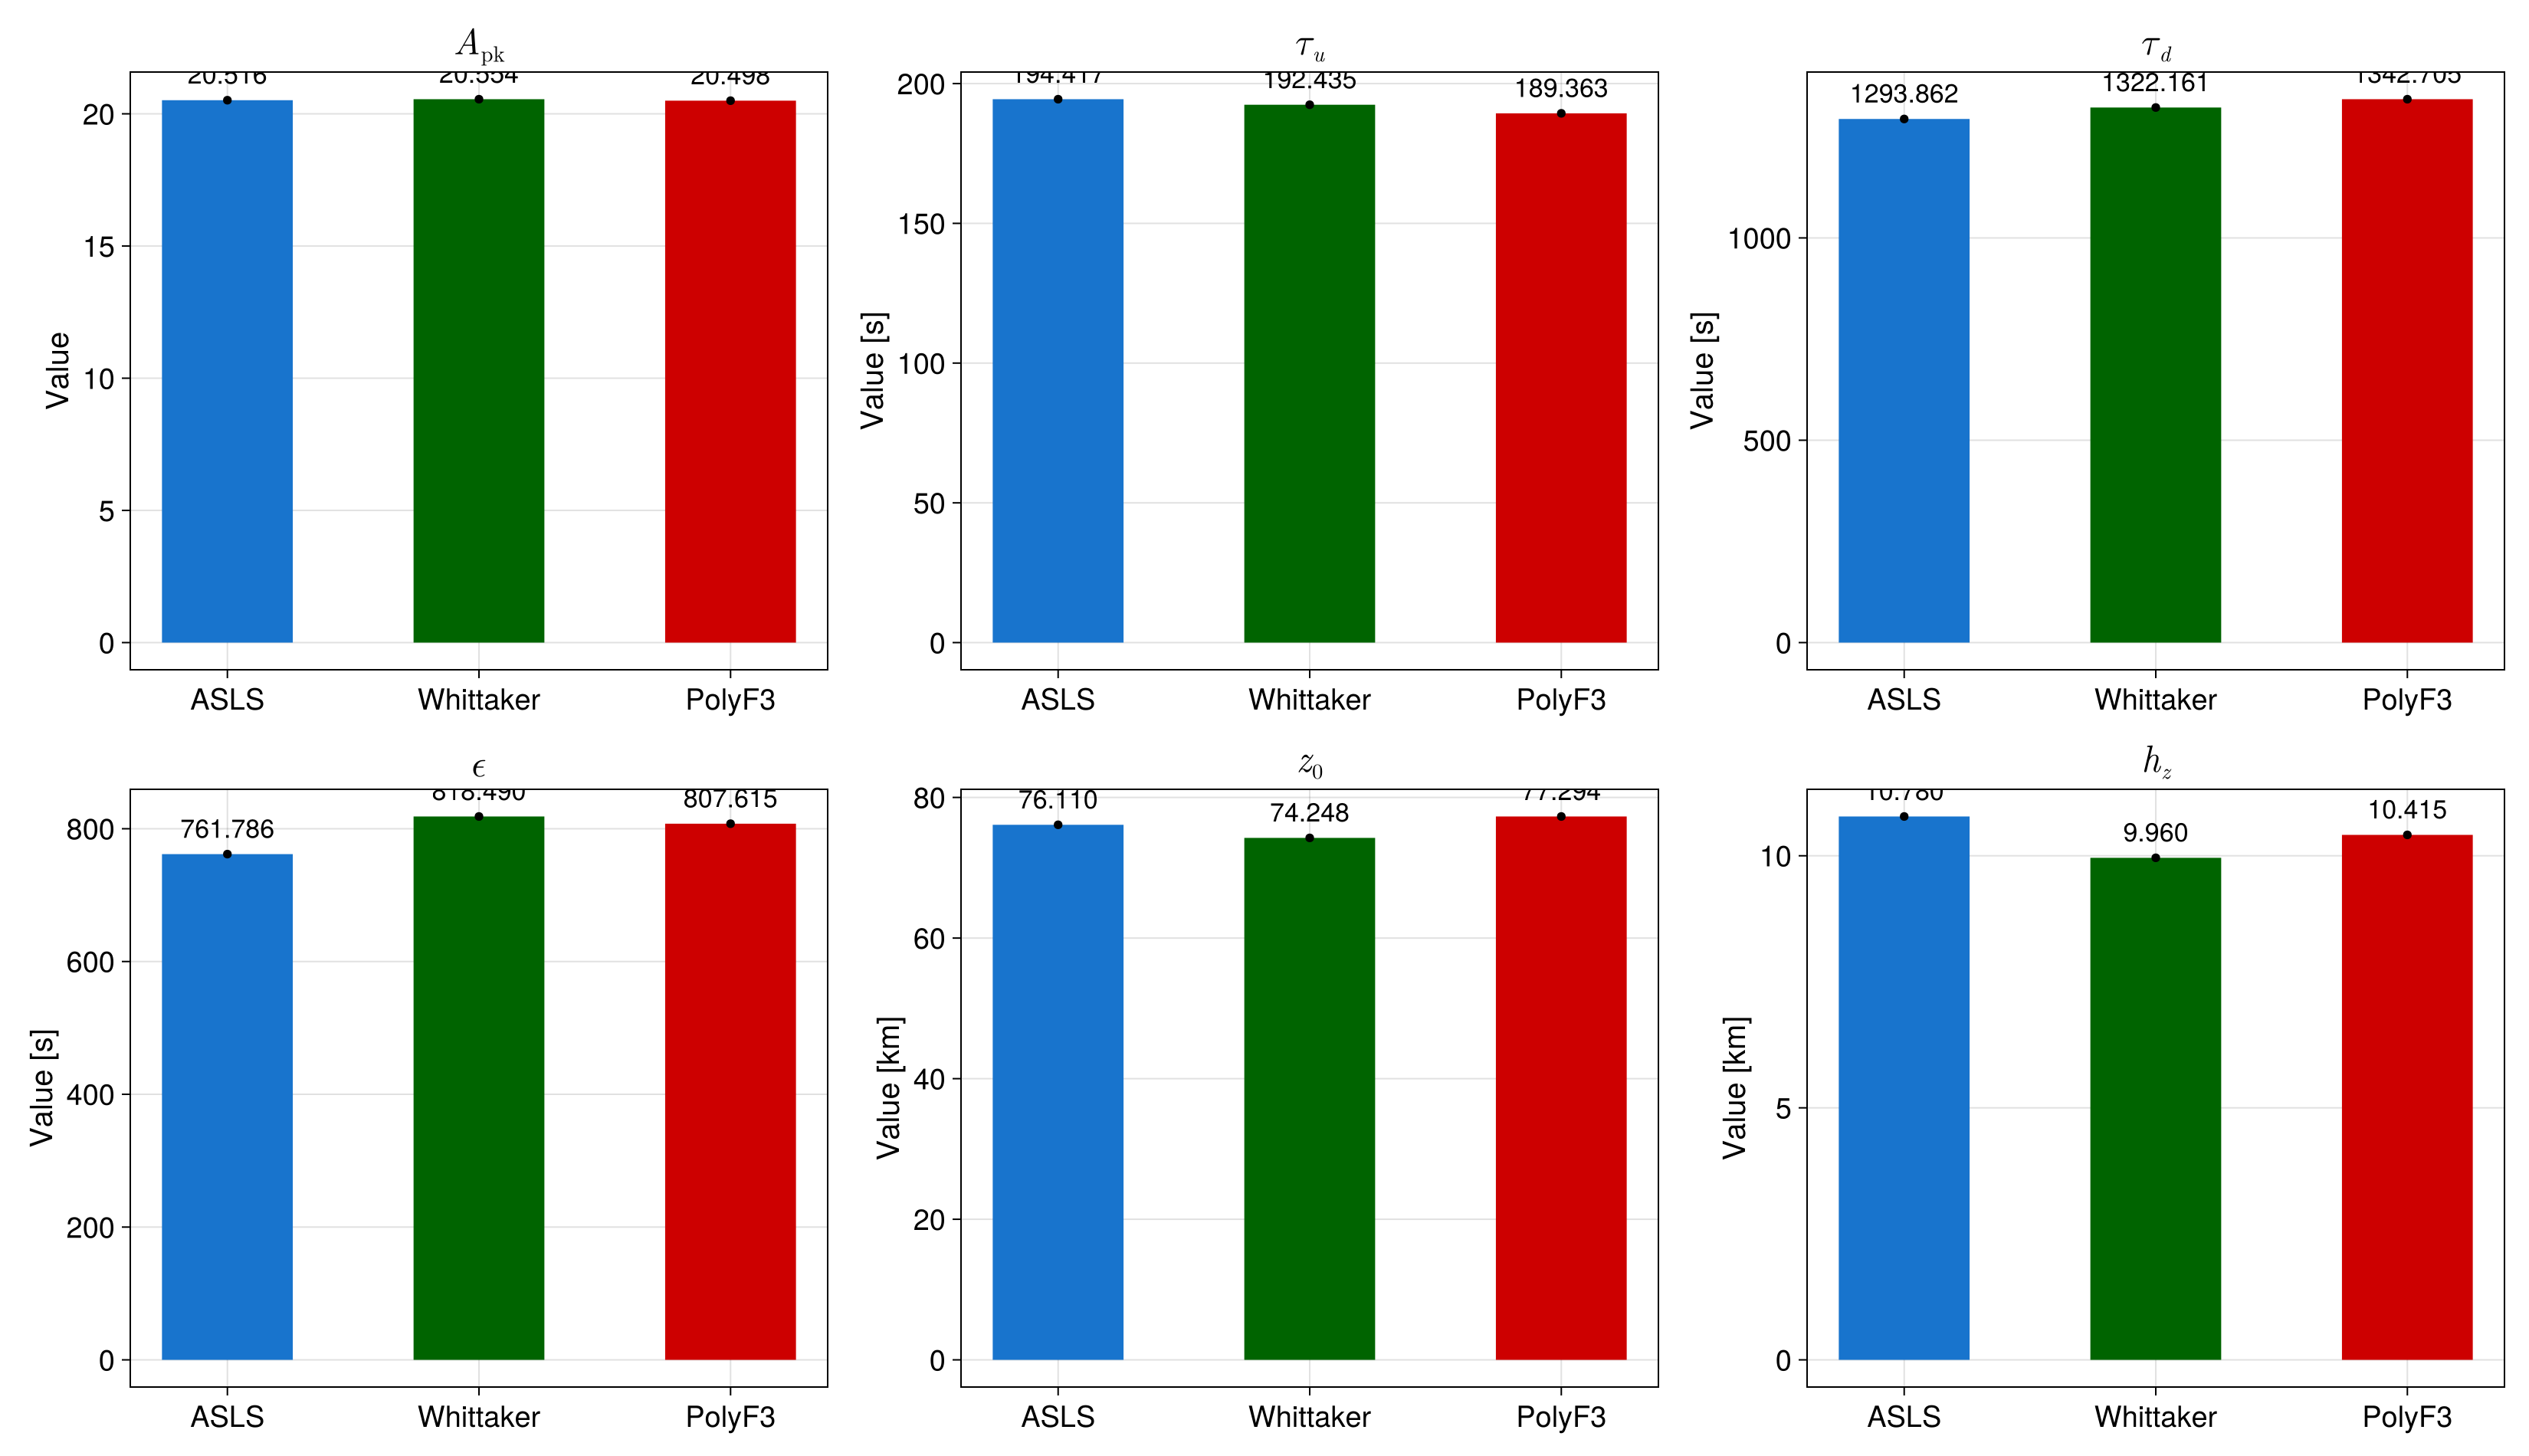

In [19]:

# ============================================================
# 17. Figure 6 — parameter comparison
# ============================================================
parameter_plot_specs = [
    (:amp, L"A_{\mathrm{pk}}", ""),
    (:tau_u_s, L"\tau_u", "s"),
    (:tau_d_s, L"\tau_d", "s"),
    (:eps_s, L"\epsilon", "s"),
    (:z0_km, L"z_0", "km"),
    (:hz_km, L"h_z", "km"),
]

fig06 = CM.Figure(size = (1650, 950))

for (idx, (parameter, title, unit)) in enumerate(parameter_plot_specs)
    row = idx <= 3 ? 1 : 2
    col = idx <= 3 ? idx : idx - 3

    values = Float64.(final_parameters_df[!, parameter])
    ax = CM.Axis(
        fig06[row, col],
        title = title,
        ylabel = isempty(unit) ? "Value" : "Value [" * unit * "]",
        xticks = (1:3, METHODS),
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
        ylabelsize = FS_LABEL - 2,
        titlesize = FS_TITLE,
    )

    CM.barplot!(
        ax,
        1:3,
        values;
        color = [METHOD_COLORS[m] for m in METHODS],
        width = 0.65,
    )
    CM.scatter!(
        ax,
        1:3,
        values;
        color = :black,
        markersize = 8,
    )

    labels = [@sprintf("%.3f", v) for v in values]
    CM.text!(
        ax,
        1:3,
        values;
        text = labels,
        align = (:center, :bottom),
        offset = (0, 7),
        fontsize = FS_TICK - 2,
    )
end

save_figure(fig06, "fig06_final_parameter_comparison")

register_provenance!(
    "figures/fig06_final_parameter_comparison";
    kind = "figure",
    source_files = [
        FILE_PATHS[:ASLS_BBO2],
        FILE_PATHS[:WHIT_BBO2],
        FILE_PATHS[:POLY_BBO2],
    ],
    datasets = ["reconstruction/full_params"],
    description = "Comparison of the six final free perturbation parameters.",
)

fig06


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig07_temporal_perturbation_functions.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig07_temporal_perturbation_functions.png
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig08_vertical_profiles_selected_times.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig08_vertical_profiles_selected_times.png


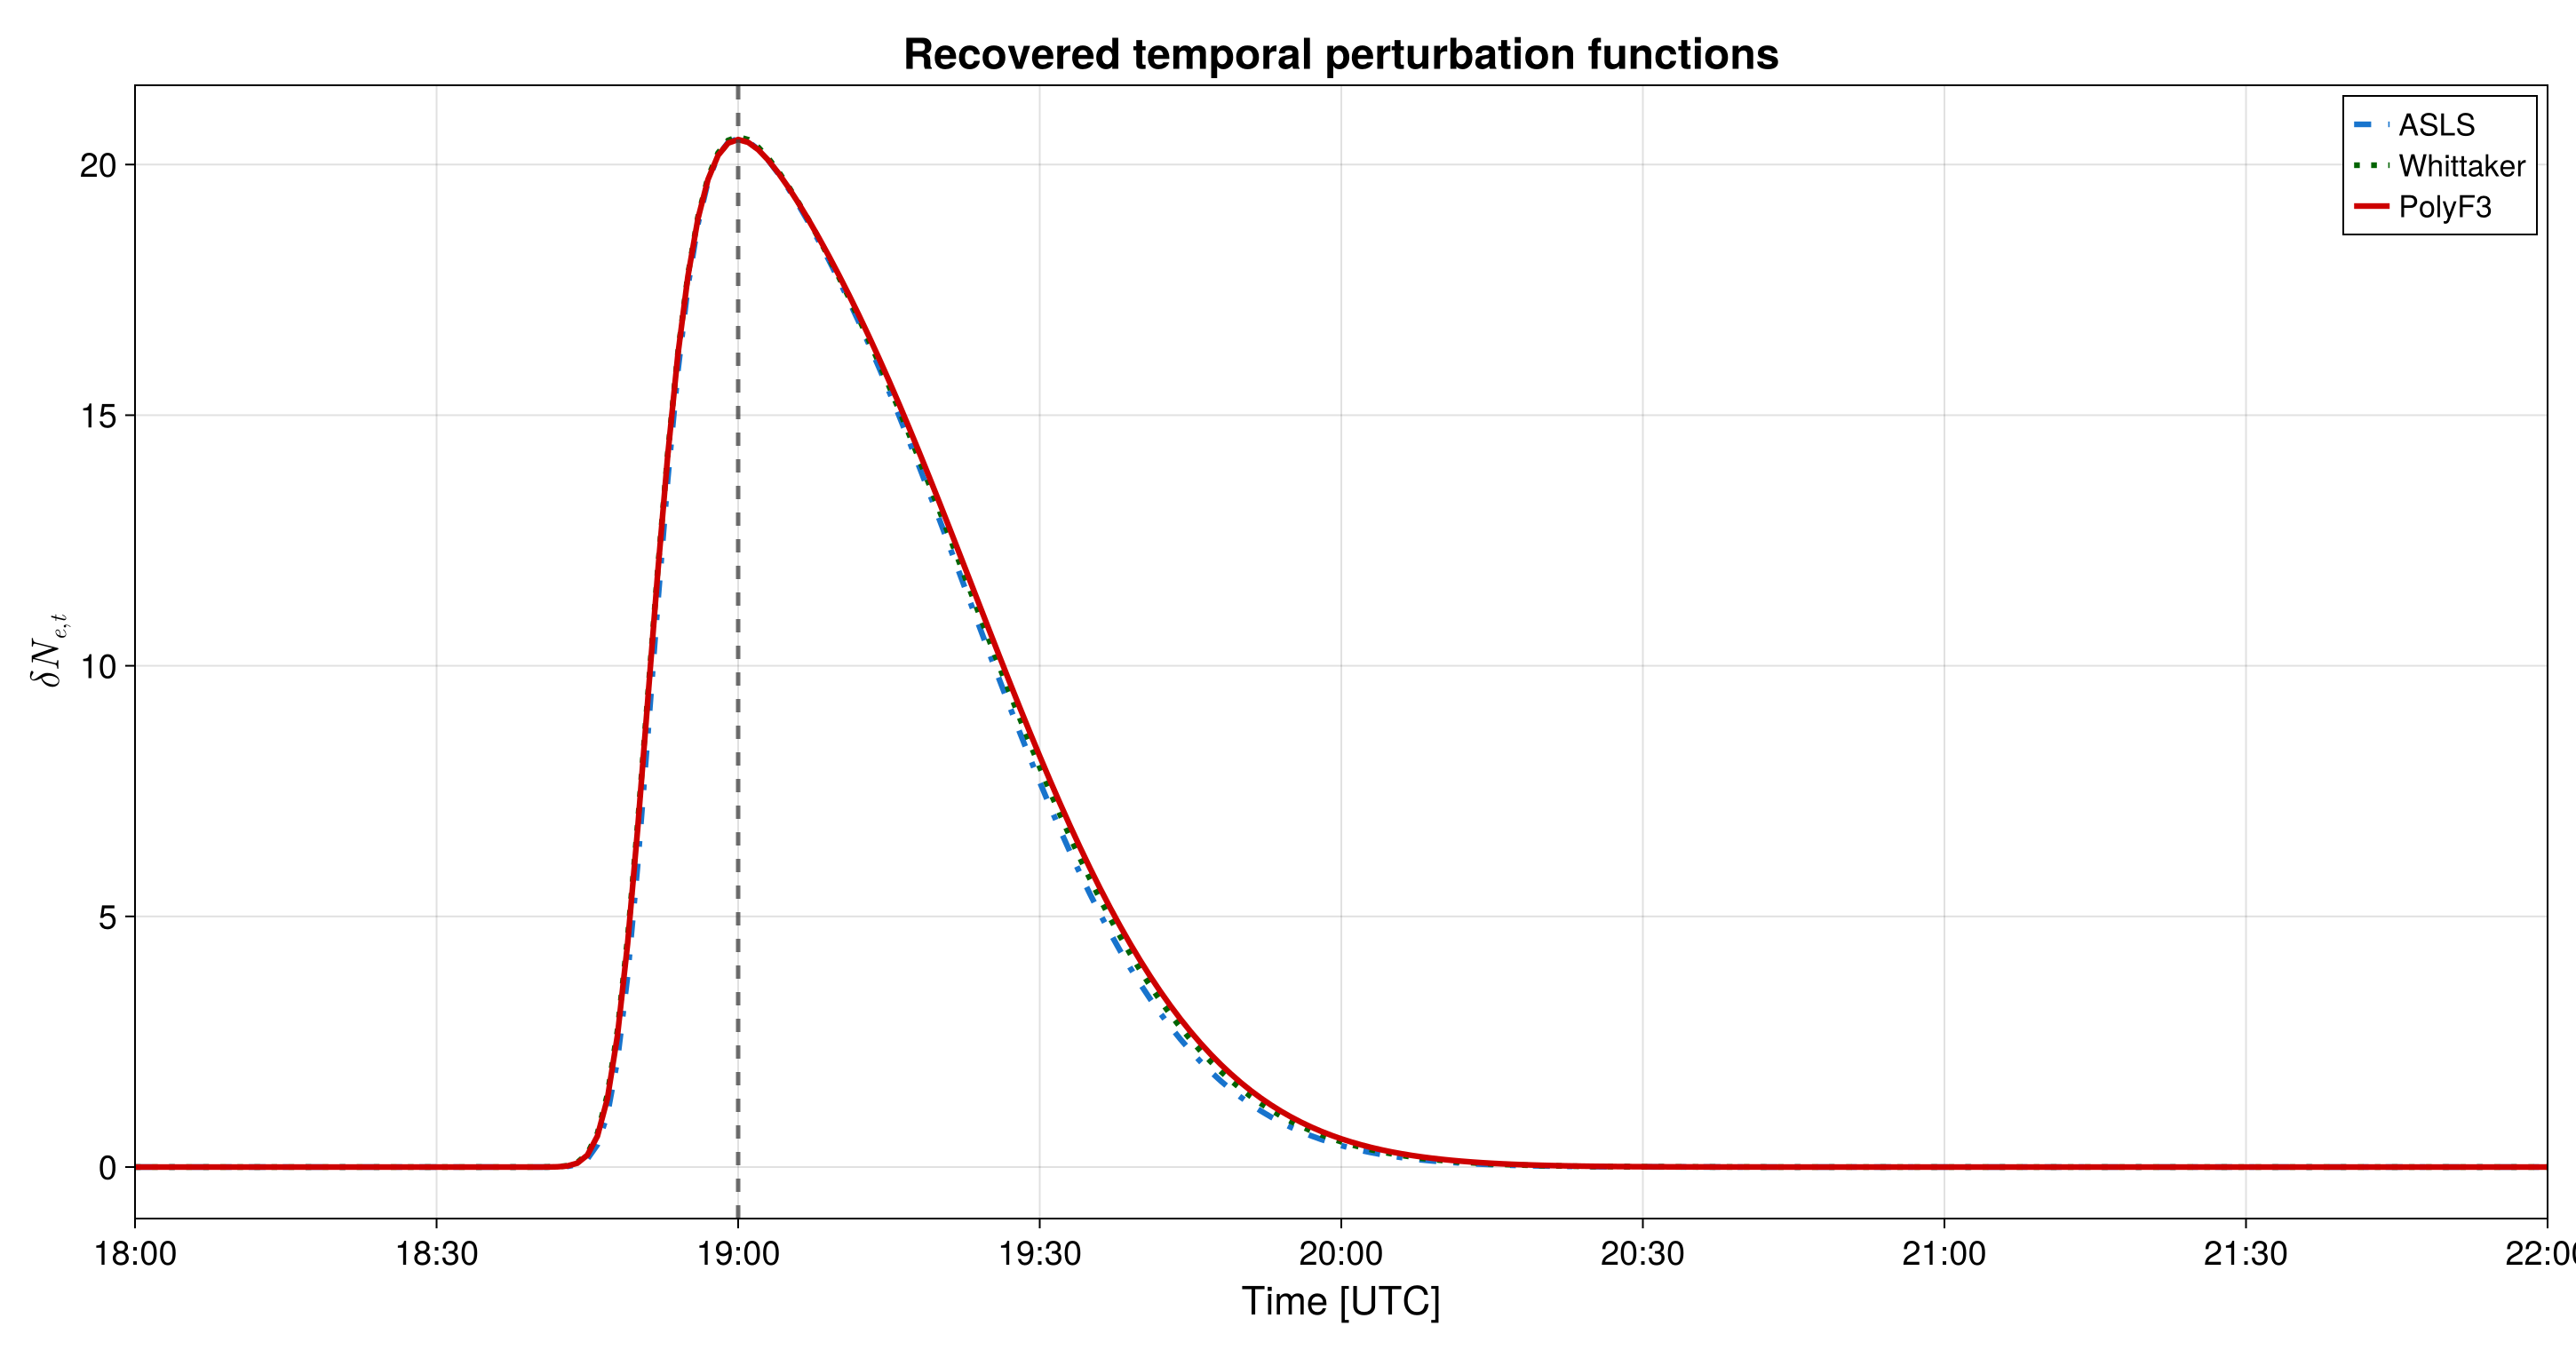

In [20]:

# ============================================================
# 18. Physical perturbation parameterizations
# ============================================================
@inline vertical_perturbation(z_km::Real, z0_km::Real, hz_km::Real) =
    exp(clamp((z_km - z0_km) / hz_km, -50.0, 50.0))

@inline function temporal_perturbation(
    dt_s::Real,
    amp::Real,
    t_pk_s::Real,
    tau_u_s::Real,
    tau_d_s::Real,
    eps_s::Real,
)
    width_s = tau_u_s + 0.5 * (tau_d_s - tau_u_s) *
        (1.0 + tanh((dt_s - t_pk_s) / eps_s))

    return amp * exp(-0.5 * ((dt_s - t_pk_s) / width_s)^2)
end

start_dt = DateTime(2008, 3, 25, 18, 0, 0)
stop_dt = DateTime(2008, 3, 25, 22, 0, 0)
physical_time_dt = collect(start_dt:Minute(1):stop_dt)
physical_time_unix = Dates.datetime2unix.(physical_time_dt)
physical_time_hours, _ = time_hours_utc(physical_time_unix)

# In the inversion, t_pk = 1800 s is relative to 18:30 UTC.
time_origin = DateTime(2008, 3, 25, 18, 30, 0)
time_origin_unix = Dates.datetime2unix(time_origin)
dt_seconds = physical_time_unix .- time_origin_unix

z_profile_km = collect(60.0:0.10:80.0)

TEMPORAL_PROFILES = Dict{String,Vector{Float64}}()
VERTICAL_PROFILES = Dict{String,Vector{Float64}}()

for method in METHODS
    p = CHAINS[method].best2_params

    TEMPORAL_PROFILES[method] = temporal_perturbation.(
        dt_seconds,
        p[1],
        p[2],
        p[3],
        p[4],
        p[5],
    )

    VERTICAL_PROFILES[method] = vertical_perturbation.(
        z_profile_km,
        p[6],
        p[7],
    )
end

fig07 = CM.Figure(size = (1450, 760))
axT = CM.Axis(
    fig07[1, 1],
    title = "Recovered temporal perturbation functions",
    xlabel = "Time [UTC]",
    ylabel = L"\delta N_{e,t}",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, nothing, nothing),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
)

for method in METHODS
    CM.lines!(
        axT,
        physical_time_hours,
        TEMPORAL_PROFILES[method];
        color = METHOD_COLORS[method],
        linestyle = METHOD_LINESTYLES[method],
        linewidth = LW,
        label = method,
    )
end

CM.vlines!(axT, [19.0]; color = (:gray25, 0.75), linestyle = :dash, linewidth = 2.5)
CM.axislegend(axT; position = :rt, labelsize = FS_LEGEND)
save_figure(fig07, "fig07_temporal_perturbation_functions")

selected_times = [
    ("18:30 UTC", 18.5),
    ("19:00 UTC", 19.0),
    ("20:00 UTC", 20.0),
    ("21:30 UTC", 21.5),
]

fig08 = CM.Figure(size = (1500, 1050))

for (idx, (label, hour)) in enumerate(selected_times)
    row = idx <= 2 ? 1 : 2
    col = idx % 2 == 1 ? 1 : 2

    ax = CM.Axis(
        fig08[row, col],
        title = label,
        xlabel = L"\delta N_e/N_{e,\mathrm{bg}}",
        ylabel = "Altitude [km]",
        limits = (nothing, (60.0, 80.0)),
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
    )

    time_index = argmin(abs.(physical_time_hours .- hour))

    for method in METHODS
        profile = VERTICAL_PROFILES[method] .* TEMPORAL_PROFILES[method][time_index]

        CM.lines!(
            ax,
            profile,
            z_profile_km;
            color = METHOD_COLORS[method],
            linestyle = METHOD_LINESTYLES[method],
            linewidth = LW,
            label = method,
        )
    end

    idx == 1 && CM.axislegend(ax; position = :lt, labelsize = FS_LEGEND)
end

save_figure(fig08, "fig08_vertical_profiles_selected_times")

register_provenance!(
    "figures/fig07_temporal_perturbation_functions";
    kind = "figure",
    source_files = [
        FILE_PATHS[:ASLS_BBO2],
        FILE_PATHS[:WHIT_BBO2],
        FILE_PATHS[:POLY_BBO2],
    ],
    datasets = ["reconstruction/full_params"],
    description = "Temporal F3 perturbation functions evaluated from the final parameters.",
)

register_provenance!(
    "figures/fig08_vertical_profiles_selected_times";
    kind = "figure",
    source_files = [
        FILE_PATHS[:ASLS_BBO2],
        FILE_PATHS[:WHIT_BBO2],
        FILE_PATHS[:POLY_BBO2],
    ],
    datasets = ["reconstruction/full_params"],
    description = "Relative vertical electron-density perturbation at four representative times.",
)

fig07



## 8. Physical backgrounds and electron-density fields

This block uses the canonical reconstructed \(h'(\chi)\) and \(\beta(\chi)\) backgrounds and the final BBO-2 perturbation parameters. Variables inherited from older files with names such as `true_h` are not interpreted as truth; the notebook reads the explicit background reconstruction datasets.


In [21]:

# ============================================================
# 19. Project physical functions and background coefficients
# ============================================================
PROJECT_ROOT_LOCAL = PROJECT_ROOT
preamble_path = joinpath(PROJECT_ROOT_LOCAL, "mytools", "preamble.jl")

if RUN_PHYSICAL_FIELDS
    if (!isdefined(Main, :waitprofile) || !isdefined(Main, :geolinspace)) && isfile(preamble_path)
        include(preamble_path)
    end

    @assert isdefined(Main, :waitprofile) (
        "No encuentro `waitprofile`. Revisa PROJECT_ROOT o mytools/preamble.jl."
    )
    @assert isdefined(Main, :geolinspace) (
        "No encuentro `geolinspace`. Revisa PROJECT_ROOT o mytools/preamble.jl."
    )
end

function load_background_parameters(path::AbstractString, label::AbstractString)
    h = readvec(path, "reconstruction/h_coeffs")
    beta = readvec(path, "reconstruction/beta_coeffs")

    length(h) == 9 || error("$(label): expected nine h′ coefficients.")
    length(beta) == 6 || error("$(label): expected six β coefficients.")
    all(isfinite, vcat(h, beta)) || error("$(label): non-finite background coefficients.")

    return (
        label = label,
        path = path,
        h_coeffs = h,
        beta_coeffs = beta,
    )
end

BACKGROUNDS = Dict(
    "ASLS" => load_background_parameters(FILE_PATHS[:ASLS_BG], "ASLS"),
    "Whittaker" => load_background_parameters(FILE_PATHS[:WHIT_BG], "Whittaker"),
    "PolyF3" => load_background_parameters(FILE_PATHS[:POLY_BG], "PolyF3"),
)

function chi_signed_astrolib(
    lat_deg::Real,
    lon_deg::Real,
    zdt::ZonedDateTime;
    height_m::Real = 0.0,
    units::Symbol = :deg,
)
    zdt_utc = astimezone(zdt, tz"UTC")
    jd = AstroLib.jdcnv(DateTime(zdt_utc))
    ra, dec = AstroLib.sunpos(jd)
    alt_deg, az_deg, _ha_deg = AstroLib.eq2hor(
        ra,
        dec,
        jd,
        lat_deg,
        lon_deg,
        height_m,
    )

    sza_deg = 90.0 - alt_deg
    chi_deg = (0.0 <= az_deg < 180.0) ? -sza_deg : +sza_deg

    return units === :rad ? deg2rad(chi_deg) : chi_deg
end

@inline function total_electron_density(
    z_m::Real,
    hprime_km::Real,
    beta_km_inv::Real,
    dt_s::Real,
    params::AbstractVector,
)
    ne_bg = waitprofile(z_m, hprime_km, beta_km_inv)
    vertical = vertical_perturbation(z_m / 1e3, params[6], params[7])
    temporal = temporal_perturbation(
        dt_s,
        params[1],
        params[2],
        params[3],
        params[4],
        params[5],
    )

    return ne_bg * (1.0 + vertical * temporal)
end


[ Info: Loading CHAOS-7.11.mat


total_electron_density (generic function with 1 method)

In [22]:

# ============================================================
# 20. Evaluate h′(χ), β(χ), Ne(z,t), and physical reflection heights
# ============================================================
if RUN_PHYSICAL_FIELDS
    physical_time_zdt = ZonedDateTime.(physical_time_dt, tz"UTC")

    lats_path, lons_path, _dists_path = geolinspace("NAA", "PLO", 19, false)
    lat_rx = last(lats_path)
    lon_rx = last(lons_path)

    chi_rx_deg = chi_signed_astrolib.(lat_rx, lon_rx, physical_time_zdt)
    chi_grid_deg = collect(range(minimum(chi_rx_deg), maximum(chi_rx_deg); length = 400))
    chi_grid_rad = deg2rad.(chi_grid_deg)

    H_POLYNOMIALS = Dict(
        method => Polynomial(BACKGROUNDS[method].h_coeffs)
        for method in METHODS
    )
    BETA_POLYNOMIALS = Dict(
        method => Polynomial(BACKGROUNDS[method].beta_coeffs)
        for method in METHODS
    )

    H_CHI = Dict(method => H_POLYNOMIALS[method].(chi_grid_rad) for method in METHODS)
    BETA_CHI = Dict(method => BETA_POLYNOMIALS[method].(chi_grid_rad) for method in METHODS)

    z_field_km = collect(60.0:0.10:80.0)
    z_field_m = z_field_km .* 1e3

    NE_FIELDS = Dict{String,Matrix{Float64}}()
    HPRIME_TIME = Dict{String,Vector{Float64}}()
    BETA_TIME = Dict{String,Vector{Float64}}()

    for method in METHODS
        params = CHAINS[method].best2_params
        Nt = length(physical_time_dt)
        Nz = length(z_field_km)

        Ne = Matrix{Float64}(undef, Nt, Nz)
        h_time = Vector{Float64}(undef, Nt)
        beta_time = Vector{Float64}(undef, Nt)

        for k in 1:Nt
            chi_rad = deg2rad(chi_rx_deg[k])
            h_time[k] = H_POLYNOMIALS[method](chi_rad)
            beta_time[k] = BETA_POLYNOMIALS[method](chi_rad)

            for j in 1:Nz
                Ne[k, j] = total_electron_density(
                    z_field_m[j],
                    h_time[k],
                    beta_time[k],
                    dt_seconds[k],
                    params,
                )
            end
        end

        all(isfinite, Ne) || error("$(method): non-finite electron density.")
        minimum(Ne) > 0 || error("$(method): non-positive electron density.")

        NE_FIELDS[method] = Ne
        HPRIME_TIME[method] = h_time
        BETA_TIME[method] = beta_time
    end

    println("PLO coordinates: lat=$(lat_rx)°, lon=$(lon_rx)°")
    println(
        "Solar-zenith-angle domain: ",
        round(minimum(chi_rx_deg), digits = 3),
        "° to ",
        round(maximum(chi_rx_deg), digits = 3),
        "°",
    )
end


PLO coordinates: lat=-12.499999999322473°, lon=-76.79999999990258°
Solar-zenith-angle domain: 18.713° to 72.592°


In [23]:

# ============================================================
# 21. Physical reflection-height condition
# ============================================================
function reflectionheight_v2_rx(
    ne_prof::AbstractVector{<:Real},
    alt_m::AbstractVector{<:Real},
    tx_freq,
    bfield;
    tol::Real = 1e-2,
    maxiter::Int = 80,
)::Float64
    length(ne_prof) == length(alt_m) ||
        error("ne_prof and alt_m must have the same length.")

    alt = Float64.(alt_m)
    ne = Float64.(ne_prof)

    all(isfinite, alt) || return NaN
    all(isfinite, ne) || return NaN
    minimum(ne) > 0.0 || return NaN
    issorted(alt) || error("alt_m must be sorted.")

    ne_itp = Interpolations.extrapolate(
        Interpolations.interpolate(
            (alt,),
            ne,
            Interpolations.Gridded(Interpolations.Linear()),
        ),
        Interpolations.Line(),
    )

    species = Species(QE, ME, ne_itp, electroncollisionfrequency)
    omega_required = tx_freq.ω

    f(h) = waitsparameter(h, tx_freq, bfield, species) - omega_required

    a = alt[1] + 100.0
    b = alt[end] - 100.0
    a < b || error("The altitude domain must span more than 200 m.")

    fa = f(a)
    fb = f(b)

    if !isfinite(fa) || !isfinite(fb) || signbit(fa) == signbit(fb)
        probe = collect(range(a, b; length = 401))
        fprobe = f.(probe)

        bracket_idx = findfirst(
            i ->
                isfinite(fprobe[i]) &&
                isfinite(fprobe[i + 1]) &&
                signbit(fprobe[i]) != signbit(fprobe[i + 1]),
            1:(length(probe) - 1),
        )

        bracket_idx === nothing && return NaN

        a = probe[bracket_idx]
        b = probe[bracket_idx + 1]
        fa = fprobe[bracket_idx]
        fb = fprobe[bracket_idx + 1]
    end

    c = 0.5 * (a + b)

    for _ in 1:maxiter
        c = 0.5 * (a + b)
        fc = f(c)

        isfinite(fc) || return NaN

        if abs(fc) <= tol || abs(b - a) <= tol
            return c / 1e3
        end

        if signbit(fa) == signbit(fc)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end

    return c / 1e3
end

if RUN_PHYSICAL_FIELDS
    tx_frequency_rx = if isdefined(Main, :tx2) &&
                         hasproperty(getfield(Main, :tx2), :frequency)
        getproperty(getfield(Main, :tx2), :frequency)
    else
        Frequency(24.0e3)
    end

    bfield_rx = if isdefined(Main, :bfield) &&
                   getfield(Main, :bfield) isa BField
        getfield(Main, :bfield)
    else
        BField(50e-6, pi / 2, 0.0)
    end

    REFLECTION_HEIGHTS = Dict{String,Vector{Float64}}()
    LOGNE_MASKED = Dict{String,Matrix{Float64}}()

    for method in METHODS
        Ne = NE_FIELDS[method]

        heights = [
            reflectionheight_v2_rx(
                view(Ne, k, :),
                z_field_m,
                tx_frequency_rx,
                bfield_rx,
            )
            for k in axes(Ne, 1)
        ]

        failed = findall(x -> !isfinite(x), heights)
        isempty(failed) || error(
            "$(method): reflection height failed at $(length(failed)) times: $(failed)",
        )

        logNe = log10.(Ne)
        masked = copy(logNe)

        for k in axes(masked, 1)
            for j in axes(masked, 2)
                if z_field_km[j] > heights[k]
                    masked[k, j] = NaN
                end
            end
        end

        REFLECTION_HEIGHTS[method] = heights
        LOGNE_MASKED[method] = masked

        println(
            method,
            " reflection-height range: ",
            round(minimum(heights), digits = 3),
            "–",
            round(maximum(heights), digits = 3),
            " km",
        )
    end

    common_finite_logNe = vcat([
        filter(isfinite, vec(LOGNE_MASKED[method]))
        for method in METHODS
    ]...)
    COMMON_LOGNE_COLORRANGE = extrema(common_finite_logNe)
end


ASLS reflection-height range: 64.816–74.364 km
Whittaker reflection-height range: 64.717–73.93 km
PolyF3 reflection-height range: 64.874–73.59 km


(6.994328880869242, 8.716604167190122)

Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig09_whittaker_representative_heatmap.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig09_whittaker_representative_heatmap.png


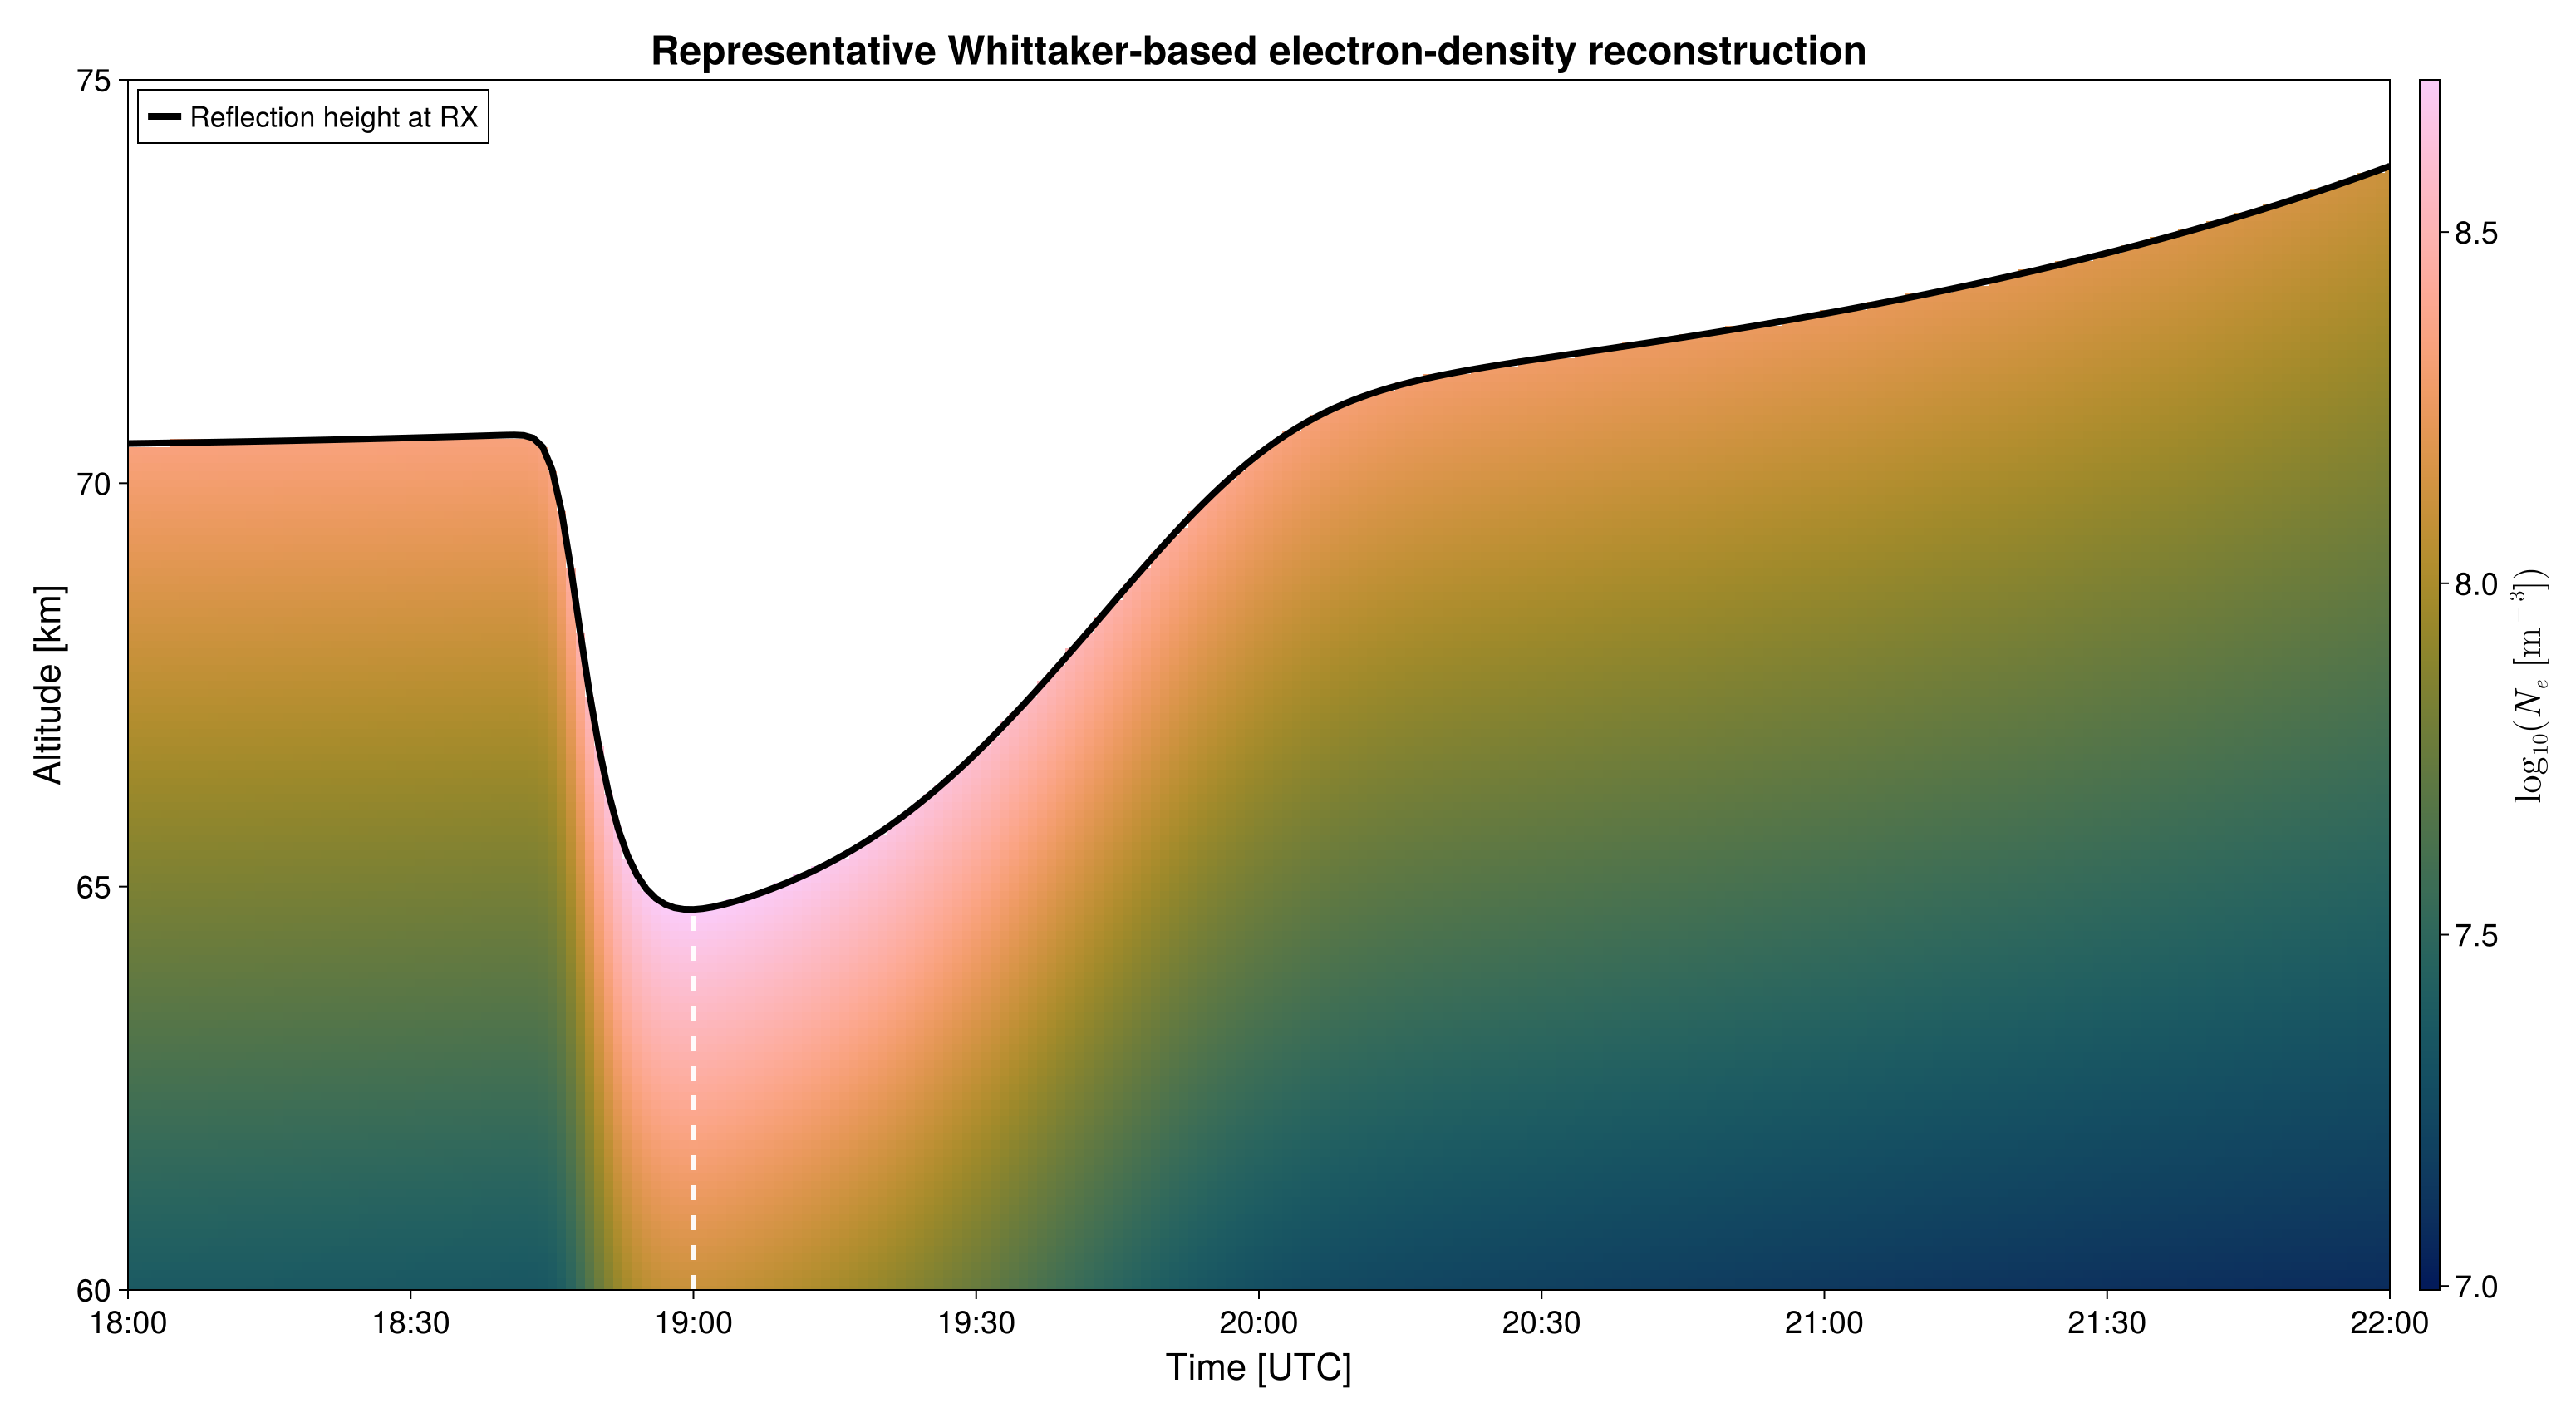

In [24]:

# ============================================================
# 22. Figure 9 — representative Whittaker field
# ============================================================
if RUN_PHYSICAL_FIELDS
    fig09 = CM.Figure(size = (1550, 850))

    axMap = CM.Axis(
        fig09[1, 1],
        title = "Representative Whittaker-based electron-density reconstruction",
        xlabel = "Time [UTC]",
        ylabel = "Altitude [km]",
        xticks = (xticks_hours, xtick_labels),
        limits = (18.0, 22.0, 60.0, 75.0),
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
        xgridvisible = false,
        ygridvisible = false,
    )

    hm09 = CM.heatmap!(
        axMap,
        physical_time_hours,
        z_field_km,
        LOGNE_MASKED["Whittaker"];
        colormap = :batlow,
        colorrange = COMMON_LOGNE_COLORRANGE,
        nan_color = :white,
    )

    CM.vlines!(
        axMap,
        [19.0];
        color = (:white, 0.95),
        linestyle = :dash,
        linewidth = 3,
    )

    CM.lines!(
        axMap,
        physical_time_hours,
        REFLECTION_HEIGHTS["Whittaker"];
        color = :black,
        linewidth = 4,
        label = "Reflection height at RX",
    )

    CM.axislegend(
        axMap;
        position = :lt,
        labelsize = FS_LEGEND,
        framevisible = true,
        backgroundcolor = (:white, 0.90),
    )

    CM.Colorbar(
        fig09[1, 2],
        hm09;
        label = L"\log_{10}(N_e\ [\mathrm{m}^{-3}])",
        labelsize = FS_LABEL,
        ticklabelsize = FS_TICK,
    )

    save_figure(fig09, "fig09_whittaker_representative_heatmap")

    register_provenance!(
        "figures/fig09_whittaker_representative_heatmap";
        kind = "figure",
        source_files = [FILE_PATHS[:WHIT_BG], FILE_PATHS[:WHIT_BBO2]],
        datasets = [
            "reconstruction/h_coeffs",
            "reconstruction/beta_coeffs",
            "reconstruction/full_params",
        ],
        description = "Whittaker electron-density field at Punta Lobos, masked above the calculated physical reflection height.",
    )

    fig09
end


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/diagnostics/heatmaps_3families_same_scale.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/diagnostics/heatmaps_3families_same_scale.png


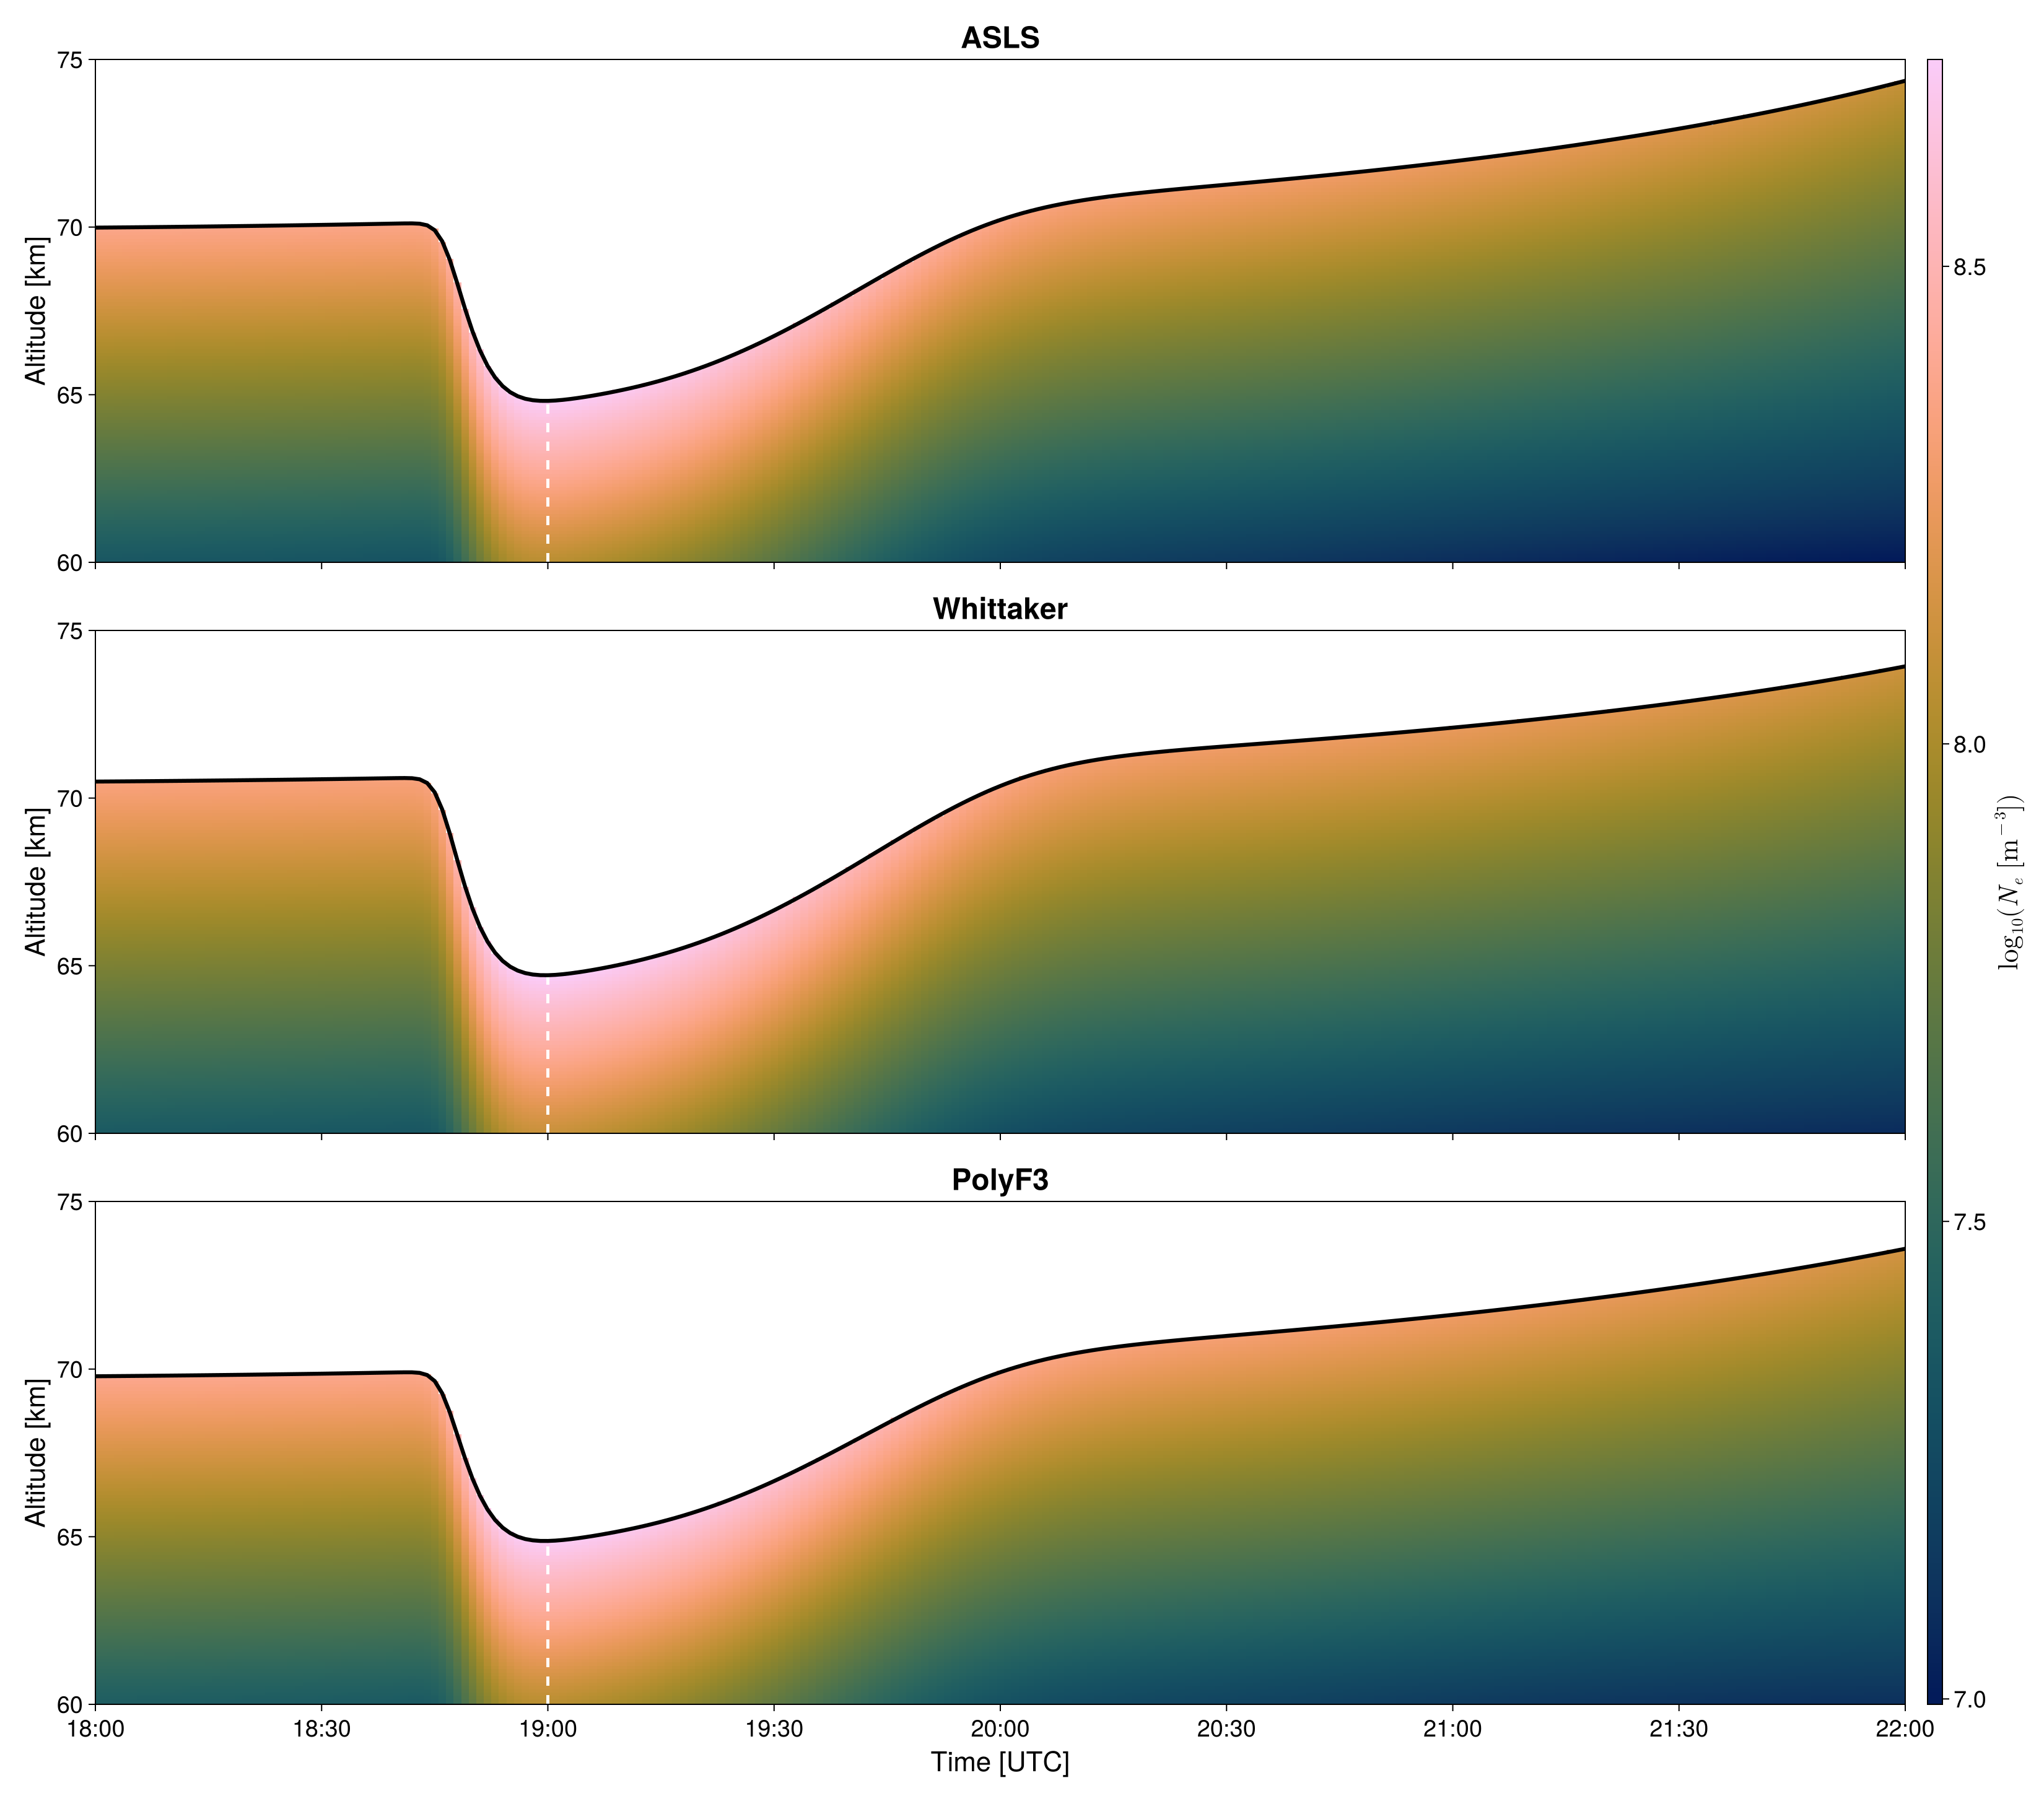

In [25]:

# ============================================================
# 23. Diagnostic three-family heatmaps with one common color scale
# ============================================================
if RUN_PHYSICAL_FIELDS && RUN_ALL_FAMILY_HEATMAPS
    fig_heatmaps = CM.Figure(size = (1650, 1450))

    for (row, method) in enumerate(METHODS)
        ax = CM.Axis(
            fig_heatmaps[row, 1],
            title = method,
            xlabel = row == length(METHODS) ? "Time [UTC]" : "",
            ylabel = "Altitude [km]",
            xticks = (xticks_hours, xtick_labels),
            limits = (18.0, 22.0, 60.0, 75.0),
            xticklabelsvisible = row == length(METHODS),
            xlabelsize = FS_LABEL,
            ylabelsize = FS_LABEL,
            titlesize = FS_TITLE,
            xticklabelsize = FS_TICK,
            yticklabelsize = FS_TICK,
            xgridvisible = false,
            ygridvisible = false,
        )

        hm = CM.heatmap!(
            ax,
            physical_time_hours,
            z_field_km,
            LOGNE_MASKED[method];
            colormap = :batlow,
            colorrange = COMMON_LOGNE_COLORRANGE,
            nan_color = :white,
        )

        CM.vlines!(
            ax,
            [19.0];
            color = (:white, 0.95),
            linestyle = :dash,
            linewidth = 2.5,
        )

        CM.lines!(
            ax,
            physical_time_hours,
            REFLECTION_HEIGHTS[method];
            color = :black,
            linewidth = 3.2,
        )

        if row == 1
            CM.Colorbar(
                fig_heatmaps[1:3, 2],
                hm;
                label = L"\log_{10}(N_e\ [\mathrm{m}^{-3}])",
                labelsize = FS_LABEL,
                ticklabelsize = FS_TICK,
            )
        end
    end

    save_figure(
        fig_heatmaps,
        "heatmaps_3families_same_scale";
        directory = DIAGNOSTICS_DIR,
    )

    fig_heatmaps
end


Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig10_physical_reconstruction_summary.pdf
Saved: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256/figures/fig10_physical_reconstruction_summary.png


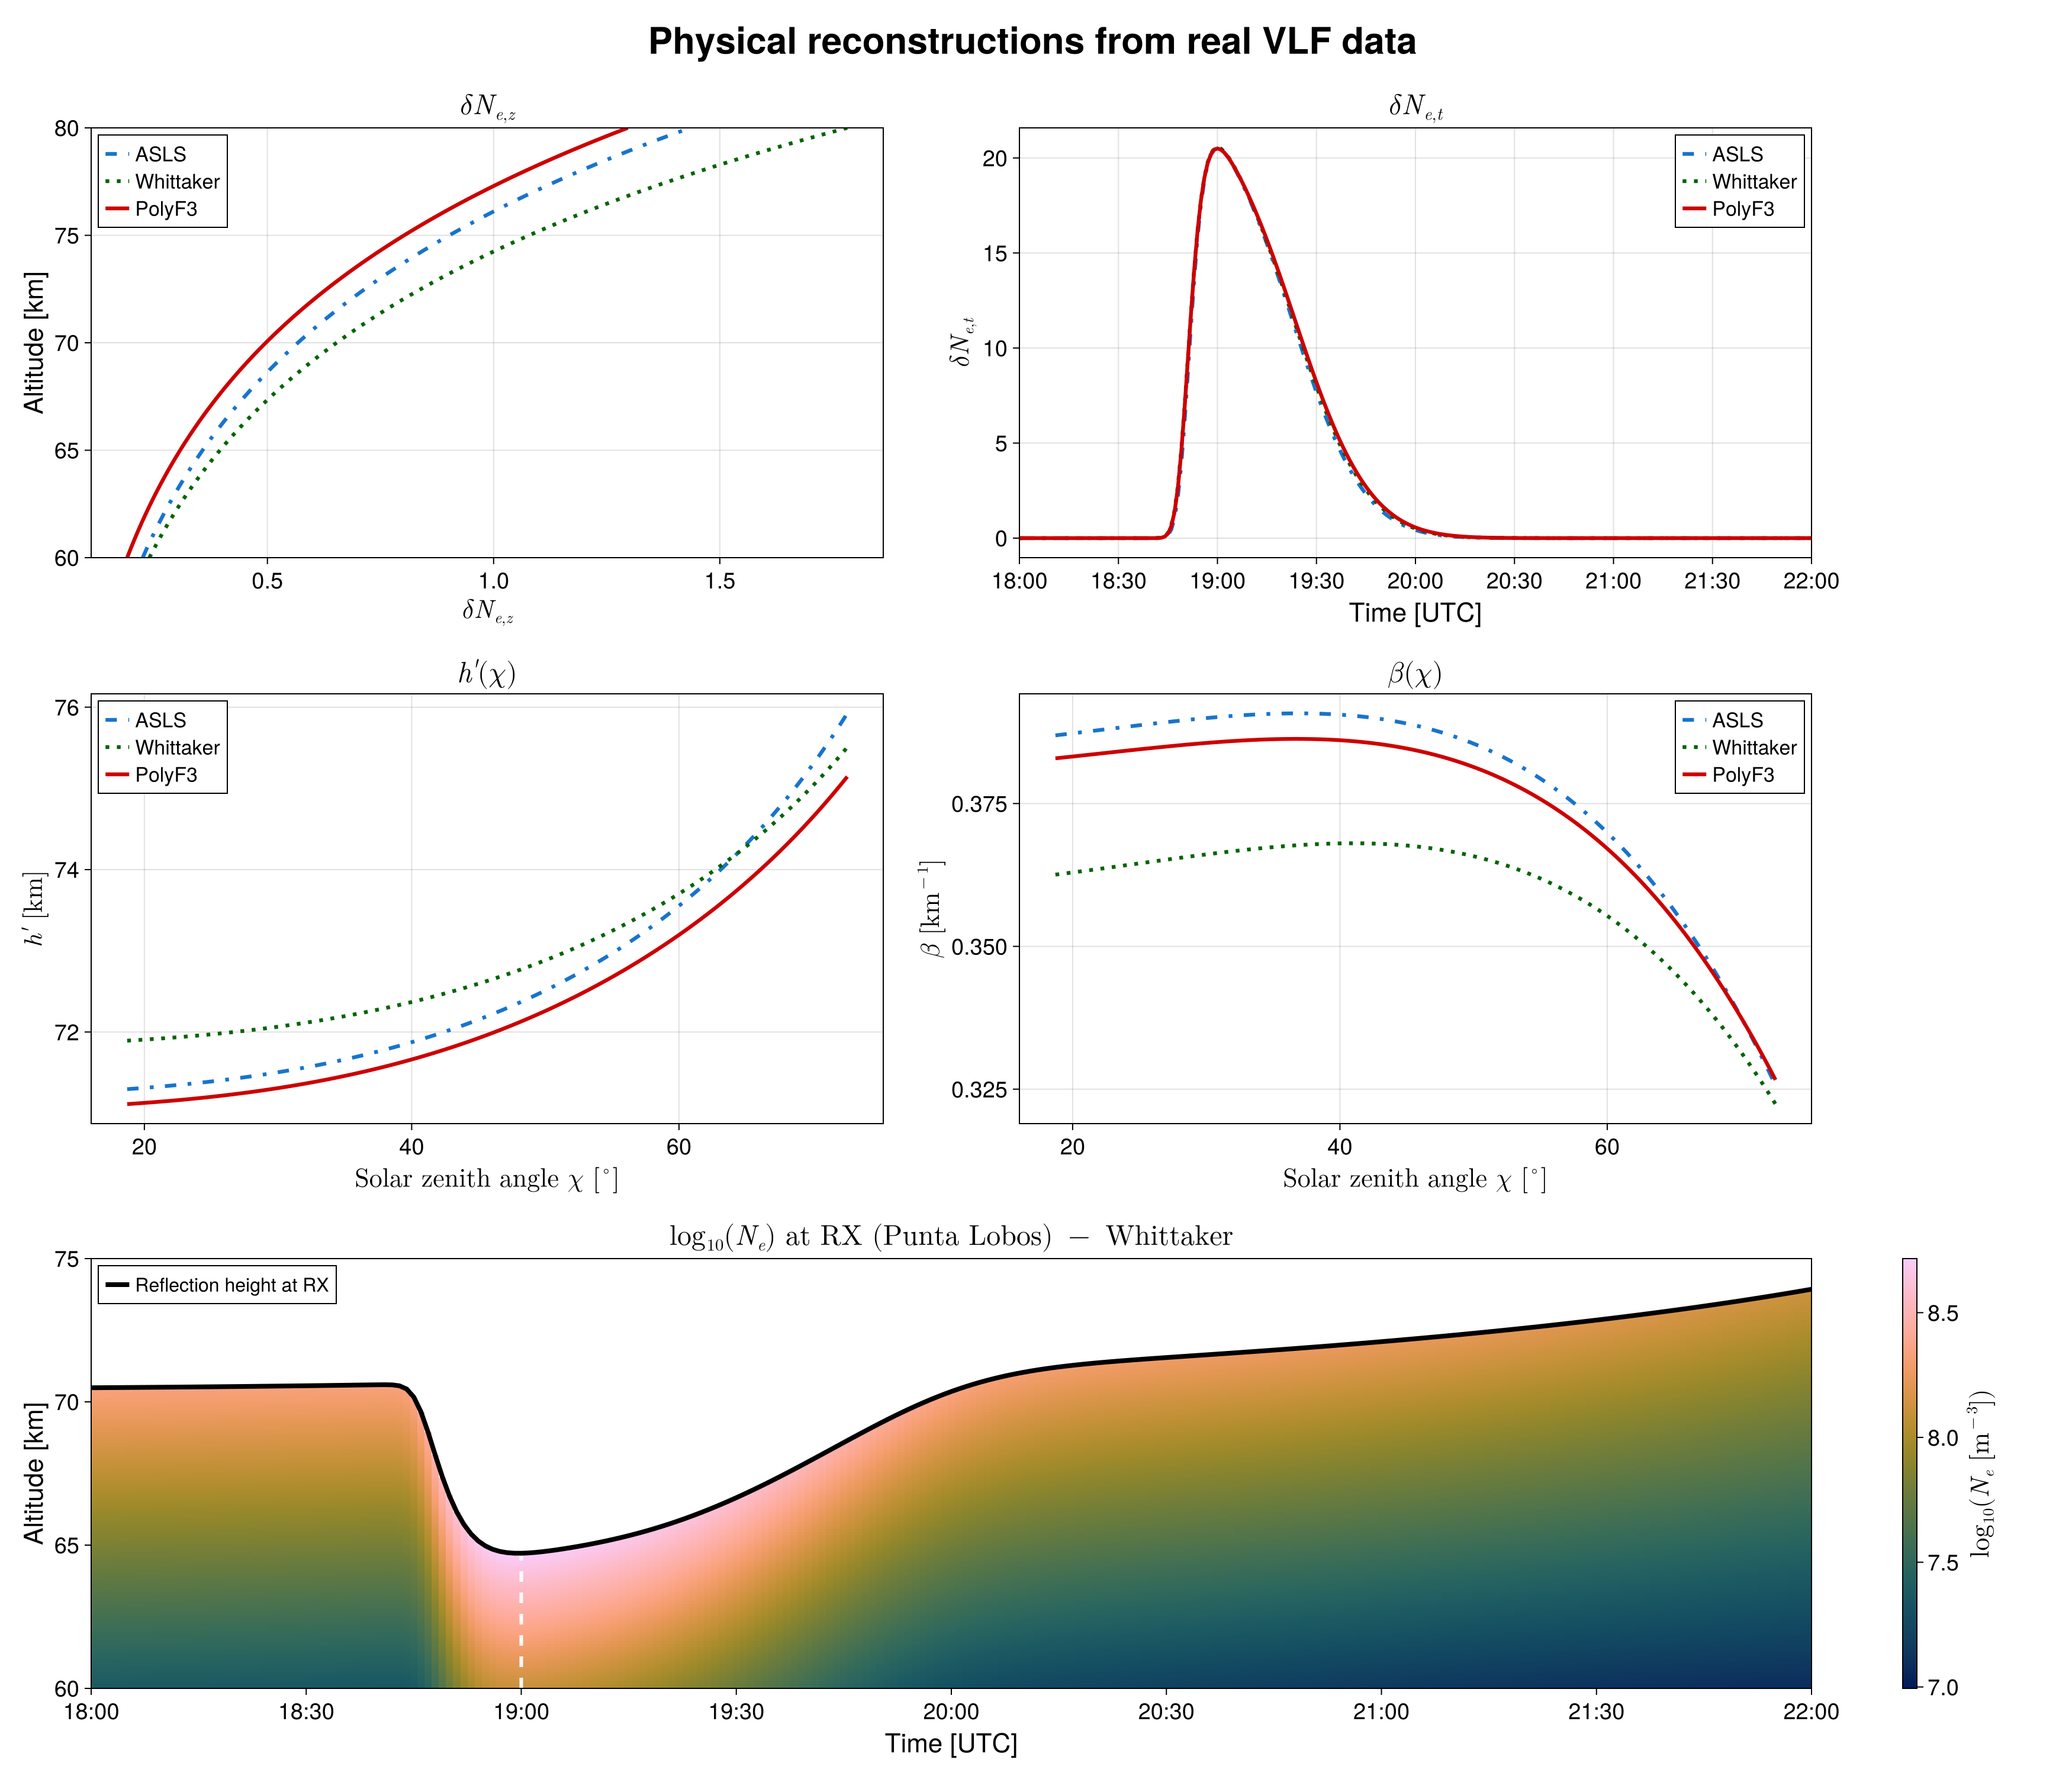

In [26]:

# ============================================================
# 24. Figure 10 — combined physical reconstruction summary
# ============================================================
if RUN_PHYSICAL_FIELDS
    fig10 = CM.Figure(size = (1750, 1500), backgroundcolor = :white)

    CM.Label(
        fig10[0, 1:3],
        "Physical reconstructions from real VLF data";
        fontsize = FS_TITLE + 7,
        font = :bold,
        halign = :center,
        tellwidth = false,
    )

    axZ = CM.Axis(
        fig10[1, 1],
        xlabel = L"\delta N_{e,z}",
        ylabel = "Altitude [km]",
        title = L"\delta N_{e,z}",
        limits = (nothing, (60.0, 80.0)),
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
    )

    axTphys = CM.Axis(
        fig10[1, 2],
        xlabel = "Time [UTC]",
        ylabel = L"\delta N_{e,t}",
        title = L"\delta N_{e,t}",
        xticks = (xticks_hours, xtick_labels),
        limits = (18.0, 22.0, nothing, nothing),
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
    )

    axH = CM.Axis(
        fig10[2, 1],
        xlabel = L"\mathrm{Solar\ zenith\ angle}\ \chi\ [^\circ]",
        ylabel = L"h'\ [\mathrm{km}]",
        title = L"h'(\chi)",
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
    )

    axB = CM.Axis(
        fig10[2, 2],
        xlabel = L"\mathrm{Solar\ zenith\ angle}\ \chi\ [^\circ]",
        ylabel = L"\beta\ [\mathrm{km}^{-1}]",
        title = L"\beta(\chi)",
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
    )

    for method in METHODS
        CM.lines!(
            axZ,
            VERTICAL_PROFILES[method],
            z_profile_km;
            color = METHOD_COLORS[method],
            linestyle = METHOD_LINESTYLES[method],
            linewidth = LW,
            label = method,
        )

        CM.lines!(
            axTphys,
            physical_time_hours,
            TEMPORAL_PROFILES[method];
            color = METHOD_COLORS[method],
            linestyle = METHOD_LINESTYLES[method],
            linewidth = LW,
            label = method,
        )

        CM.lines!(
            axH,
            chi_grid_deg,
            H_CHI[method];
            color = METHOD_COLORS[method],
            linestyle = METHOD_LINESTYLES[method],
            linewidth = LW,
            label = method,
        )

        CM.lines!(
            axB,
            chi_grid_deg,
            BETA_CHI[method];
            color = METHOD_COLORS[method],
            linestyle = METHOD_LINESTYLES[method],
            linewidth = LW,
            label = method,
        )
    end

    CM.axislegend(axZ; position = :lt, labelsize = FS_LEGEND)
    CM.axislegend(axTphys; position = :rt, labelsize = FS_LEGEND)
    CM.axislegend(axH; position = :lt, labelsize = FS_LEGEND)
    CM.axislegend(axB; position = :rt, labelsize = FS_LEGEND)

    axSummaryMap = CM.Axis(
        fig10[3, 1:2],
        xlabel = "Time [UTC]",
        ylabel = "Altitude [km]",
        title = L"\log_{10}(N_e)\ \mathrm{at\ RX\ (Punta\ Lobos)}\ -\ \mathrm{Whittaker}",
        xticks = (xticks_hours, xtick_labels),
        limits = (18.0, 22.0, 60.0, 75.0),
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
        xgridvisible = false,
        ygridvisible = false,
    )

    hm10 = CM.heatmap!(
        axSummaryMap,
        physical_time_hours,
        z_field_km,
        LOGNE_MASKED["Whittaker"];
        colormap = :batlow,
        colorrange = COMMON_LOGNE_COLORRANGE,
        nan_color = :white,
    )

    CM.vlines!(
        axSummaryMap,
        [19.0];
        color = (:white, 0.95),
        linestyle = :dash,
        linewidth = 3,
    )

    CM.lines!(
        axSummaryMap,
        physical_time_hours,
        REFLECTION_HEIGHTS["Whittaker"];
        color = :black,
        linewidth = 4,
        label = "Reflection height at RX",
    )

    CM.axislegend(
        axSummaryMap;
        position = :lt,
        labelsize = FS_LEGEND - 1,
        backgroundcolor = (:white, 0.90),
    )

    CM.Colorbar(
        fig10[3, 3],
        hm10;
        label = L"\log_{10}(N_e\ [\mathrm{m}^{-3}])",
        labelsize = FS_LABEL,
        ticklabelsize = FS_TICK,
    )

    CM.colgap!(fig10.layout, 28)
    CM.rowgap!(fig10.layout, 25)
    CM.colsize!(fig10.layout, 3, CM.Fixed(110))

    save_figure(fig10, "fig10_physical_reconstruction_summary")

    register_provenance!(
        "figures/fig10_physical_reconstruction_summary";
        kind = "figure",
        source_files = [
            FILE_PATHS[:ASLS_BG], FILE_PATHS[:ASLS_BBO2],
            FILE_PATHS[:WHIT_BG], FILE_PATHS[:WHIT_BBO2],
            FILE_PATHS[:POLY_BG], FILE_PATHS[:POLY_BBO2],
        ],
        datasets = [
            "reconstruction/h_coeffs",
            "reconstruction/beta_coeffs",
            "reconstruction/full_params",
        ],
        description = "Combined comparison of vertical and temporal perturbations, physical backgrounds, and a representative Whittaker electron-density field.",
    )

    fig10
end


## 9. Reproducible summary, provenance, and output manifest

In [27]:

# ============================================================
# 25. Automatic scientific summary
# ============================================================
best_total_method = metrics5_df.method[argmin(metrics5_df.chi2_total)]
best_amplitude_method = metrics5_df.method[argmin(metrics5_df.chi2_A)]
best_phase_method = metrics5_df.method[argmin(metrics5_df.chi2_phi)]

largest_parameter_spread_idx = argmax(parameter_sensitivity_df.relative_range_percent)
largest_parameter_spread = parameter_sensitivity_df[largest_parameter_spread_idx, :]

summary_path = joinpath(DIAGNOSTICS_DIR, "summary_results.txt")

open(summary_path, "w") do io
    println(io, "REAL-DATA VLF PERTURBATION INVERSION — AUTOMATIC SUMMARY")
    println(io, "========================================================")
    println(io, "Generated: ", now())
    println(io, "Output root: ", OUTPUT_ROOT)
    println(io)

    println(io, "Canonical chains:")
    println(io, "  ASLS:       15341092 -> 15373069")
    println(io, "  Whittaker:  15517278 -> 15572093")
    println(io, "  PolyF3:     15824988 -> 15868514")
    println(io)

    println(io, "Common 5-minute comparison:")
    println(io, "  Lowest total normalized misfit: ", best_total_method)
    println(io, "  Lowest amplitude misfit:         ", best_amplitude_method)
    println(io, "  Lowest phase misfit:             ", best_phase_method)
    println(io)

    for method in METHODS
        m = METRICS5[method]
        @printf(
            io,
            "  %-10s chi2_A=%.6f  chi2_phi=%.6f  chi2_total=%.6f  RMSE_A=%.6f dB  RMSE_phi=%.6f deg\n",
            method,
            m.chi2_A,
            m.chi2_phi,
            m.chi2_total,
            m.RMSE_A_dB,
            m.RMSE_phi_deg,
        )
    end

    println(io)
    println(
        io,
        "Largest relative inter-family parameter range: ",
        largest_parameter_spread.parameter,
        " = ",
        round(largest_parameter_spread.relative_range_percent, digits = 3),
        "%",
    )
    println(io)
    println(
        io,
        "Interpretation constraint: the ranking quantifies fit to the observed VLF data; " *
        "it does not identify a known true ionospheric solution.",
    )
end

println(read(summary_path, String))


REAL-DATA VLF PERTURBATION INVERSION — AUTOMATIC SUMMARY
Generated: 2026-06-21T21:45:21.072
Output root: /home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256

Canonical chains:
  ASLS:       15341092 -> 15373069
  Whittaker:  15517278 -> 15572093
  PolyF3:     15824988 -> 15868514

Common 5-minute comparison:
  Lowest total normalized misfit: PolyF3
  Lowest amplitude misfit:         ASLS
  Lowest phase misfit:             PolyF3

  ASLS       chi2_A=0.069219  chi2_phi=0.236312  chi2_total=0.305530  RMSE_A=0.622537 dB  RMSE_phi=17.296996 deg
  Whittaker  chi2_A=0.167012  chi2_phi=0.114903  chi2_total=0.281915  RMSE_A=0.967001 dB  RMSE_phi=12.061290 deg
  PolyF3     chi2_A=0.097251  chi2_phi=0.088992  chi2_total=0.186243  RMSE_A=0.737906 dB  RMSE_phi=10.614591 deg

Largest relative inter-family parameter range: hz_km = 7.897%

Interpretation constraint: the ranking quantifies fit to the observed VLF data; it does not identify a known true ionos

In [28]:

# ============================================================
# 26. Provenance table and final output manifest
# ============================================================
provenance_df = DataFrame(PROVENANCE_ROWS)
CSV.write(joinpath(PROVENANCE_DIR, "results_provenance.csv"), provenance_df)

# Include every generated file except the manifest itself.
manifest_rows = NamedTuple[]

for (dir, _subdirs, files) in walkdir(OUTPUT_ROOT)
    for file in sort(files)
        path = joinpath(dir, file)
        basename(path) == "output_manifest.csv" && continue

        push!(
            manifest_rows,
            (
                relative_path = relpath(path, OUTPUT_ROOT),
                size_bytes = filesize(path),
                sha256 = sha256_file(path),
            ),
        )
    end
end

output_manifest = DataFrame(manifest_rows)
sort!(output_manifest, :relative_path)
CSV.write(joinpath(PROVENANCE_DIR, "output_manifest.csv"), output_manifest)

println("All generated material is contained in:")
println(OUTPUT_ROOT)
println()
display(output_manifest)


All generated material is contained in:
/home/jp/basefolder_JP/resultados_inversion_perturbacion_datos_reales_3familias_20260621_214256



Row,relative_path,size_bytes,sha256
,String,Int64,String
1,diagnostics/h5_dataset_inventory.csv,23506,2ecf9d35f87768dc0526abdb8302995066064a3d81cac6c17dee881ef4089a76
2,diagnostics/h5_dataset_inventory.txt,54172,e18084fb009810dff697abd17a49f8a53f0231eeebe136c5394737e9f9174c20
3,diagnostics/heatmaps_3families_same_scale.pdf,1317654,ef2df28f705f2bd0d69d69d85fb3802655fa2adb0599c85775f79b20be9ff0bf
4,diagnostics/heatmaps_3families_same_scale.png,380356,f88c0093d3072f92930477a16fa6e0e2ccab32b04e7024bbe4b8e66dc11006b5
5,diagnostics/parameter_positions_within_bounds.csv,4072,80ec4408c4ef4ae4945d65ce024e47144b3ad9ad7eaef547d5c5a69924bd9857
6,diagnostics/parameter_positions_within_bounds.pdf,11413,6a56cb9588e8ab3aa372c59eb053fc42a5157dfed01fdcf5174a684460cc3a4e
7,diagnostics/parameter_positions_within_bounds.png,153279,044ae02ccd3a7d451cf97a6f102de825463dfbed026c1af58198481d94d79b1f
8,diagnostics/summary_results.txt,1076,3455323c4f96af842d59958fc2ab4841fe14ec5b8617488f4ccc2236599bc25a
9,diagnostics/target_17point_pairwise_differences.csv,346,a7b02536f71b456420d573eeb093c5587e395234e3bedde1e0d642e261b504dc



## Interpretation guardrails

The generated figures and tables support the following statements:

- the three concatenated chains improve their normalized endpoint misfit relative to the common initial seed;
- PolyF3 gives the lowest combined common-grid misfit under equal amplitude and phase weights;
- ASLS gives the lowest common-grid amplitude misfit;
- the temporal perturbation parameters are comparatively stable across background families;
- the vertical structure is more sensitive to the adopted background separation;
- the Whittaker heatmap is a representative physical realization, not a known truth or a universal optimum.

Every output produced by this notebook is written inside the exclusive timestamped directory printed in Section 0.
